# ET-DHP and PID: nonlinear Boeing 747
### Reference tracking and total error · 500 seconds

At **137 seconds**, the left outboard engine loses **50% of its own thrust**. With an unchanged thrust command, this reduces total thrust by 12.5%. Both controllers receive measurements only; neither knows the failure time.

| Independent reference | Value |
|:---|---:|
| Heading ψ | 0° |
| Roll φ | 0° |
| Speed V | 674 ft/s = 205.4352 m/s |
| Altitude h | 20,000 ft = 6096 m |

🔵 **ET-DHP** uses nominal LQR initialization and event-triggered actor/critic learning. Its plant model stays fixed from the beginning of the flight.  
🟠 **PID** uses fixed gains fitted on the healthy aircraft.  
Both have identical control surface limits and share the speed/altitude controller.

**All figures have English labels and are embedded in this notebook.** They use the original trajectories without smoothing. The plots show individual channel errors, their normalized sum, and accumulated error over the flight.

Pitch is not a separate constant reference: its command is generated by the altitude/speed controller. The recorded pitch offset from trim cannot be treated as tracking error relative to that changing command. The total metric includes the four independent references listed above.

[Step evaluation with the TensorAeroSpace ControlBenchmark](#project-step-benchmark) includes the tuned and original ET-DHP configurations and PID.

In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import HTML, Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

%matplotlib inline
set_matplotlib_formats('retina')

repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'tensoraerospace').is_dir())
sys.path.insert(0, str(repo))
data_dir = repo / 'outputs' / 'b747-etdhp-vs-pid'
figure_dir = data_dir / 'notebook' / 'english_graphics'
figure_dir.mkdir(parents=True, exist_ok=True)

# True: rerun all six episodes; False: load a matching cache.
RERUN_SIMULATION = False
from example.reinforcement_learning.incremental_adp import example_etdhp_vs_pid_b747 as demo
cfg = demo.Experiment(duration=500, fault_time=137, engine_fraction=0.5)
required = ['healthy_etdhp', 'healthy_pid', 'healthy_etdhp_online_model',
            'fault_etdhp', 'fault_pid', 'fault_etdhp_online_model']
report_path = data_dir / 'metrics.json'
cache_matches = False
if report_path.exists() and all((data_dir / f'{key}.csv').exists() for key in required):
    cached_report = json.loads(report_path.read_text())
    cache_matches = cached_report['experiment'] == asdict(cfg)
if RERUN_SIMULATION or not cache_matches:
    import torch
    torch.set_num_threads(1)
    traces, report = demo.run_comparison(cfg, include_online_model=True)
    data_dir.mkdir(parents=True, exist_ok=True)
    report_path.write_text(json.dumps(report, indent=2, allow_nan=False) + '\n')
    for key, trace in traces.items():
        np.savetxt(data_dir / f'{key}.csv', trace, delimiter=',',
                   header=','.join(report['trace_columns']), comments='')
else:
    report = cached_report
    traces = {key: np.loadtxt(data_dir / f'{key}.csv', delimiter=',', skiprows=1)
              for key in required}
assert all(run['status'] == 'complete' for run in report['runs'].values())

column = {name: i for i, name in enumerate(report['trace_columns'])}
fault_time = float(report['experiment']['fault_time'])
duration = float(report['experiment']['duration'])
for name, trace in traces.items():
    assert np.isfinite(trace).all() and np.isclose(trace[-1, 0], duration)
    after = trace[:, 0] > fault_time
    observed_rmse = np.sqrt(np.mean(trace[after, column['psi_deg']] ** 2))
    assert np.isclose(observed_rmse, report['runs'][name]['metrics']['after_fault']['heading_deg']['rmse'])

BLUE, ORANGE, RED, INK = '#2563EB', '#D97706', '#DC2626', '#172033'
MUTED, GRID = '#64748B', '#E2E8F0'
STYLES = {'etdhp': dict(color=BLUE, lw=2.0, label='ET-DHP'),
          'pid': dict(color=ORANGE, lw=1.9, ls='--', label='PID')}
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'figure.facecolor': 'white', 'axes.facecolor': '#FBFCFE',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.titlesize': 14, 'axes.titleweight': 'semibold',
    'axes.labelsize': 12, 'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.alpha': .8,
    'grid.linewidth': .7, 'legend.frameon': False,
    'figure.dpi': 110, 'savefig.dpi': 180,
    'svg.fonttype': 'none', 'pdf.fonttype': 42,
})
exports = []

def decorate(ax, ylabel, *, window=(0, duration), event=True, zero=True):
    ax.set(xlim=window, xlabel='Time, s', ylabel=ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(6, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.set_axisbelow(True)
    if zero:
        ax.axhline(0, color=MUTED, lw=.9, ls=':', alpha=.65, zorder=1)
    if event and window[0] <= fault_time <= window[1]:
        ax.axvspan(fault_time, window[1], color=BLUE, alpha=.025, zorder=0)
        ax.axvline(fault_time, color=MUTED, lw=1.2, ls=(0, (3, 3)), zorder=1)
    ax.legend(loc='best')

def pair(ax, field, *, window=(0, duration), scale=1.0, condition='fault'):
    for algo in ('etdhp', 'pid'):
        x = traces[f'{condition}_{algo}']
        mask = (x[:, 0] >= window[0]) & (x[:, 0] <= window[1])
        ax.plot(x[mask, 0], scale * x[mask, column[field]], **STYLES[algo])

def heading(fig, title, subtitle):
    fig.suptitle(title + '\n' + subtitle, fontsize=16, fontweight='semibold', color=INK)

def show_export(fig, slug):
    for suffix in ('png', 'svg'):
        fig.savefig(figure_dir / f'{slug}.{suffix}', facecolor='white', bbox_inches='tight')
    exports.append((slug, fig))
    display(fig)
    plt.close(fig)

m = report['runs']['fault_etdhp']['metrics']
p = report['runs']['fault_pid']['metrics']
gain = 100 * (1 - m['after_fault']['heading_deg']['rmse'] / p['after_fault']['heading_deg']['rmse'])
late_gain = 100 * (1 - m['last_100_s']['heading_deg']['rmse'] / p['last_100_s']['heading_deg']['rmse'])

# Tuned ET-DHP: final comparison

Parameters were selected on the **healthy aircraft**. The search screened 1600 initial cost configurations on a local model, followed by actual neural networks and the nonlinear B747 model. The final objective considers errors in **all four references**, oscillation, settling, overshoot, and command variation.

**Blue: final ET-DHP**, orange: the original PID, gray: ET-DHP before tuning. The black dashed line shows the reference. Plant physics, ±8° limits, and PID gains are unchanged. The actor and critic learn at events throughout the flight; there is no reset or switching at failure.

Speed and altitude share a longitudinal PI/PD controller. The direct ET-DHP benefit is assessed through heading/roll; total error also includes coupled channels. A detailed comparison with the [original paper](https://eurognc.ceas.org/archive/EuroGNC2022/pdf/CEAS-GNC-2022-075.pdf) is available in the [report](../../../reports/etdhp-b747-paper-comparison.md).

Tests with larger initial deviations exposed sensitivity to cost scaling. Reducing the common Q/R multiplier from 0.001 to 0.0001 preserves the initial LQR policy while allowing learning to pass the tested stress case. Learning rates remain positive. The faster candidate with worse total error and the unstable candidates are retained in the [tuning history](../../../reports/etdhp-b747-tuning-validation.md).

In [2]:
from example.reinforcement_learning.incremental_adp import example_etdhp_tuned_b747 as tuned_demo
import pandas as pd
from scipy.integrate import cumulative_trapezoid

tuned_root = data_dir/'tuning'/'final'
RERUN_TUNED = False
for tuned_stage, expected_count in [('standard',16),('held_out',18)]:
    tuned_file = tuned_root/tuned_stage/'summary.json'
    tuned_cached = json.loads(tuned_file.read_text()) if tuned_file.exists() else {}
    tuned_valid = (len(tuned_cached)==expected_count and all(
        result.get('request',{}).get('source_digest') == tuned_demo.runtime_digest()
        and result.get('request',{}).get('tuning') == json.loads(json.dumps(asdict(tuned_demo.TUNED)))
        and (tuned_file.parent/f'{key}.csv').exists() for key,result in tuned_cached.items()))
    if RERUN_TUNED or not tuned_valid:
        tuned_demo.run_validation(tuned_file.parent,stage=tuned_stage,rerun=RERUN_TUNED)
tuned_standard = json.loads((tuned_root/'standard'/'summary.json').read_text())
tuned_checks = json.loads((tuned_root/'held_out'/'summary.json').read_text())
assert all(r['status']=='complete' for r in [*tuned_standard.values(),*tuned_checks.values()])
print('Final validation: 16 standard experiments and 18 additional runs.')
print('Final ET-DHP parameters:', asdict(tuned_demo.TUNED))

Final validation: 16 standard experiments and 18 additional runs.
Final ET-DHP parameters: {'q': (0.9073718885475248, 0.8234691961911224, 0.03975736005160585, 153.57761735858224, 36.007889593288255, 16.44426339214549, 16.594033001885215), 'r': (0.1605830391504966, 0.026911643586993605), 'actor_lr': 1e-07, 'critic_lr': 1e-06, 'rho': 0.005, 'trigger_floor': 0.0001, 'epochs': 1, 'embedding_scale': 0.02, 'cost_scale': 0.0001}


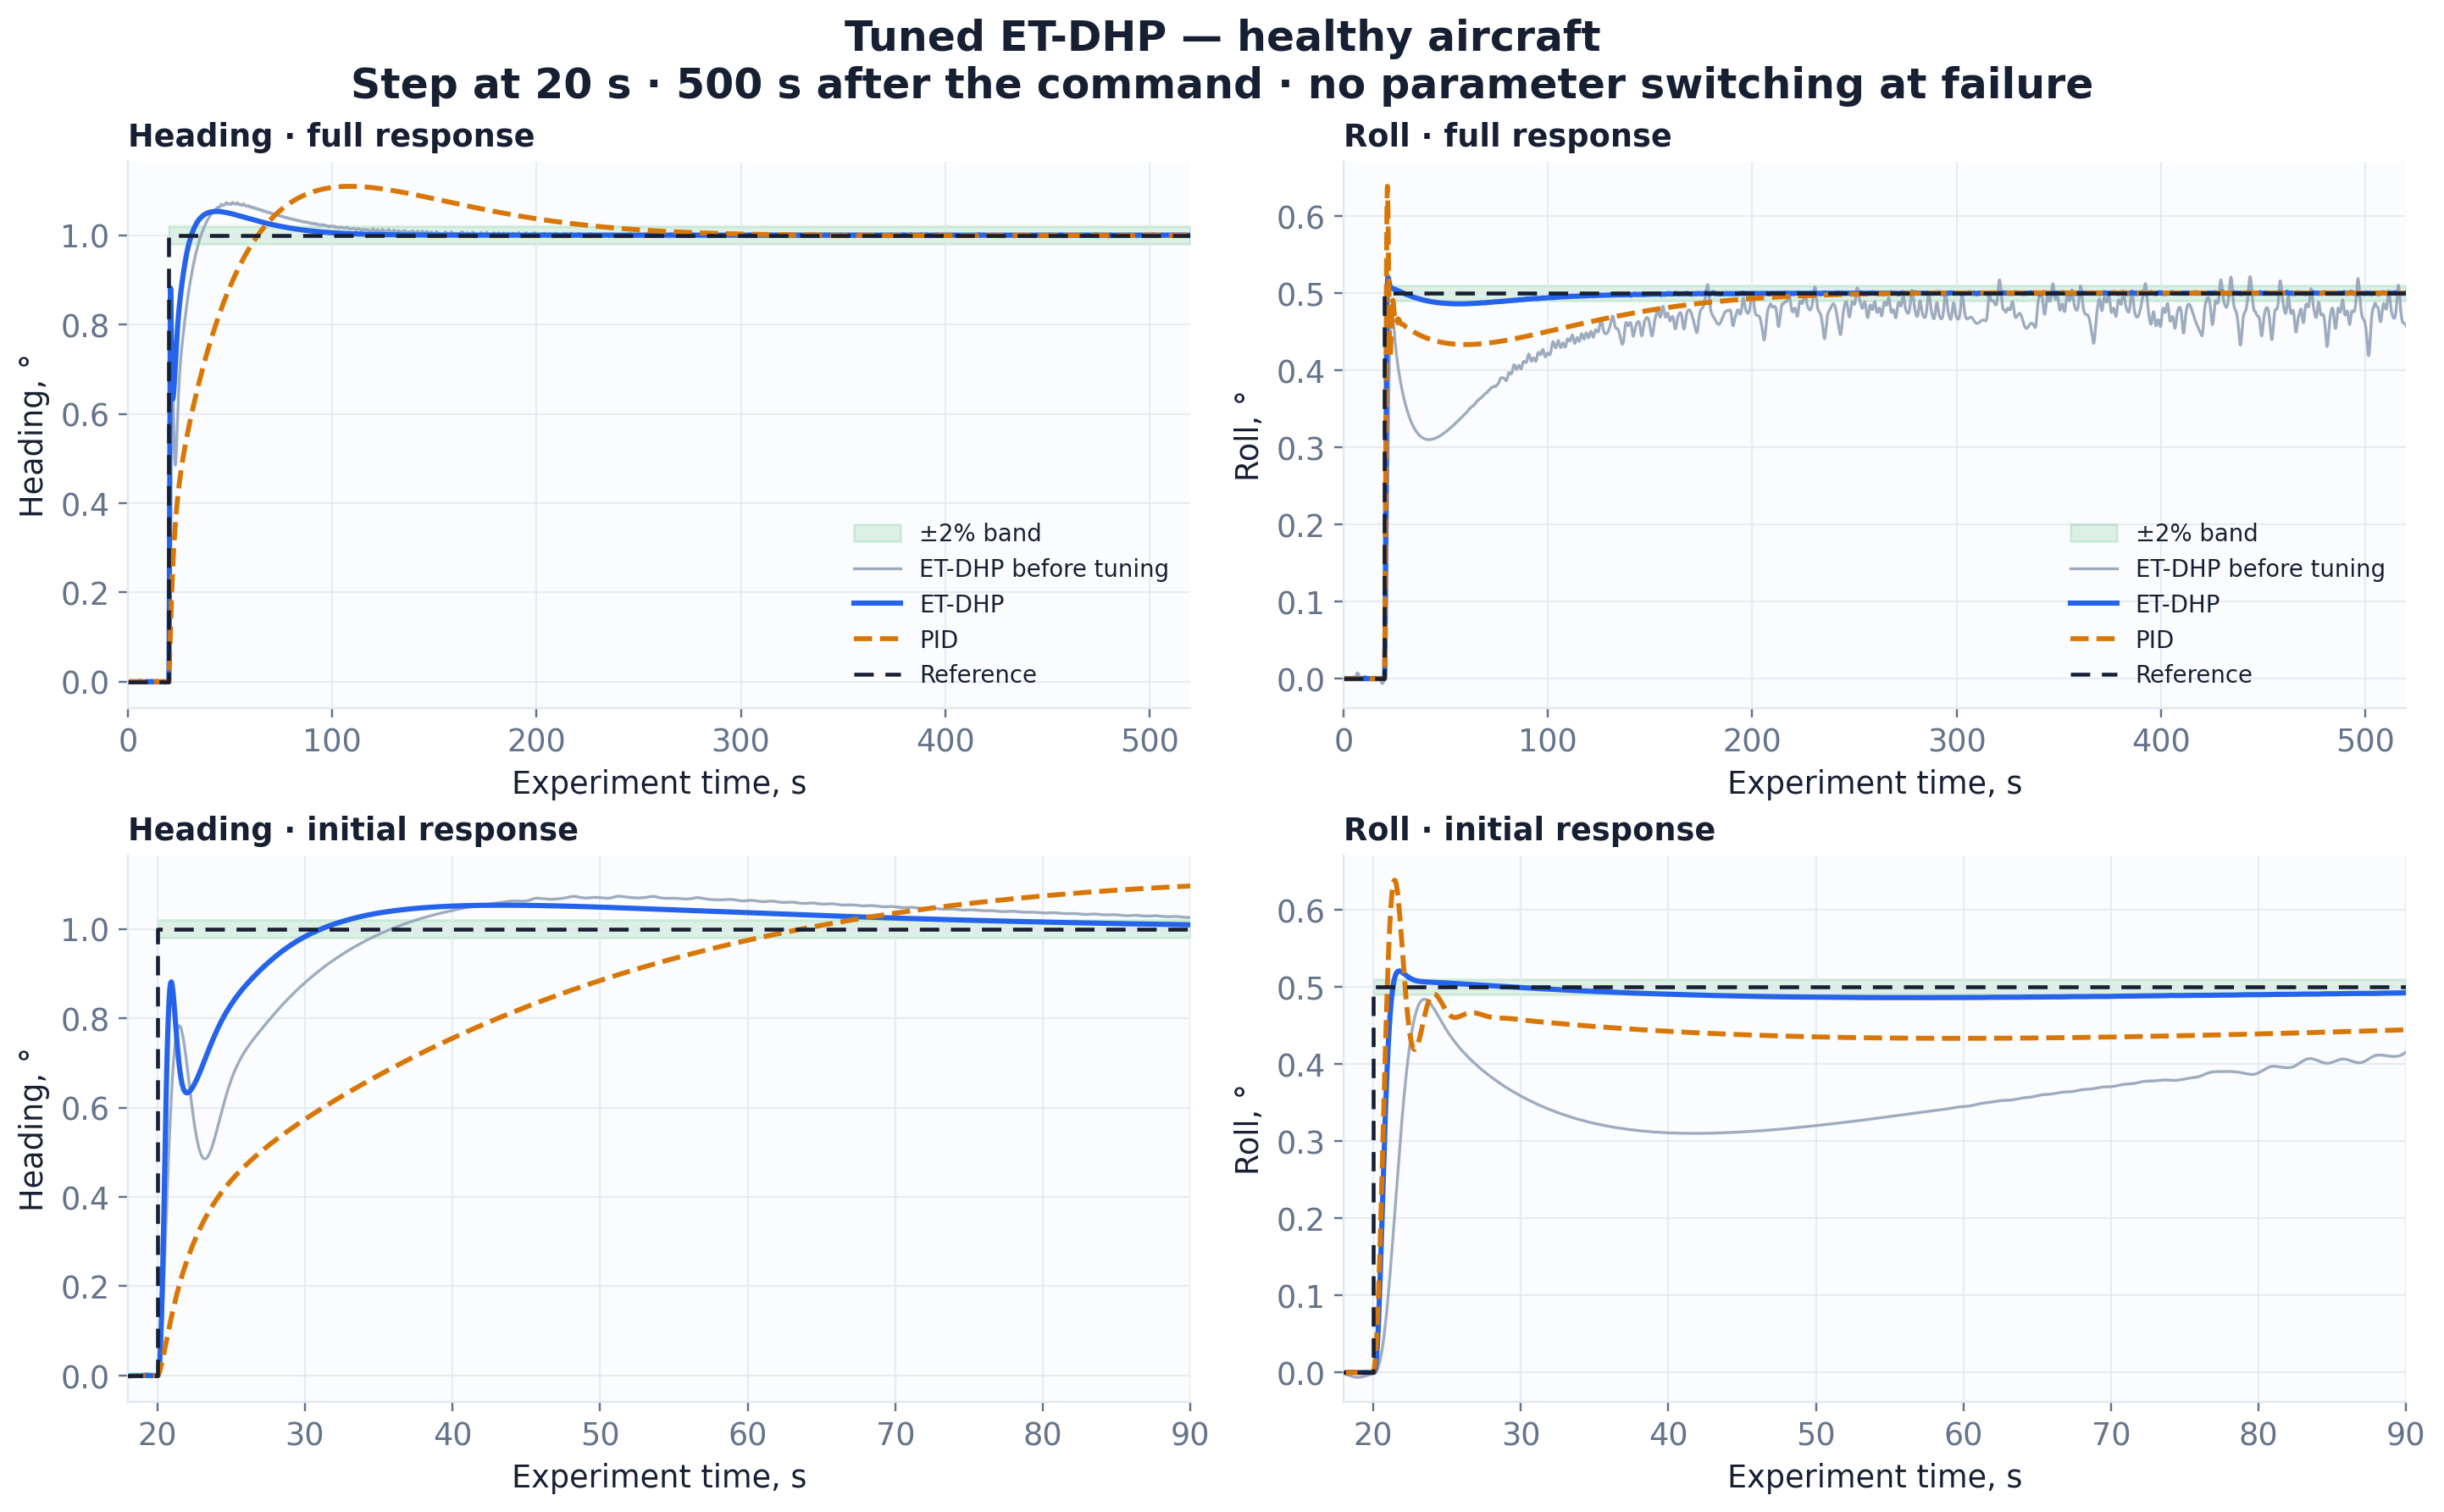

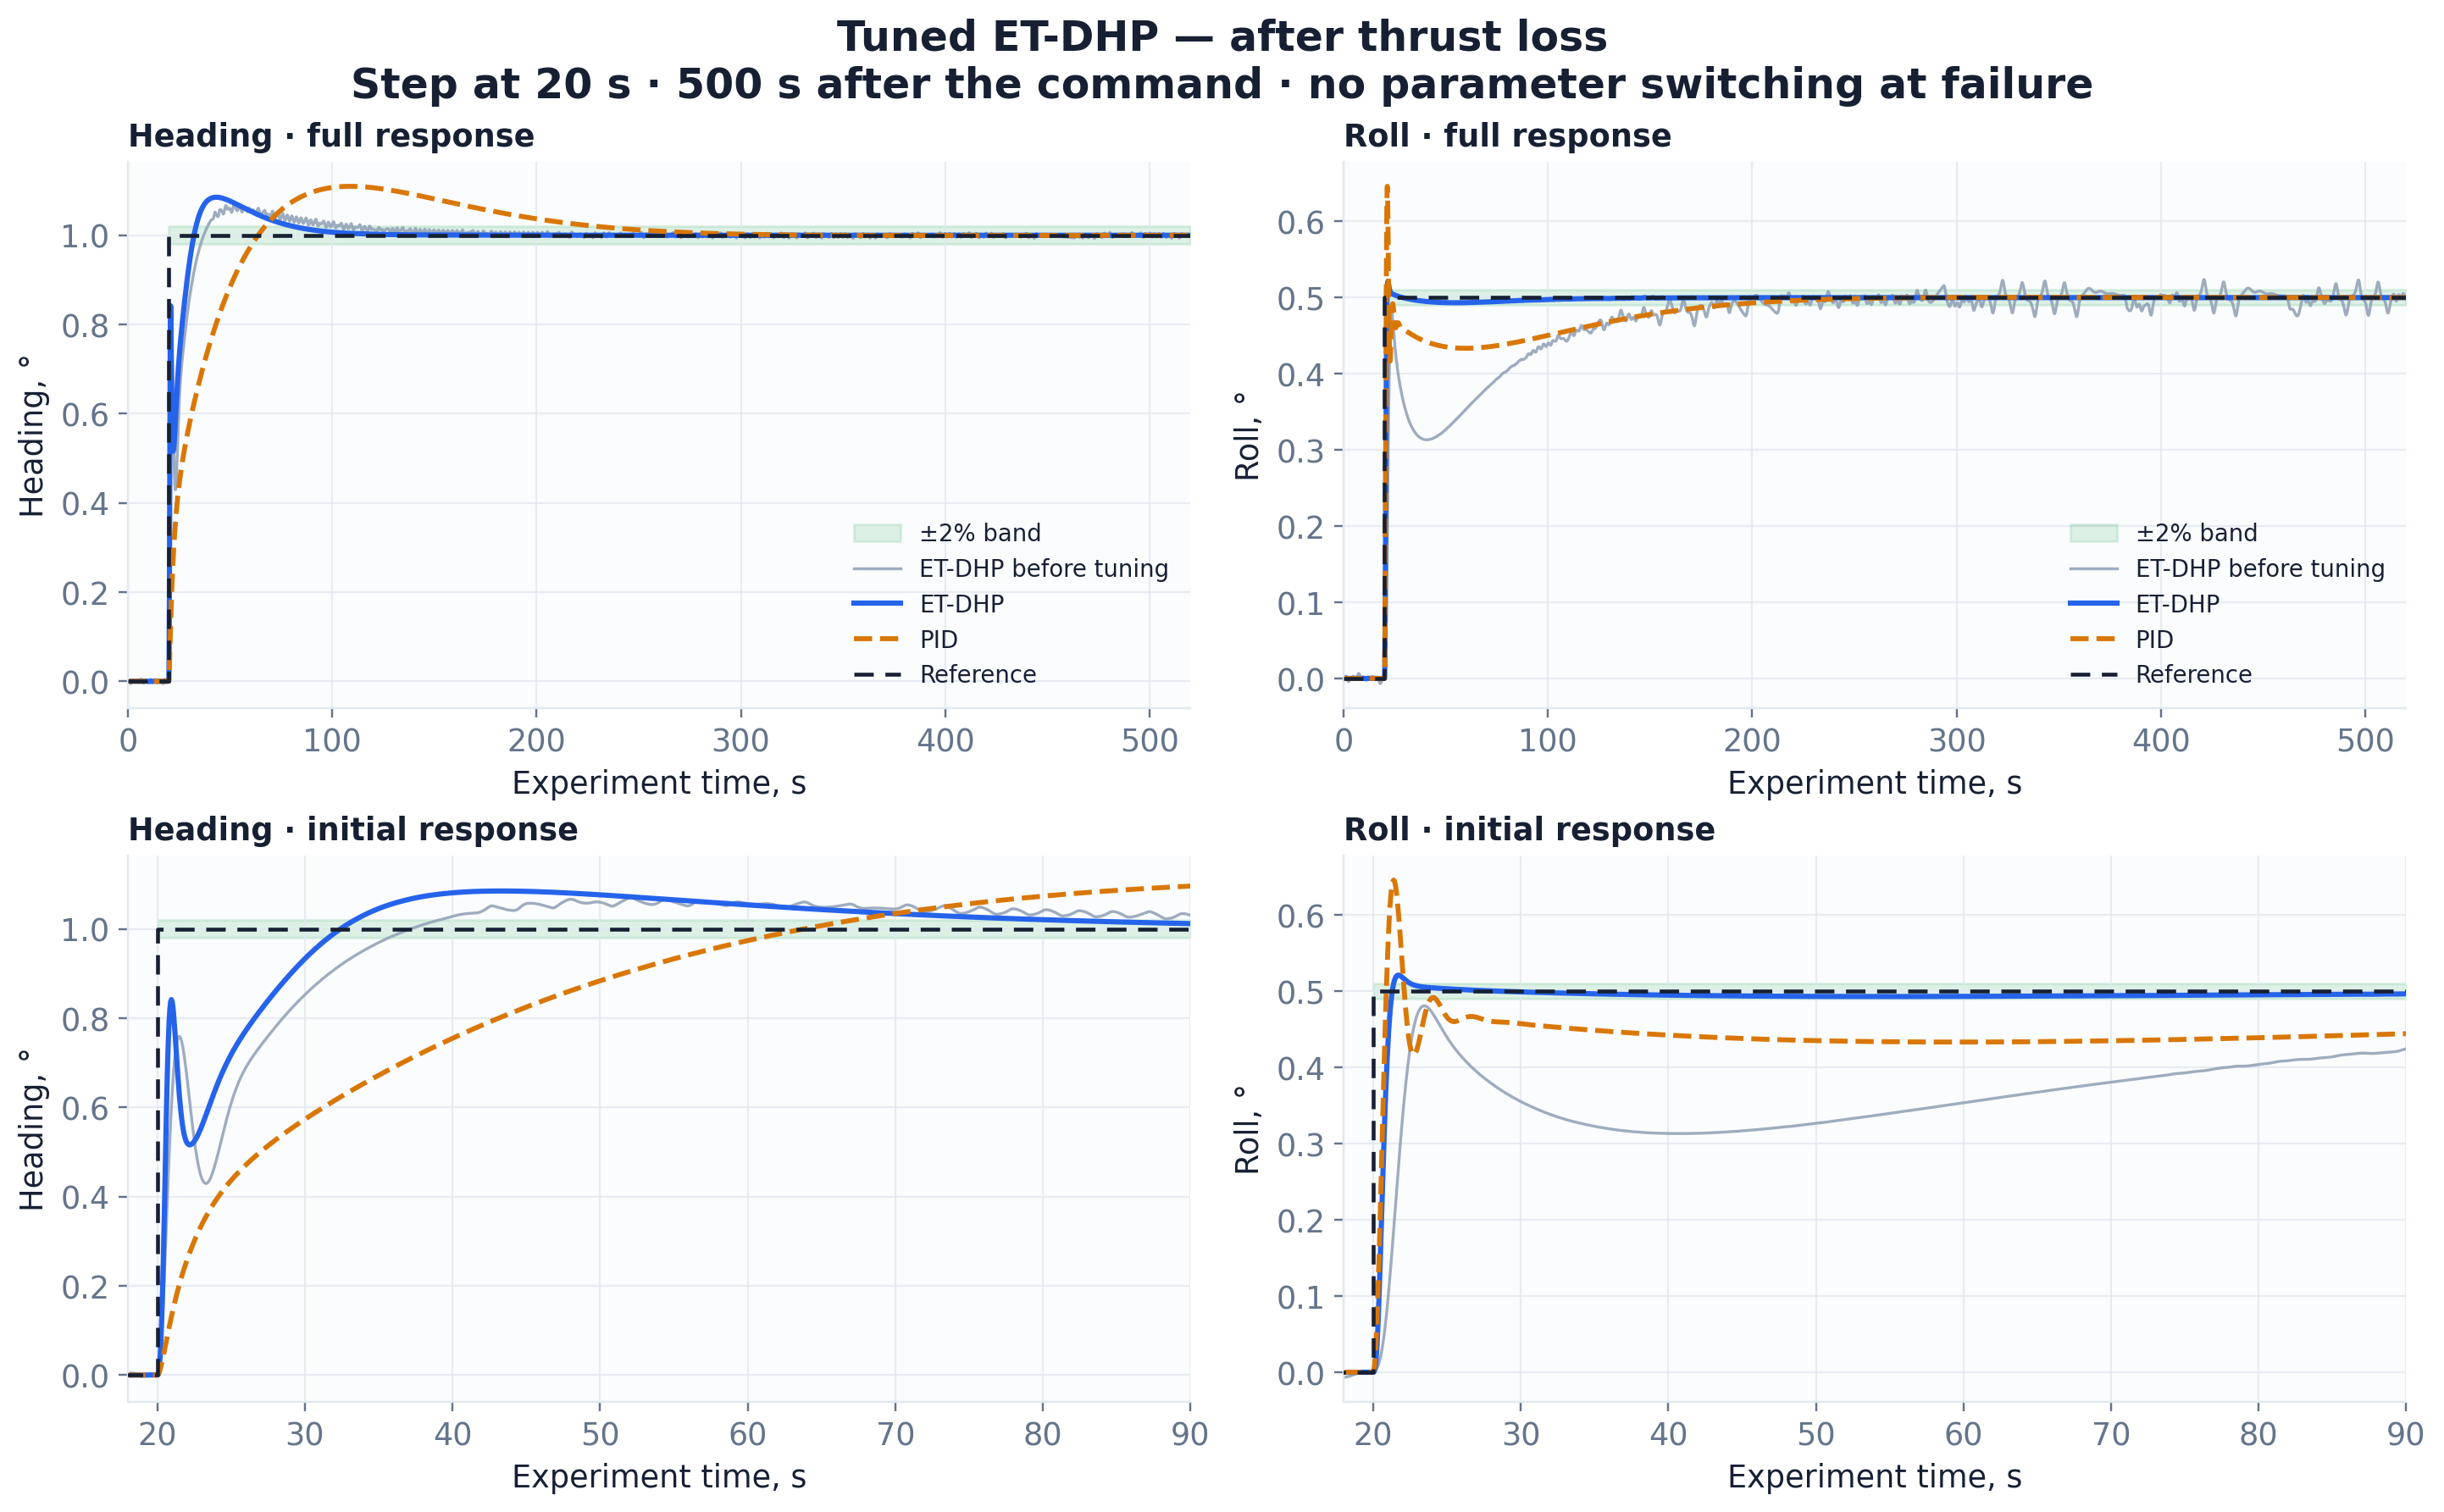

### Settling time and tracking accuracy

Aircraft,Channel,Controller,"Rise time 10–90%, s","Settling ±2%, s","Settling ±5%, s","Overshoot, %",Residual error,Tail standard deviation,IAE,RMSE
Healthy,"Heading, °",ET-DHP,6.48,54.50,28.90,5.32,0.00000,0.00002,4.100,0.0412
Healthy,"Heading, °",PID,30.72,209.15,163.05,10.94,-0.00016,0.00004,23.916,0.1130
Healthy,"Roll, °",ET-DHP,0.78,60.55,1.25,4.13,-0.00002,0.00023,1.352,0.0169
Healthy,"Roll, °",PID,0.63,166.30,123.65,27.71,0.00003,0.00001,7.559,0.0305
Healthy,"Speed, m/s",ET-DHP,14.96,187.70,140.55,45.66,0.00006,0.00012,31.372,0.1579
Healthy,"Speed, m/s",PID,14.96,187.70,140.55,45.66,0.00006,0.00012,31.372,0.1579
Healthy,"Altitude, m",ET-DHP,51.72,not confirmed,not confirmed,46.93,0.72408,0.02721,1116.614,3.1053
Healthy,"Altitude, m",PID,51.72,not confirmed,not confirmed,46.93,0.72408,0.02721,1116.618,3.1053
After failure,"Heading, °",ET-DHP,8.77,60.90,41.90,8.53,0.00000,0.00004,6.022,0.0526
After failure,"Heading, °",PID,30.77,209.25,163.15,10.97,-0.00017,0.00004,23.946,0.1131


Residual error is the mean of output minus reference over the last 50 s. Without confirmed settling, it is not a verified steady-state error.

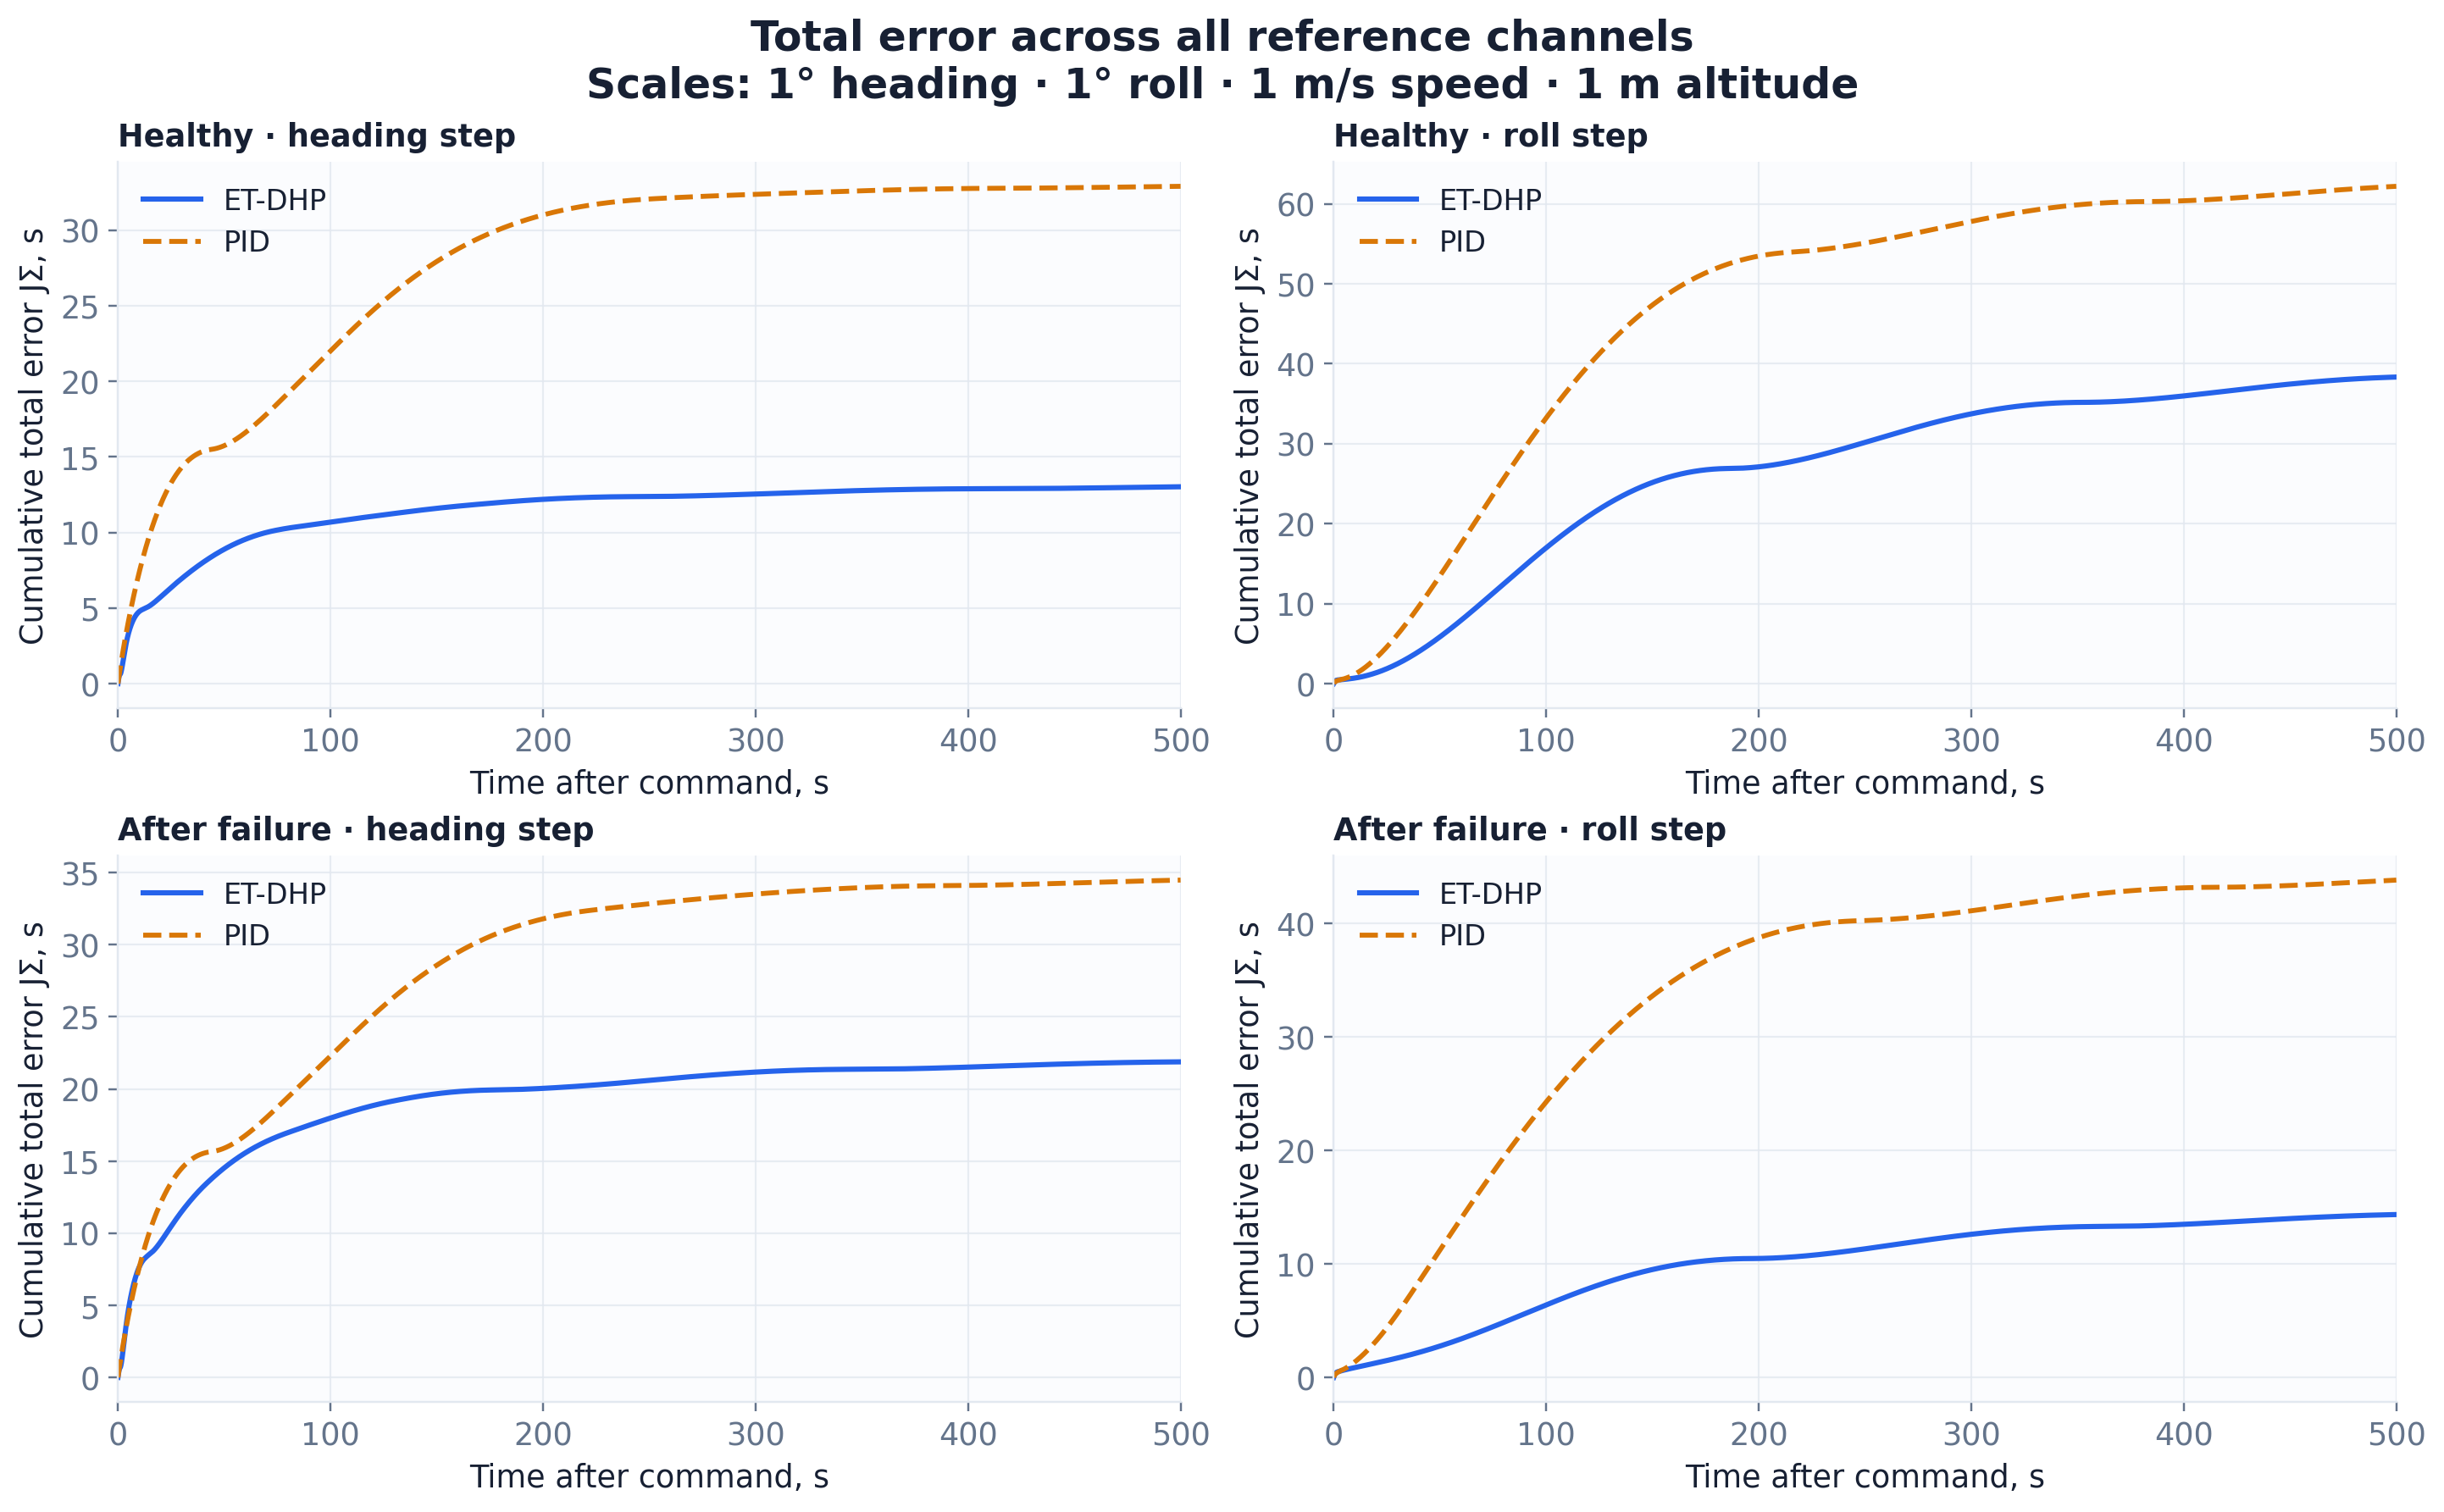

Aircraft,Step,Controller,IAE Heading,IAE Roll,IAE Speed,IAE Altitude,"JΣ, s"
Healthy,Heading,ET-DHP,4.100,5.118,0.700,3.103,13.021
Healthy,Heading,PID,23.916,6.057,0.262,2.663,32.898
Healthy,Roll,ET-DHP,1.311,1.352,0.180,35.491,38.333
Healthy,Roll,PID,24.147,7.559,0.174,30.306,62.185
After failure,Heading,ET-DHP,6.022,9.818,0.943,5.097,21.881
After failure,Heading,PID,23.946,6.055,0.500,3.985,34.486
After failure,Roll,ET-DHP,1.149,0.806,0.076,12.316,14.347
After failure,Roll,PID,24.125,7.526,0.087,12.087,43.825


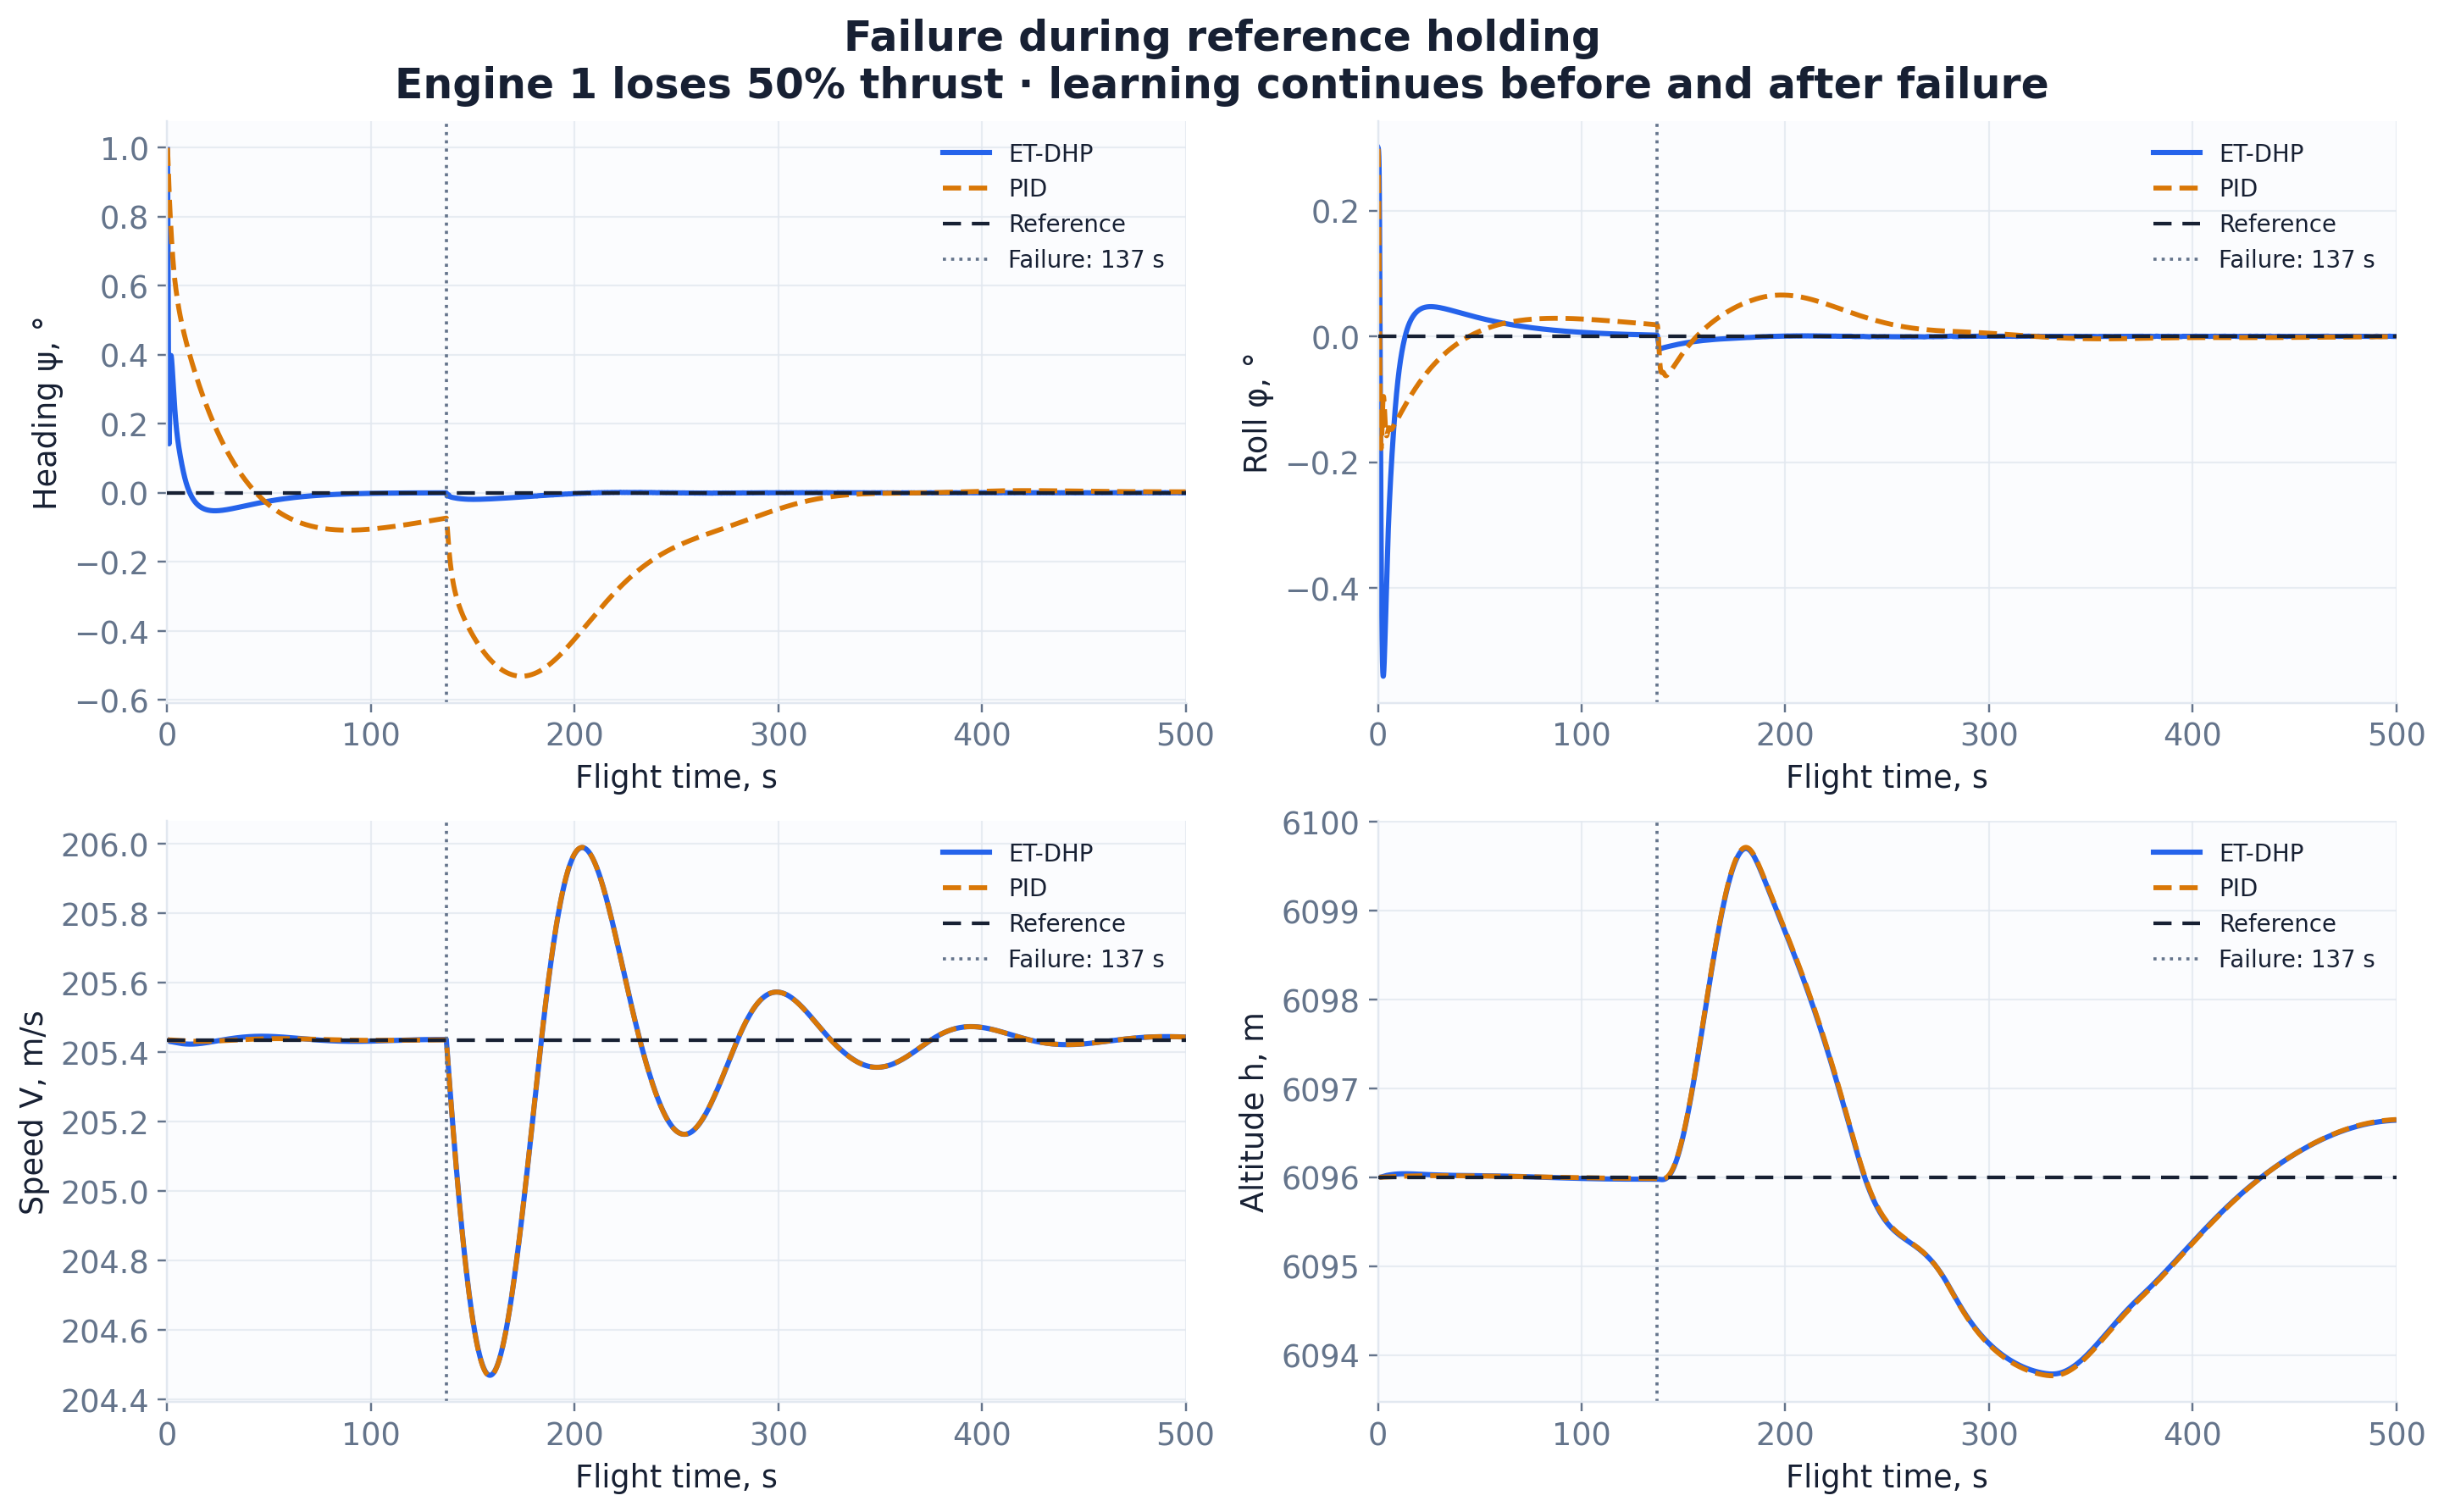

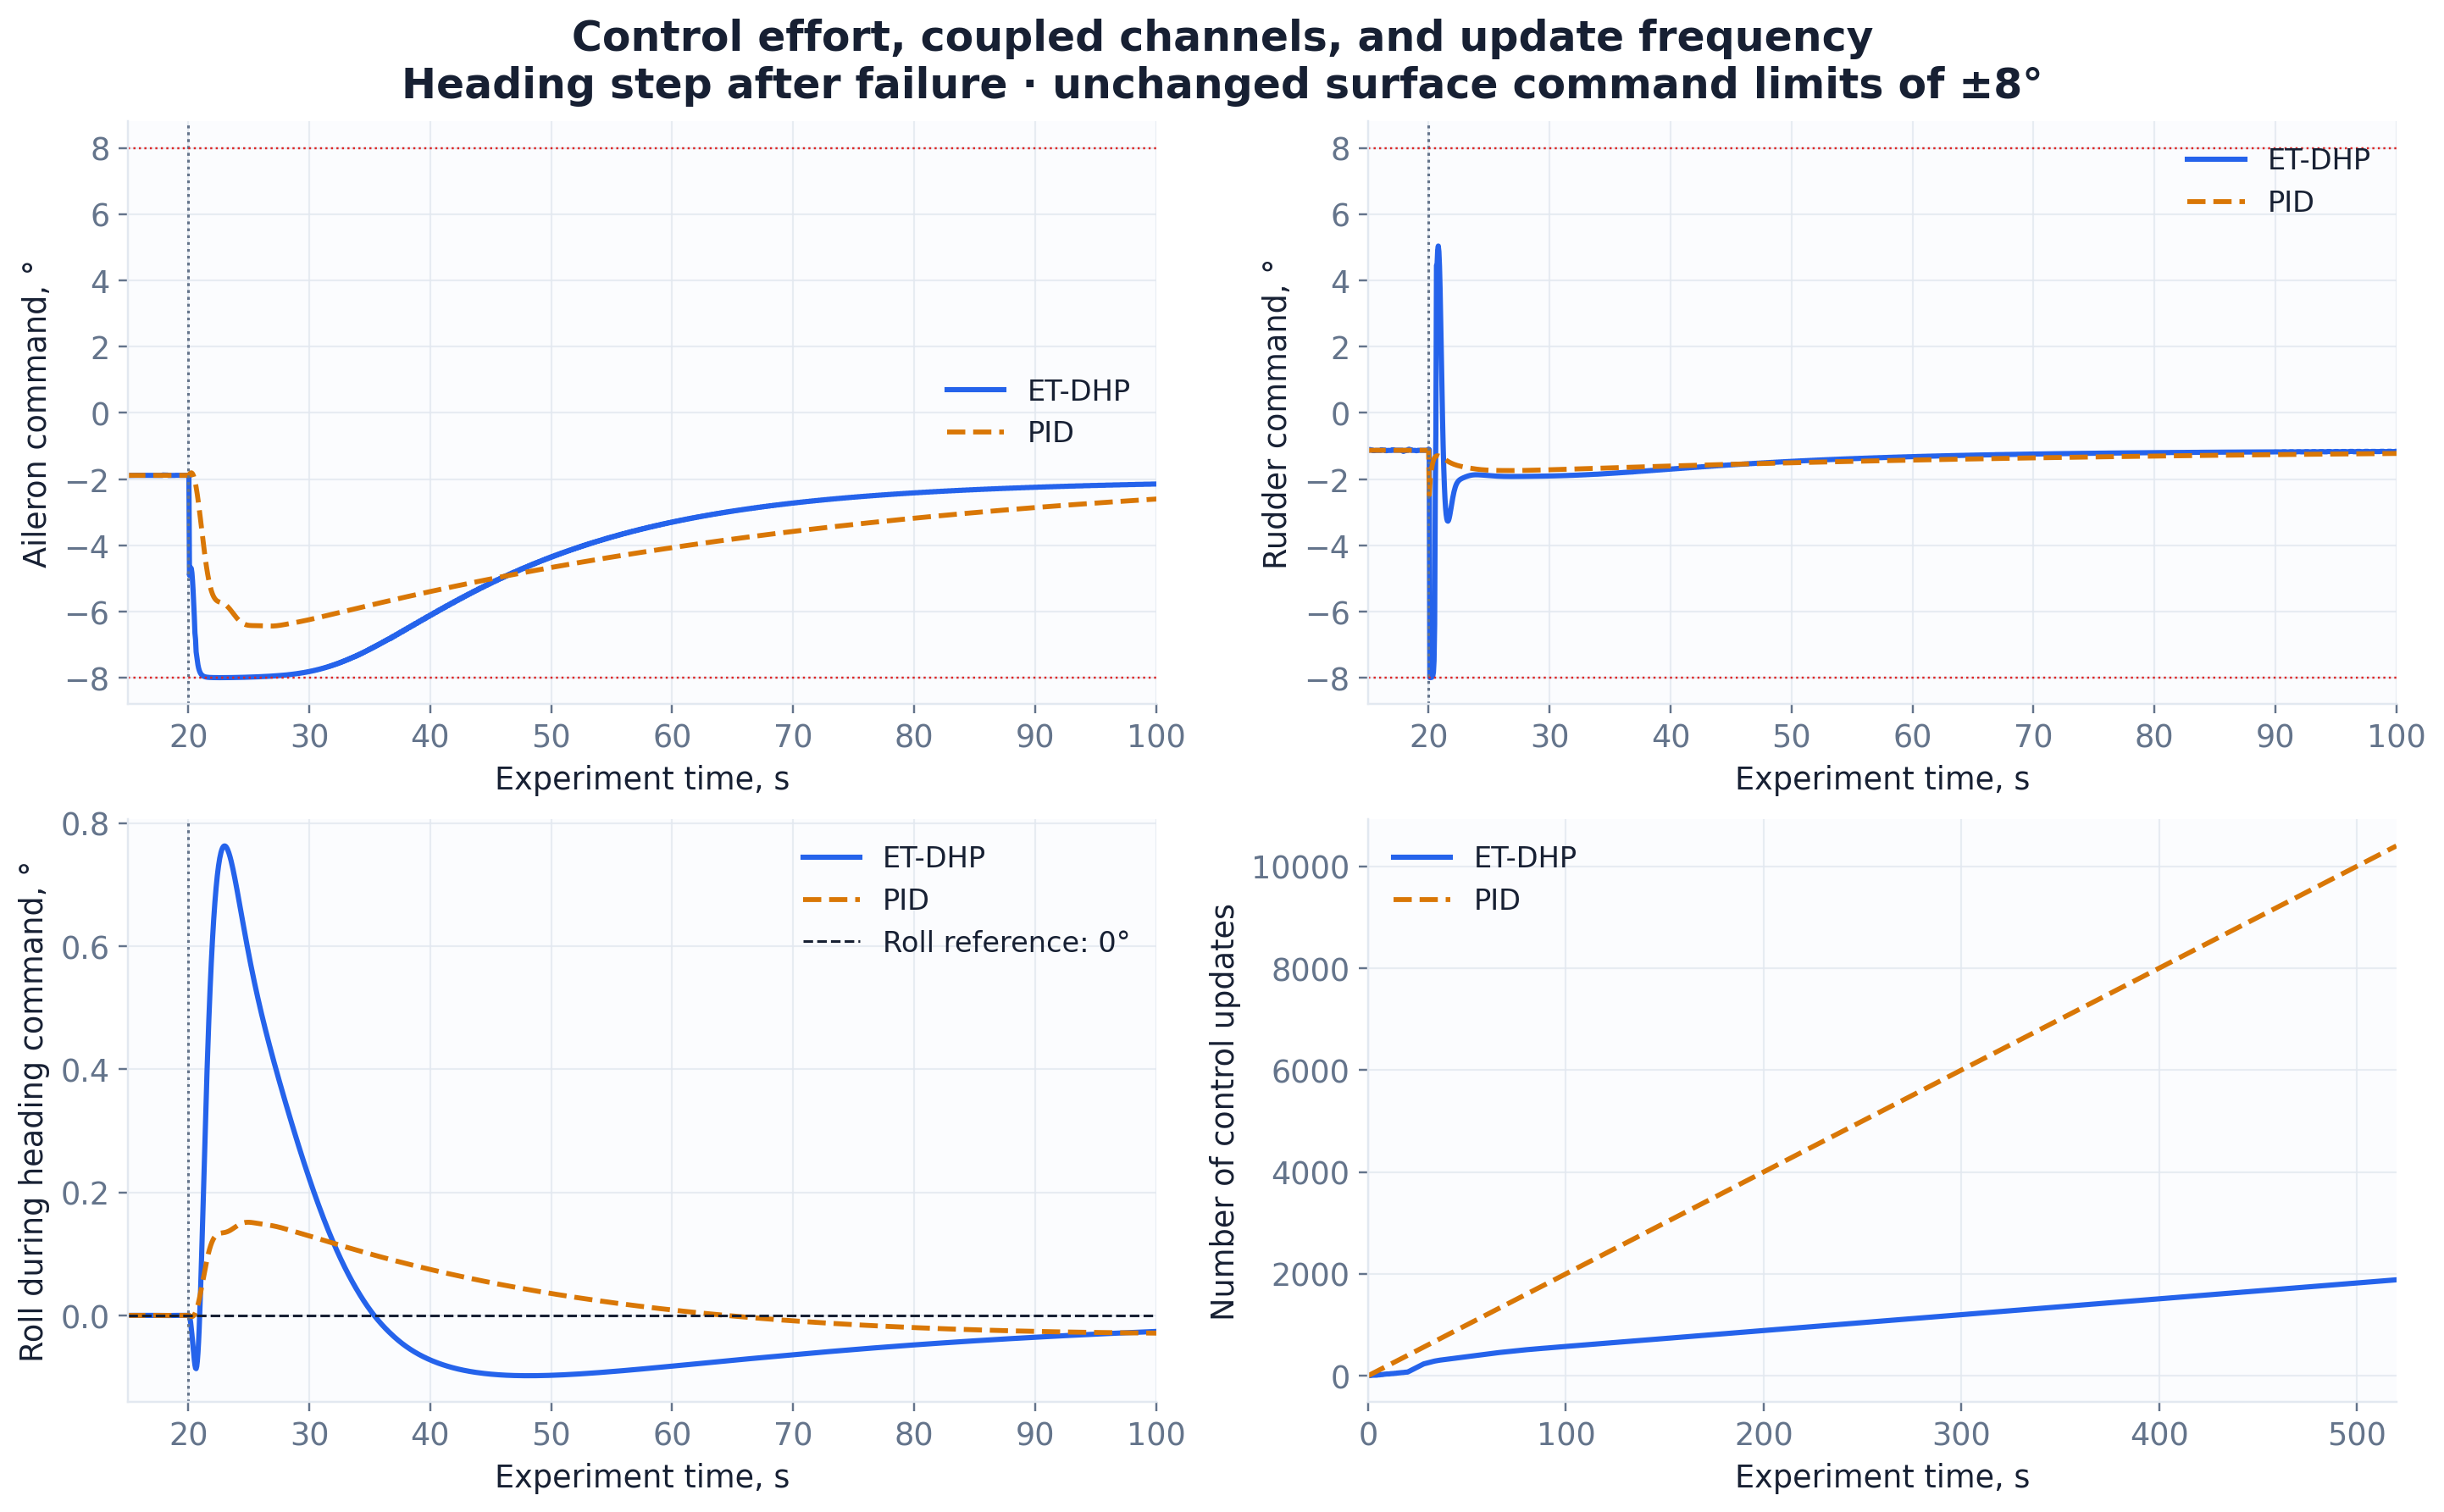

Aircraft,Step,Controller,"∫(δa²+δr²)dt, °²·s","Peak |roll|, °","Peak |sideslip|, °","Updates, % of control steps"
Healthy,Heading,ET-DHP,1045.1,0.516,0.866,20.3
Healthy,Heading,PID,571.4,0.151,0.333,100.0
Healthy,Roll,ET-DHP,10393.0,0.521,0.344,18.0
Healthy,Roll,PID,10062.4,0.639,0.350,100.0
After failure,Heading,ET-DHP,4064.7,0.763,1.014,18.1
After failure,Heading,PID,3797.3,0.151,0.522,100.0
After failure,Roll,ET-DHP,3692.4,0.521,0.256,19.9
After failure,Roll,PID,3573.9,0.646,0.189,100.0


### Held-out validation scenarios

Scenario,"ET-DHP settling ±2%, s","PID settling ±2%, s",ET-DHP IAE,PID IAE,ET-DHP JΣ,PID JΣ
Complete right-engine loss · heading,69.15,212.15,6.090,18.357,203.512,225.275
Complete right-engine loss · roll,64.50,174.55,0.762,3.280,219.652,237.493
Inboard engine · heading,62.85,212.65,8.848,30.488,379.563,386.695
Inboard engine · roll,2.60,168.85,0.524,5.479,354.354,372.019
25 ms physics step · heading,60.90,209.25,6.022,23.946,21.883,34.486
25 ms physics step · roll,2.60,166.10,0.810,7.526,14.350,43.825


Complete right-engine loss: engine 4 at 93.5 s, commands of −0.75° heading / −0.2° roll. Inboard engine: engine 2 retains 30% thrust at 287.5 s, commands of +1.25° / +0.35°. The last two rows refine only the physics step to 25 ms, keeping control at 20 Hz.

### Changes relative to the original example

Q/R, nominal network initialization, learning rates, and trigger parameters were changed. ET-DHP equations are unchanged and checked against the paper with analytical tests. The improvement cannot be attributed to online learning alone: the initial policy also changed. The nominal model stays fixed throughout the flight; the actor and critic continue learning.

In [3]:
def show_tuned_results():
    labels = ['Heading','Roll','Speed','Altitude']
    units = ['°','°','m/s','m']
    names = tuned_demo.steps.CHANNELS
    colors = {'etdhp':BLUE,'pid':ORANGE,'old':'#94A3B8'}
    old_dir = data_dir/'step_response'
    old_report = json.loads((old_dir/'metrics.json').read_text())['runs']
    standard = tuned_standard
    def trace(key,folder='standard'):
        return np.loadtxt(tuned_root/folder/f'{key}.csv',delimiter=',',skiprows=1)
    def table(rows):
        display(HTML('<div style="overflow-x:auto">'+pd.DataFrame(rows).to_html(index=False,border=0)+'</div>'))
    def value(number,digits=2):
        return 'not confirmed' if number is None else f'{number:.{digits}f}'
    for condition,condition_label in [('healthy','Healthy aircraft'),('fault','After thrust loss')]:
        fig,axes = plt.subplots(2,2,figsize=(13,8),layout='constrained')
        for ch in (0,1):
            target = tuned_demo.steps.STEP_AMPLITUDES[ch]
            for row,window in enumerate([(0,520),(18,90)]):
                ax=axes[row,ch]
                ax.fill_between([20,window[1]],.98*target,1.02*target,color='#16A34A',alpha=.13,label='±2% band')
                old=np.loadtxt(old_dir/f'{condition}_etdhp_{names[ch]}.csv',delimiter=',',skiprows=1)
                ax.plot(old[:,0],old[:,2+ch],color=colors['old'],lw=1.1,alpha=.9,label='ET-DHP before tuning')
                for algo in ('etdhp','pid'):
                    x=trace(f'{condition}_{algo}_{names[ch]}')
                    ax.plot(x[:,0],x[:,2+ch],**STYLES[algo])
                ax.step([0,20,520],[0,target,target],where='post',color=INK,ls=(0,(5,3)),lw=1.5,label='Reference',zorder=5)
                ax.set(xlim=window,xlabel='Experiment time, s',ylabel=f'{labels[ch]}, {units[ch]}')
                ax.set_title(labels[ch]+(' · full response' if row==0 else ' · initial response'),loc='left',fontsize=12)
                if row==0:ax.legend(loc='best',fontsize=9)
        heading(fig, f'Tuned ET-DHP — {condition_label.lower()}',
                'Step at 20 s · 500 s after the command · no parameter switching at failure')
        show_export(fig,f'tuned_01_steps_{condition}')

    display(Markdown('### Settling time and tracking accuracy'))
    rows=[]
    for condition,condition_label in [('healthy','Healthy'),('fault','After failure')]:
        for ch in range(4):
            for algo in ('etdhp','pid'):
                r=standard[f'{condition}_{algo}_{names[ch]}'];mtr=r['metrics']
                rows.append({'Aircraft':condition_label,'Channel':f'{labels[ch]}, {units[ch]}','Controller':STYLES[algo]['label'],
                             'Rise time 10–90%, s':value(mtr['rise_10_90_s']),
                             'Settling ±2%, s':value(mtr['settling_2pct_s']),'Settling ±5%, s':value(mtr['settling_5pct_s']),
                             'Overshoot, %':value(mtr['overshoot_pct']),
                             'Residual error':value(mtr['tail_bias'],5),'Tail standard deviation':value(mtr['tail_std'],5),
                             'IAE':value(mtr['iae'],3),'RMSE':value(mtr['rmse'],4)})
    table(rows)
    pd.DataFrame(rows).to_csv(tuned_root/'step_metrics_en.csv',index=False)
    display(Markdown('Residual error is the mean of output minus reference over the last 50 s. Without confirmed settling, it is not a verified steady-state error.'))

    fig,axes=plt.subplots(2,2,figsize=(13,8),layout='constrained')
    summary_rows=[]
    for row,(condition,condition_label) in enumerate([('healthy','Healthy'),('fault','After failure')]):
        for ch in (0,1):
            ax=axes[row,ch]
            for algo in ('etdhp','pid'):
                key=f'{condition}_{algo}_{names[ch]}';x=trace(key);mask=x[:,0]>=20
                normalized_error=np.abs(x[mask,2:6]-x[mask,6:10]).sum(axis=1)
                cumulative=cumulative_trapezoid(normalized_error,x[mask,0],initial=0)
                ax.plot(x[mask,0]-20,cumulative,**STYLES[algo])
                r=standard[key]
                summary_rows.append({'Aircraft':condition_label,'Step':labels[ch],
                                     'Controller':STYLES[algo]['label'],
                                     **{f'IAE {label}':value(v,3) for label,v in zip(labels,r['all_channel_iae'])},
                                     'JΣ, s':value(sum(r['all_channel_iae']),3)})
            ax.set(xlim=(0,500),xlabel='Time after command, s',ylabel='Cumulative total error JΣ, s')
            ax.set_title(f'{condition_label} · {labels[ch].lower()} step',loc='left',fontsize=12)
            ax.legend()
    heading(fig,'Total error across all reference channels',
            'Scales: 1° heading · 1° roll · 1 m/s speed · 1 m altitude')
    show_export(fig,'tuned_02_all_channel_error')
    table(summary_rows)
    pd.DataFrame(summary_rows).to_csv(tuned_root/'all_channel_metrics_en.csv',index=False)

    fig,axes=plt.subplots(2,2,figsize=(13,8),layout='constrained')
    hold_panels=[(1,1.,0.,'Heading ψ, °'),(2,1.,0.,'Roll φ, °'),
                 (4,.3048,demo.SPEED*.3048,'Speed V, m/s'),
                 (5,.3048,demo.ALTITUDE*.3048,'Altitude h, m')]
    for ax,(idx,factor,target,ylabel) in zip(axes.flat,hold_panels):
        for algo in ('etdhp','pid'):
            x=trace('standard_hold_'+algo,'held_out')
            ax.plot(x[:,0],target+factor*x[:,idx],**STYLES[algo])
        ax.axhline(target,color=INK,ls=(0,(5,3)),lw=1.4,label='Reference',zorder=5)
        ax.axvline(137,color=MUTED,ls=':',lw=1.2,label='Failure: 137 s')
        ax.set(xlim=(0,500),xlabel='Flight time, s',ylabel=ylabel)
        ax.ticklabel_format(axis='y',style='plain',useOffset=False)
        ax.legend(fontsize=9)
    heading(fig,'Failure during reference holding',
            'Engine 1 loses 50% thrust · learning continues before and after failure')
    show_export(fig,'tuned_03_unknown_fault_hold')

    fig,axes=plt.subplots(2,2,figsize=(13,8),layout='constrained')
    for algo in ('etdhp','pid'):
        x=trace('fault_'+algo+'_heading_deg')
        for ax,idx,label in [(axes[0,0],11,'Aileron command, °'),(axes[0,1],12,'Rudder command, °'),
                             (axes[1,0],3,'Roll during heading command, °')]:
            ax.plot(x[:,0],x[:,idx],**STYLES[algo]);ax.set(xlim=(15,100),xlabel='Experiment time, s',ylabel=label)
            ax.axvline(20,color=MUTED,ls=':',lw=1);ax.legend()
        updates=np.r_[0,np.cumsum(x[1:,15])] if algo=='etdhp' else np.arange(len(x))
        axes[1,1].plot(x[:,0],updates,**STYLES[algo])
    for ax in axes[0]:
        ax.axhline(8,color=RED,ls=':',lw=.8);ax.axhline(-8,color=RED,ls=':',lw=.8)
    axes[1,0].axhline(0,color=INK,ls='--',lw=1,label='Roll reference: 0°');axes[1,0].legend()
    axes[1,1].set(xlim=(0,520),xlabel='Experiment time, s',ylabel='Number of control updates')
    axes[1,1].legend()
    heading(fig,'Control effort, coupled channels, and update frequency',
            'Heading step after failure · unchanged surface command limits of ±8°')
    show_export(fig,'tuned_04_control_tradeoffs')
    effort=[]
    for condition in ('healthy','fault'):
        for ch in (0,1):
            for algo in ('etdhp','pid'):
                r=standard[f'{condition}_{algo}_{names[ch]}']
                effort.append({'Aircraft':'Healthy' if condition=='healthy' else 'After failure',
                               'Step':labels[ch],'Controller':STYLES[algo]['label'],
                               '∫(δa²+δr²)dt, °²·s':value(r['command_energy'],1),
                               'Peak |roll|, °':value(r['roll_peak'],3),
                               'Peak |sideslip|, °':value(r['beta_peak'],3),
                               'Updates, % of control steps':value(100*r['trigger_fraction'] if algo=='etdhp' else 100,1)})
    table(effort)
    display(Markdown('### Held-out validation scenarios'))
    check_rows=[]
    for scenario in tuned_demo.HELD_OUT_CASES:
        a=tuned_checks[scenario+'_etdhp'];b=tuned_checks[scenario+'_pid']
        scenario_labels={'right_full_heading':'Complete right-engine loss · heading','right_full_roll':'Complete right-engine loss · roll','inboard_heading':'Inboard engine · heading','inboard_roll':'Inboard engine · roll','fine_physics_heading':'25 ms physics step · heading','fine_physics_roll':'25 ms physics step · roll'}
        check_rows.append({'Scenario':scenario_labels[scenario],'ET-DHP settling ±2%, s':value(a['metrics']['settling_2pct_s']),
                           'PID settling ±2%, s':value(b['metrics']['settling_2pct_s']),
                           'ET-DHP IAE':value(a['metrics']['iae'],3),'PID IAE':value(b['metrics']['iae'],3),
                           'ET-DHP JΣ':value(sum(a['all_channel_iae']),3),'PID JΣ':value(sum(b['all_channel_iae']),3)})
    table(check_rows)
    display(Markdown('Complete right-engine loss: engine 4 at 93.5 s, commands of −0.75° heading / −0.2° roll. Inboard engine: engine 2 retains 30% thrust at 287.5 s, commands of +1.25° / +0.35°. The last two rows refine only the physics step to 25 ms, keeping control at 20 Hz.'))
    display(Markdown('### Changes relative to the original example'))
    display(Markdown('Q/R, nominal network initialization, learning rates, and trigger parameters were changed. ET-DHP equations are unchanged and checked against the paper with analytical tests. The improvement cannot be attributed to online learning alone: the initial policy also changed. The nominal model stays fixed throughout the flight; the actor and critic continue learning.'))

show_tuned_results()

---
# Original ET-DHP configuration — results before tuning

The following plots, metrics, and online model-learning experiment retain the **original parameters**. The final configuration and its validation appear above, allowing comparison with the initial example.

## Reference signals and measured flight response

The original experiment has constant references: **heading 0°, roll 0°, speed 205.4352 m/s, altitude 6096 m**. Black dashed lines show the references; colored lines show the measured B747 response. Initial heading and roll offsets are not reference steps. The vertical line marks the 50% thrust loss of engine 1 at 137 seconds. Separate experiments with actual reference steps appear below.

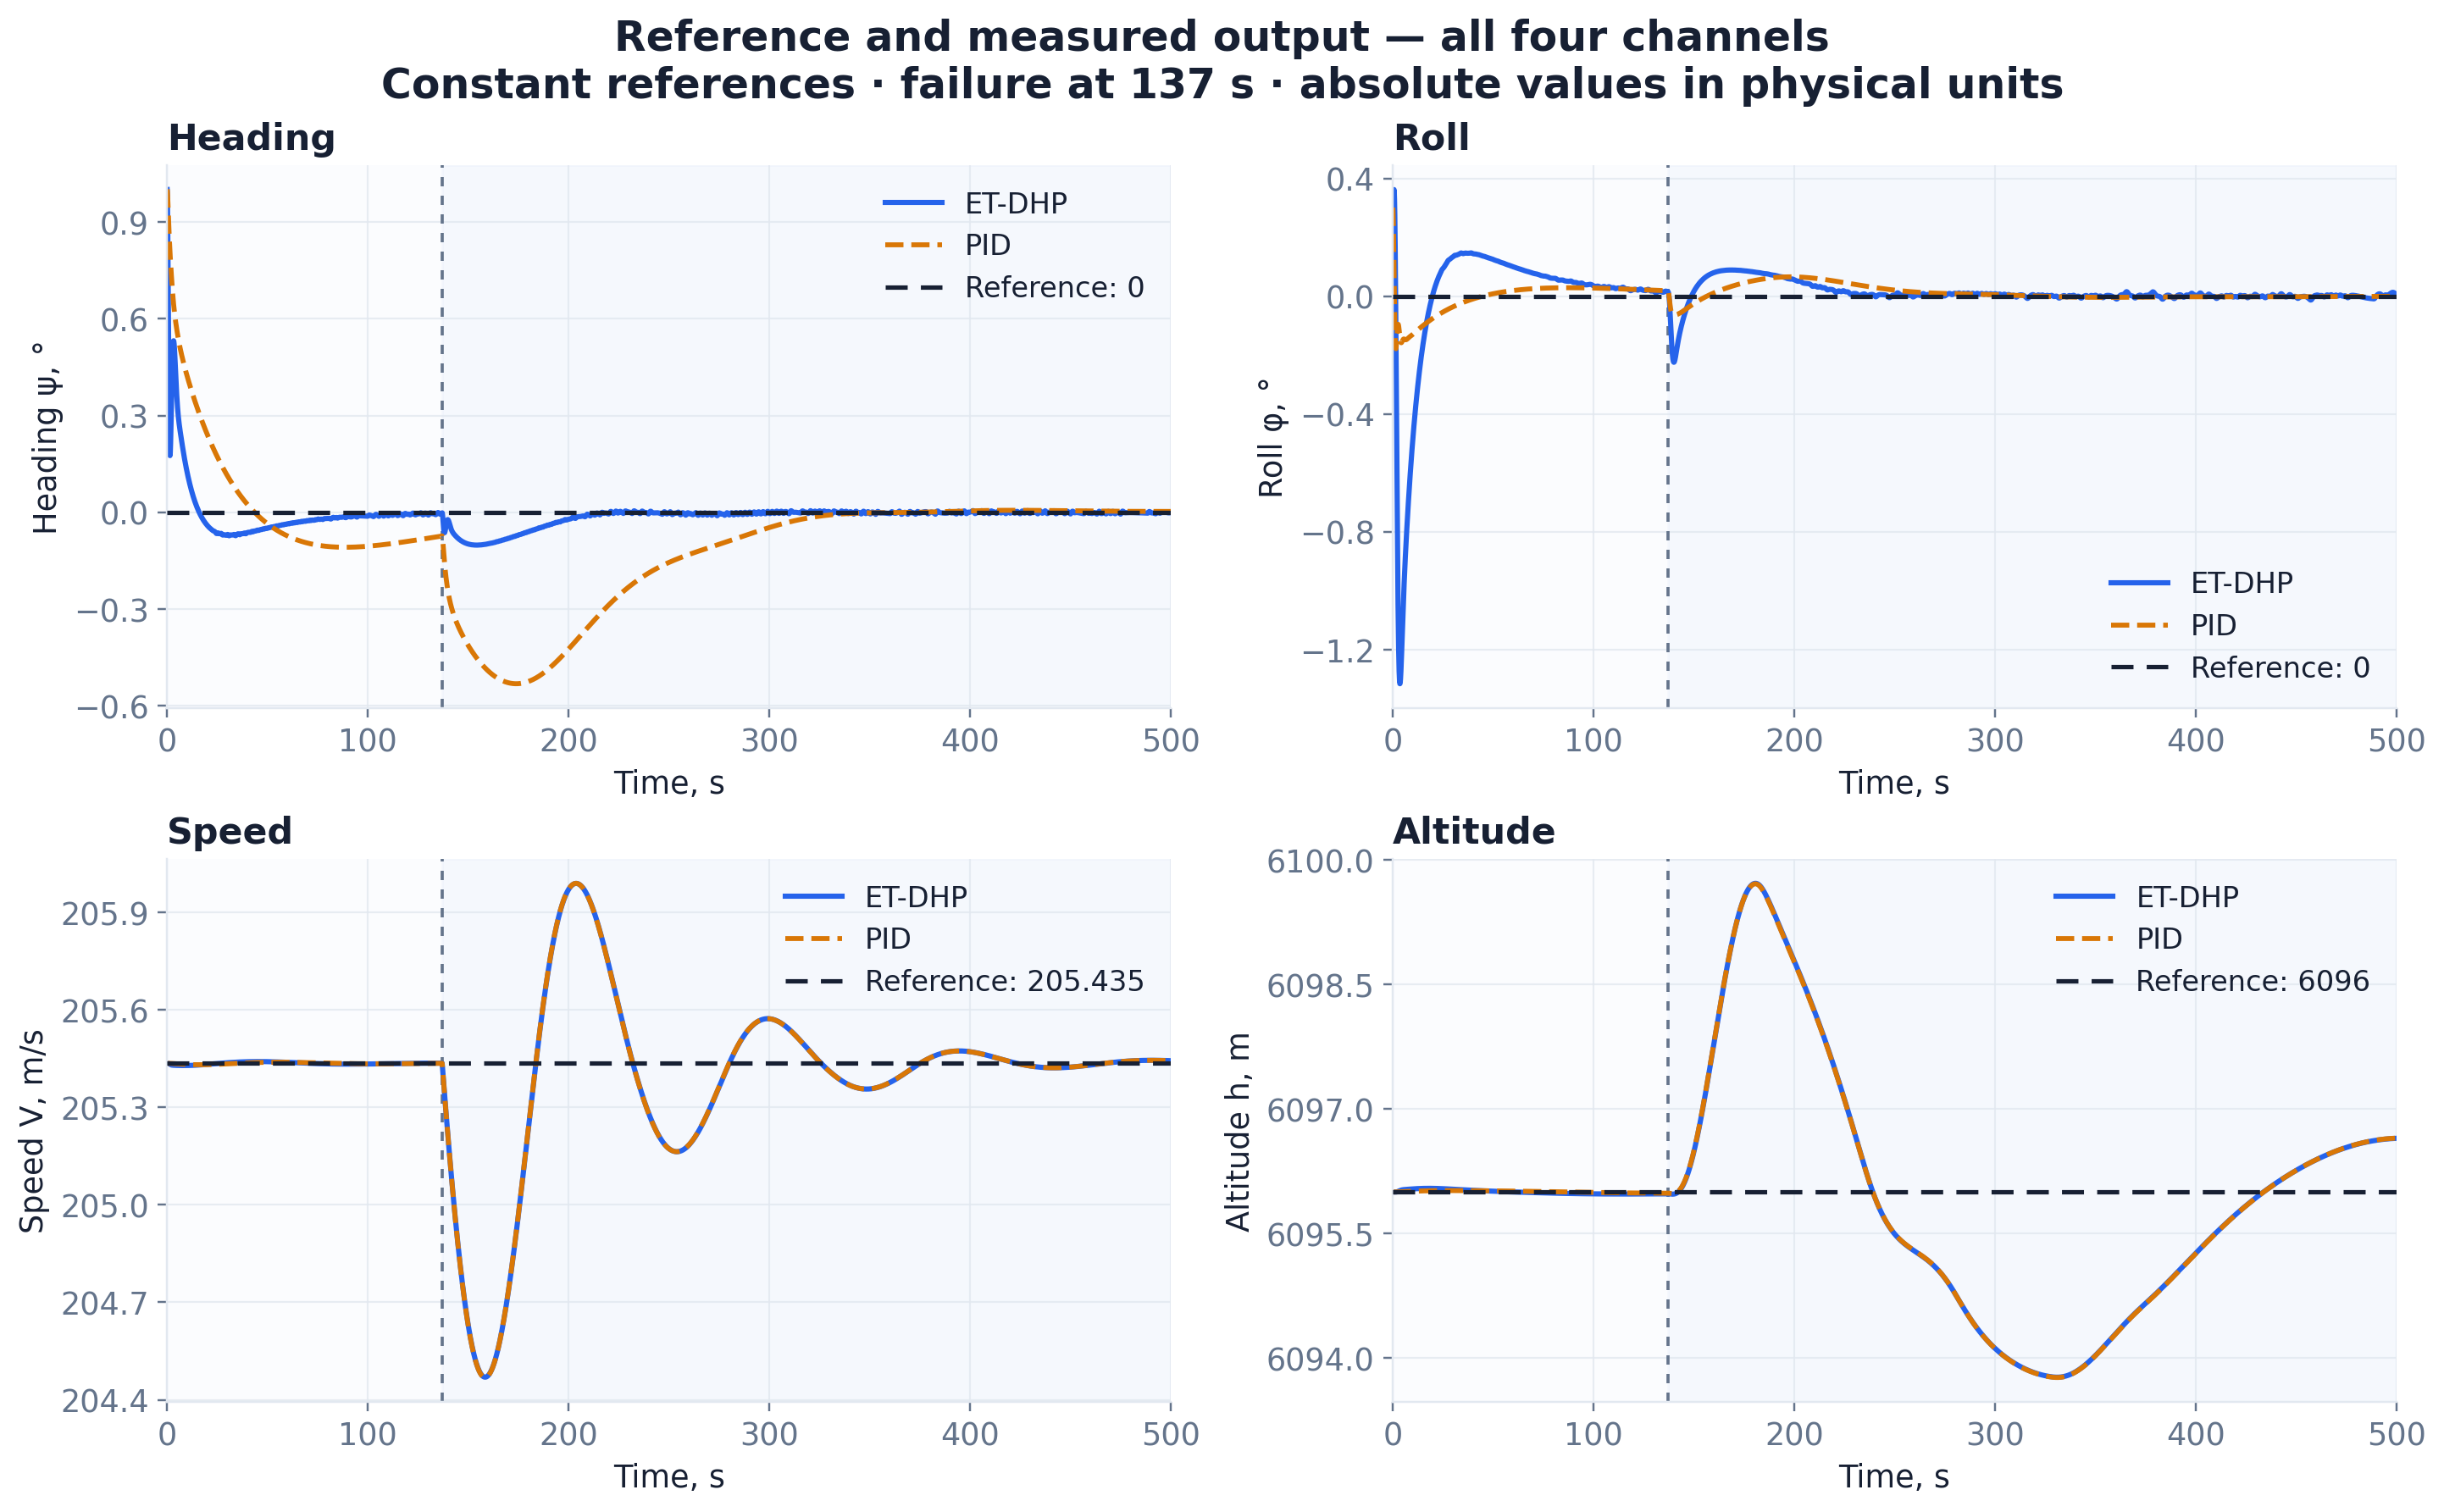

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout='constrained')
reference_panels = [
    ('Heading', 'psi_deg', 1., 0., 'Heading ψ, °'),
    ('Roll', 'phi_deg', 1., 0., 'Roll φ, °'),
    ('Speed', 'speed_error_ft_s', .3048, demo.SPEED*.3048, 'Speed V, m/s'),
    ('Altitude', 'height_error_ft', .3048, demo.ALTITUDE*.3048, 'Altitude h, m'),
]
for ax, (title, field, factor, target, ylabel) in zip(axes.flat, reference_panels):
    for algo in ('etdhp', 'pid'):
        x = traces[f'fault_{algo}']
        # Include the known initial state; the saved trace starts at dt.
        initial = {'psi_deg': cfg.initial_heading_deg, 'phi_deg': cfg.initial_roll_deg}.get(field, target)
        ax.plot(np.r_[0, x[:, 0]], np.r_[initial, target+factor*x[:, column[field]]], **STYLES[algo])
    ax.axhline(target, color=INK, lw=1.7, ls=(0, (5, 3)), label=f'Reference: {target:g}', zorder=5)
    ax.set_title(title, loc='left')
    decorate(ax, ylabel, zero=False)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
heading(fig, 'Reference and measured output — all four channels',
        'Constant references · failure at 137 s · absolute values in physical units')
show_export(fig, '00_references_and_outputs')

## How total error is calculated

Degrees, m/s, and metres have different dimensions. Before adding absolute errors, each is divided by a **scale shared by all controllers**:

$$
E_\Sigma(t)=\frac{|\psi(t)-0|}{1^\circ}
+\frac{|\varphi(t)-0|}{1^\circ}
+\frac{|V(t)-205.4352|}{1\,\mathrm{m/s}}
+\frac{|h(t)-6096|}{1\,\mathrm{m}}.
$$

**Instantaneous total error** $E_\Sigma$ is dimensionless. Absolute values prevent positive and negative errors from canceling each other.

**Cumulative total error** over a window $[a,b]$:

$$J_\Sigma[a,b]=\Delta t\sum_{a<t_k\le b}E_\Sigma(t_k),\qquad \Delta t=0.05\,\mathrm{s}.$$

State samples are taken at the right endpoints of integration steps. The unit of $J_\Sigma$ is normalized error × seconds. Mean $E_\Sigma$ equals $J_\Sigma/(b-a)$.

**The scales 1°, 1°, 1 m/s, and 1 m are the weighting scheme chosen here, not certified aircraft tolerances.** They can be changed in the next cell; the overall comparison depends on this choice. Scales were not selected to favor a controller.

In [5]:
# Change the scales if your task uses different priorities or tolerances.
ERROR_SCALES = {
    'Heading': 1.0,       # degrees
    'Roll': 1.0,       # degrees
    'Speed': 1.0,   # m/s
    'Altitude': 1.0,     # metres
}
CHANNELS = [
    ('Heading', 'psi_deg', 1.0, '°'),
    ('Roll', 'phi_deg', 1.0, '°'),
    ('Speed', 'speed_error_ft_s', .3048, 'm/s'),
    ('Altitude', 'height_error_ft', .3048, 'm'),
]
CHANNEL_COLORS = ['#2563EB', '#8B5CF6', '#0891B2', '#94A3B8']
CHANNEL_NAMES = [name for name, _, _, _ in CHANNELS]
scales = np.array([ERROR_SCALES[name] for name in CHANNEL_NAMES], dtype=float)
assert np.isfinite(scales).all() and np.all(scales > 0)
scale_caption = ' · '.join(f'{ERROR_SCALES[name]:g} {unit}' for name, _, _, unit in CHANNELS)
dt = float(report['experiment']['dt'])
errors = {}
total_error_metrics = {}
WINDOWS = {
    'Full flight': (0, duration),
    'Before failure': (0, fault_time),
    'After failure': (fault_time, duration),
    'Last 100 s': (max(fault_time, duration-100), duration),
}
for name, x in traces.items():
    np.testing.assert_allclose(np.diff(np.r_[0, x[:, 0]]), dt, atol=1e-10, rtol=0)
    physical = np.column_stack([x[:, column[field]] * factor
                                for _, field, factor, _ in CHANNELS])
    normalized = np.abs(physical) / scales
    total = normalized.sum(axis=1)
    cumulative = dt * np.cumsum(total)
    errors[name] = {'physical': physical, 'normalized': normalized,
                    'total': total, 'cumulative': cumulative}
    total_error_metrics[name] = {}
    for window_name, (start, stop) in WINDOWS.items():
        mask = (x[:, 0] > start) & (x[:, 0] <= stop)
        components = dt * normalized[mask].sum(axis=0)
        integral = float(dt * total[mask].sum())
        np.testing.assert_allclose(integral, components.sum(), atol=1e-9, rtol=1e-12)
        total_error_metrics[name][window_name] = {
            'integral': integral,
            'mean': float(total[mask].mean()),
            'peak': float(total[mask].max()),
            'components': {key: float(value) for key, value in zip(CHANNEL_NAMES, components)},
        }
    assert np.all(np.diff(cumulative) >= 0)

sum_et = total_error_metrics['fault_etdhp']['After failure']['integral']
sum_pid = total_error_metrics['fault_pid']['After failure']['integral']
sum_reduction = 100 * (1-sum_et/sum_pid)

In [6]:
cards = [
    ('TOTAL ERROR AFTER FAILURE', f'{sum_et:.2f} / {sum_pid:.2f}', 'ET-DHP / PID · normalized s', BLUE),
    ('DIFFERENCE IN TOTAL ERROR', f'{sum_reduction:+.2f}%', 'Positive values mean lower ET-DHP error', BLUE if sum_reduction >= 0 else ORANGE),
    ('ROLL AFTER FAILURE', 'PID is more accurate', 'Better heading tracking does not imply an improvement in every channel', ORANGE),
]
items = ''.join(f'<div style="flex:1;min-width:200px;border:1px solid #e2e8f0;border-top:4px solid {color};border-radius:12px;padding:18px;background:#f8fafc"><div style="font-size:11px;letter-spacing:.05em;color:#475569">{label}</div><div style="font-size:25px;font-weight:700;color:{color};margin:10px 0">{value}</div><div style="font-size:13px;color:#334155">{detail}</div></div>' for label,value,detail,color in cards)
display(HTML('<div style="display:flex;flex-wrap:wrap;gap:12px;font-family:system-ui,sans-serif;margin:15px 0">'+items+'</div>'))
rows = ['| Window | JΣ ET-DHP, normalized s | JΣ PID, normalized s | Mean EΣ ET-DHP | Mean EΣ PID | ET-DHP JΣ reduction |', '|:---|---:|---:|---:|---:|---:|']
for window in WINDOWS:
    a = total_error_metrics['fault_etdhp'][window]
    b = total_error_metrics['fault_pid'][window]
    change = 100 * (1-a['integral']/b['integral'])
    rows.append(f"| {window} | {a['integral']:.3f} | {b['integral']:.3f} | {a['mean']:.5f} | {b['mean']:.5f} | {change:+.2f}% |")
display(Markdown('\n'.join(rows)))

| Window | JΣ ET-DHP, normalized s | JΣ PID, normalized s | Mean EΣ ET-DHP | Mean EΣ PID | ET-DHP JΣ reduction |
|:---|---:|---:|---:|---:|---:|
| Full flight | 570.551 | 611.484 | 1.14110 | 1.22297 | +6.69% |
| Before failure | 28.048 | 26.669 | 0.20473 | 0.19466 | -5.17% |
| After failure | 542.502 | 584.815 | 1.49450 | 1.61106 | +7.24% |
| Last 100 s | 40.945 | 41.154 | 0.40945 | 0.41154 | +0.51% |

## 1 · Total error across all four references

The upper panel shows the sum of normalized absolute errors at each instant. The lower panel shows accumulated error over the flight. Lower is better. The vertical line marks the failure; subsequent growth includes the response of the speed and altitude controller.

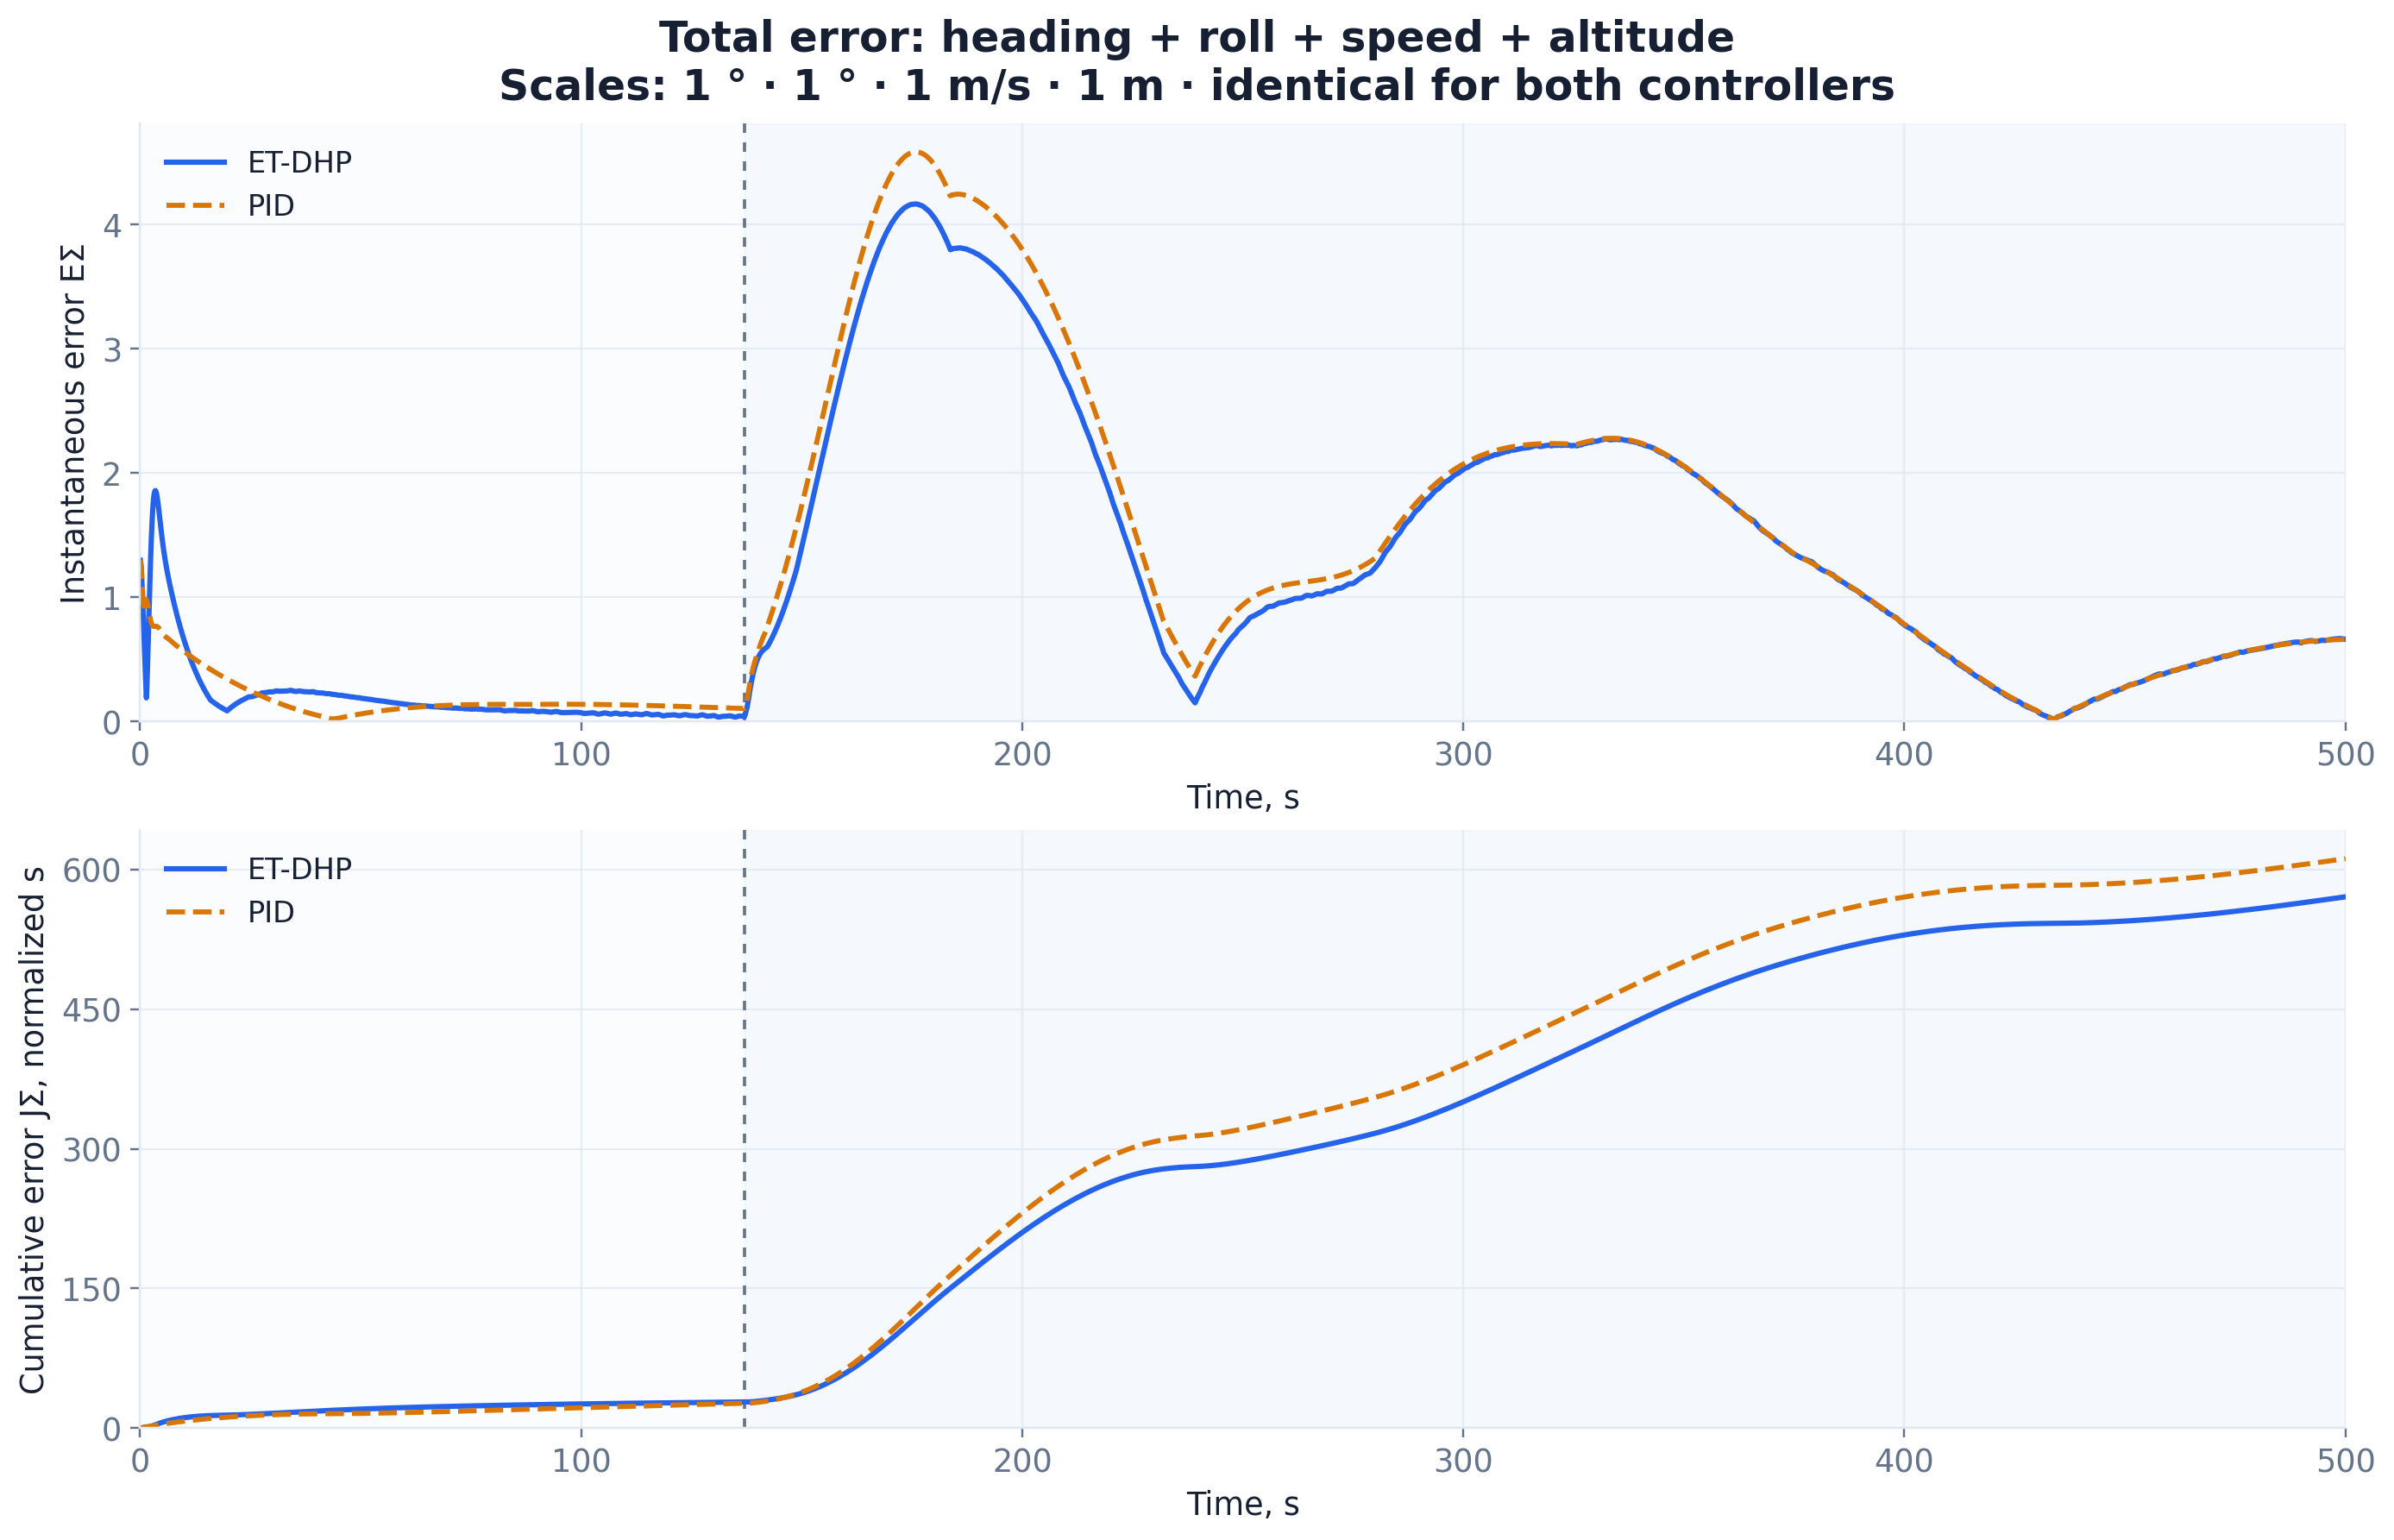

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8), constrained_layout=True)
heading(fig, 'Total error: heading + roll + speed + altitude', f'Scales: {scale_caption} · identical for both controllers')
for algo in ('etdhp', 'pid'):
    name = f'fault_{algo}'
    x = traces[name]
    axes[0].plot(x[:, 0], errors[name]['total'], **STYLES[algo])
    axes[1].plot(x[:, 0], errors[name]['cumulative'], **STYLES[algo])
decorate(axes[0], 'Instantaneous error EΣ', zero=False)
decorate(axes[1], 'Cumulative error JΣ, normalized s', zero=False)
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(bottom=0)
show_export(fig, '01_total_error')

## 2 · Post-failure error and channel contributions

On the left, accumulation restarts at failure, excluding the initial transient. On the right, the total is decomposed by channel to show which errors dominate under the selected scales.

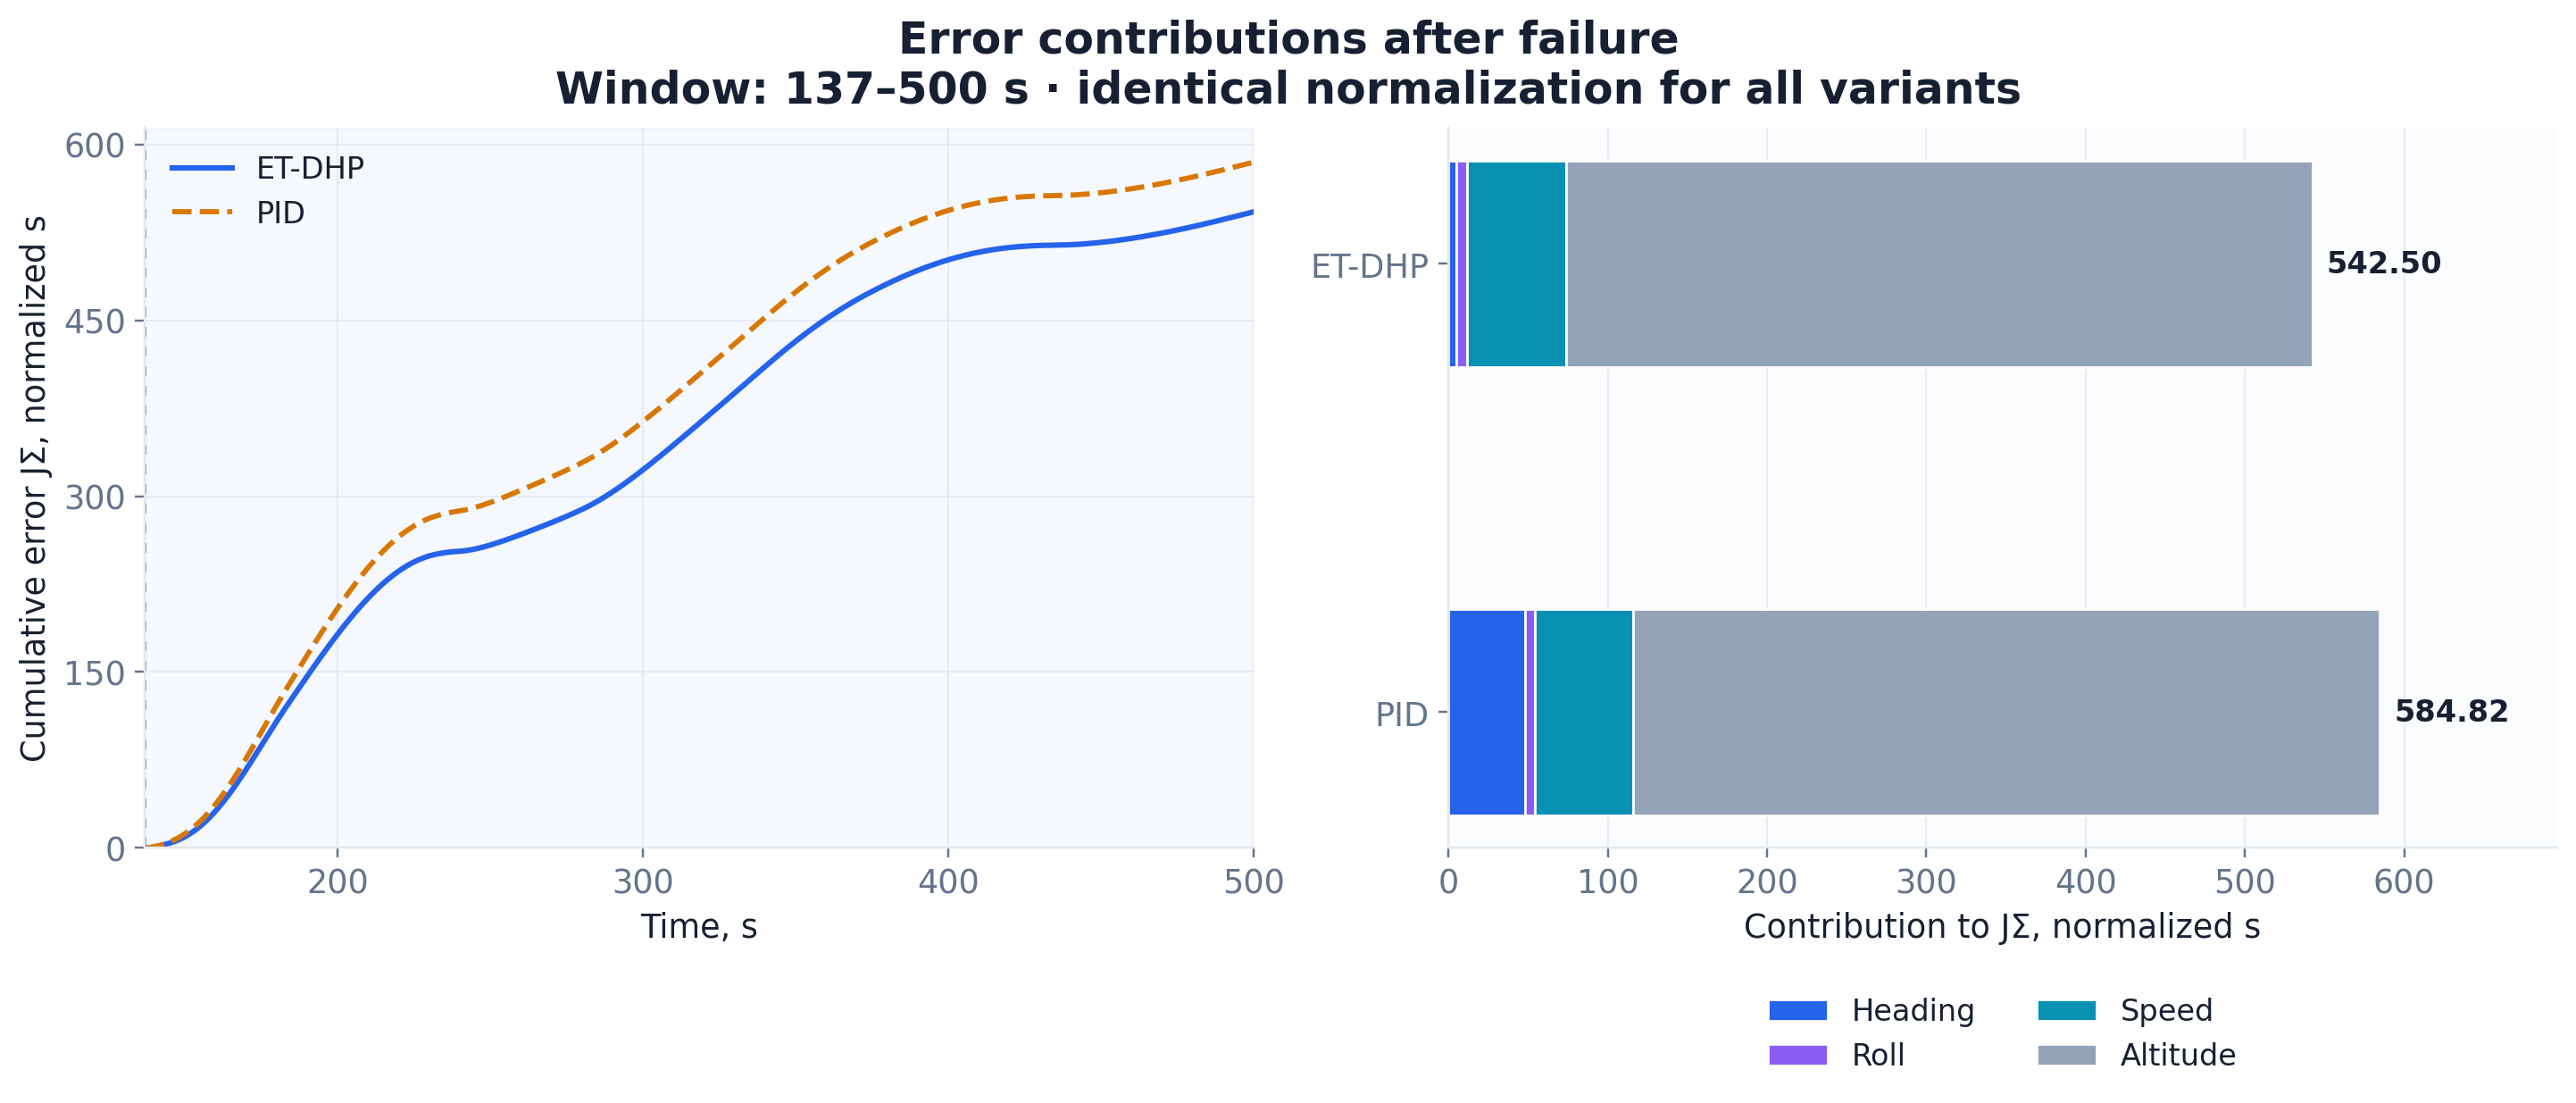

| Channel after failure | ET-DHP contribution, normalized s | PID contribution, normalized s |
|:---|---:|---:|
| Heading | 5.143 | 48.347 |
| Roll | 6.810 | 5.814 |
| Speed | 61.741 | 61.734 |
| Altitude | 468.807 | 468.920 |

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
heading(fig, 'Error contributions after failure', f'Window: {fault_time:g}–{duration:g} s · identical normalization for all variants')
component_matrix = []
for algo in ('etdhp', 'pid'):
    name = f'fault_{algo}'
    x = traces[name]
    mask = x[:, 0] > fault_time
    time = np.r_[fault_time, x[mask, 0]]
    cumulative = np.r_[0, dt*np.cumsum(errors[name]['total'][mask])]
    axes[0].plot(time, cumulative, **STYLES[algo])
    component_matrix.append([total_error_metrics[name]['After failure']['components'][key] for key in CHANNEL_NAMES])
decorate(axes[0], 'Cumulative error JΣ, normalized s', window=(fault_time, duration), zero=False)
axes[0].set_ylim(bottom=0)
component_matrix = np.array(component_matrix)
left = np.zeros(2)
for i, (label, color) in enumerate(zip(CHANNEL_NAMES, CHANNEL_COLORS)):
    axes[1].barh([0, 1], component_matrix[:, i], left=left, color=color, label=label,
                 height=.46, edgecolor='white', linewidth=.9)
    left += component_matrix[:, i]
for row, value in enumerate(left):
    axes[1].text(value+max(left)*.015, row, f'{value:.2f}', va='center', fontsize=11, fontweight='semibold')
axes[1].set(yticks=[0, 1], yticklabels=['ET-DHP', 'PID'], xlabel='Contribution to JΣ, normalized s', xlim=(0, max(left)*1.19))
axes[1].invert_yaxis()
axes[1].grid(axis='y', visible=False)
axes[1].set_axisbelow(True)
axes[1].legend(loc='upper center', bbox_to_anchor=(.5, -.17), ncol=2)
show_export(fig, '02_total_error_components')
rows = ['| Channel after failure | ET-DHP contribution, normalized s | PID contribution, normalized s |', '|:---|---:|---:|']
for i, key in enumerate(CHANNEL_NAMES):
    rows.append(f'| {key} | {component_matrix[0,i]:.3f} | {component_matrix[1,i]:.3f} |')
display(Markdown('\n'.join(rows)))

## 3 · Individual reference channels

Each channel shows deviation from its own reference. Zero means exact tracking. Speed and altitude use SI units; error signs are preserved.

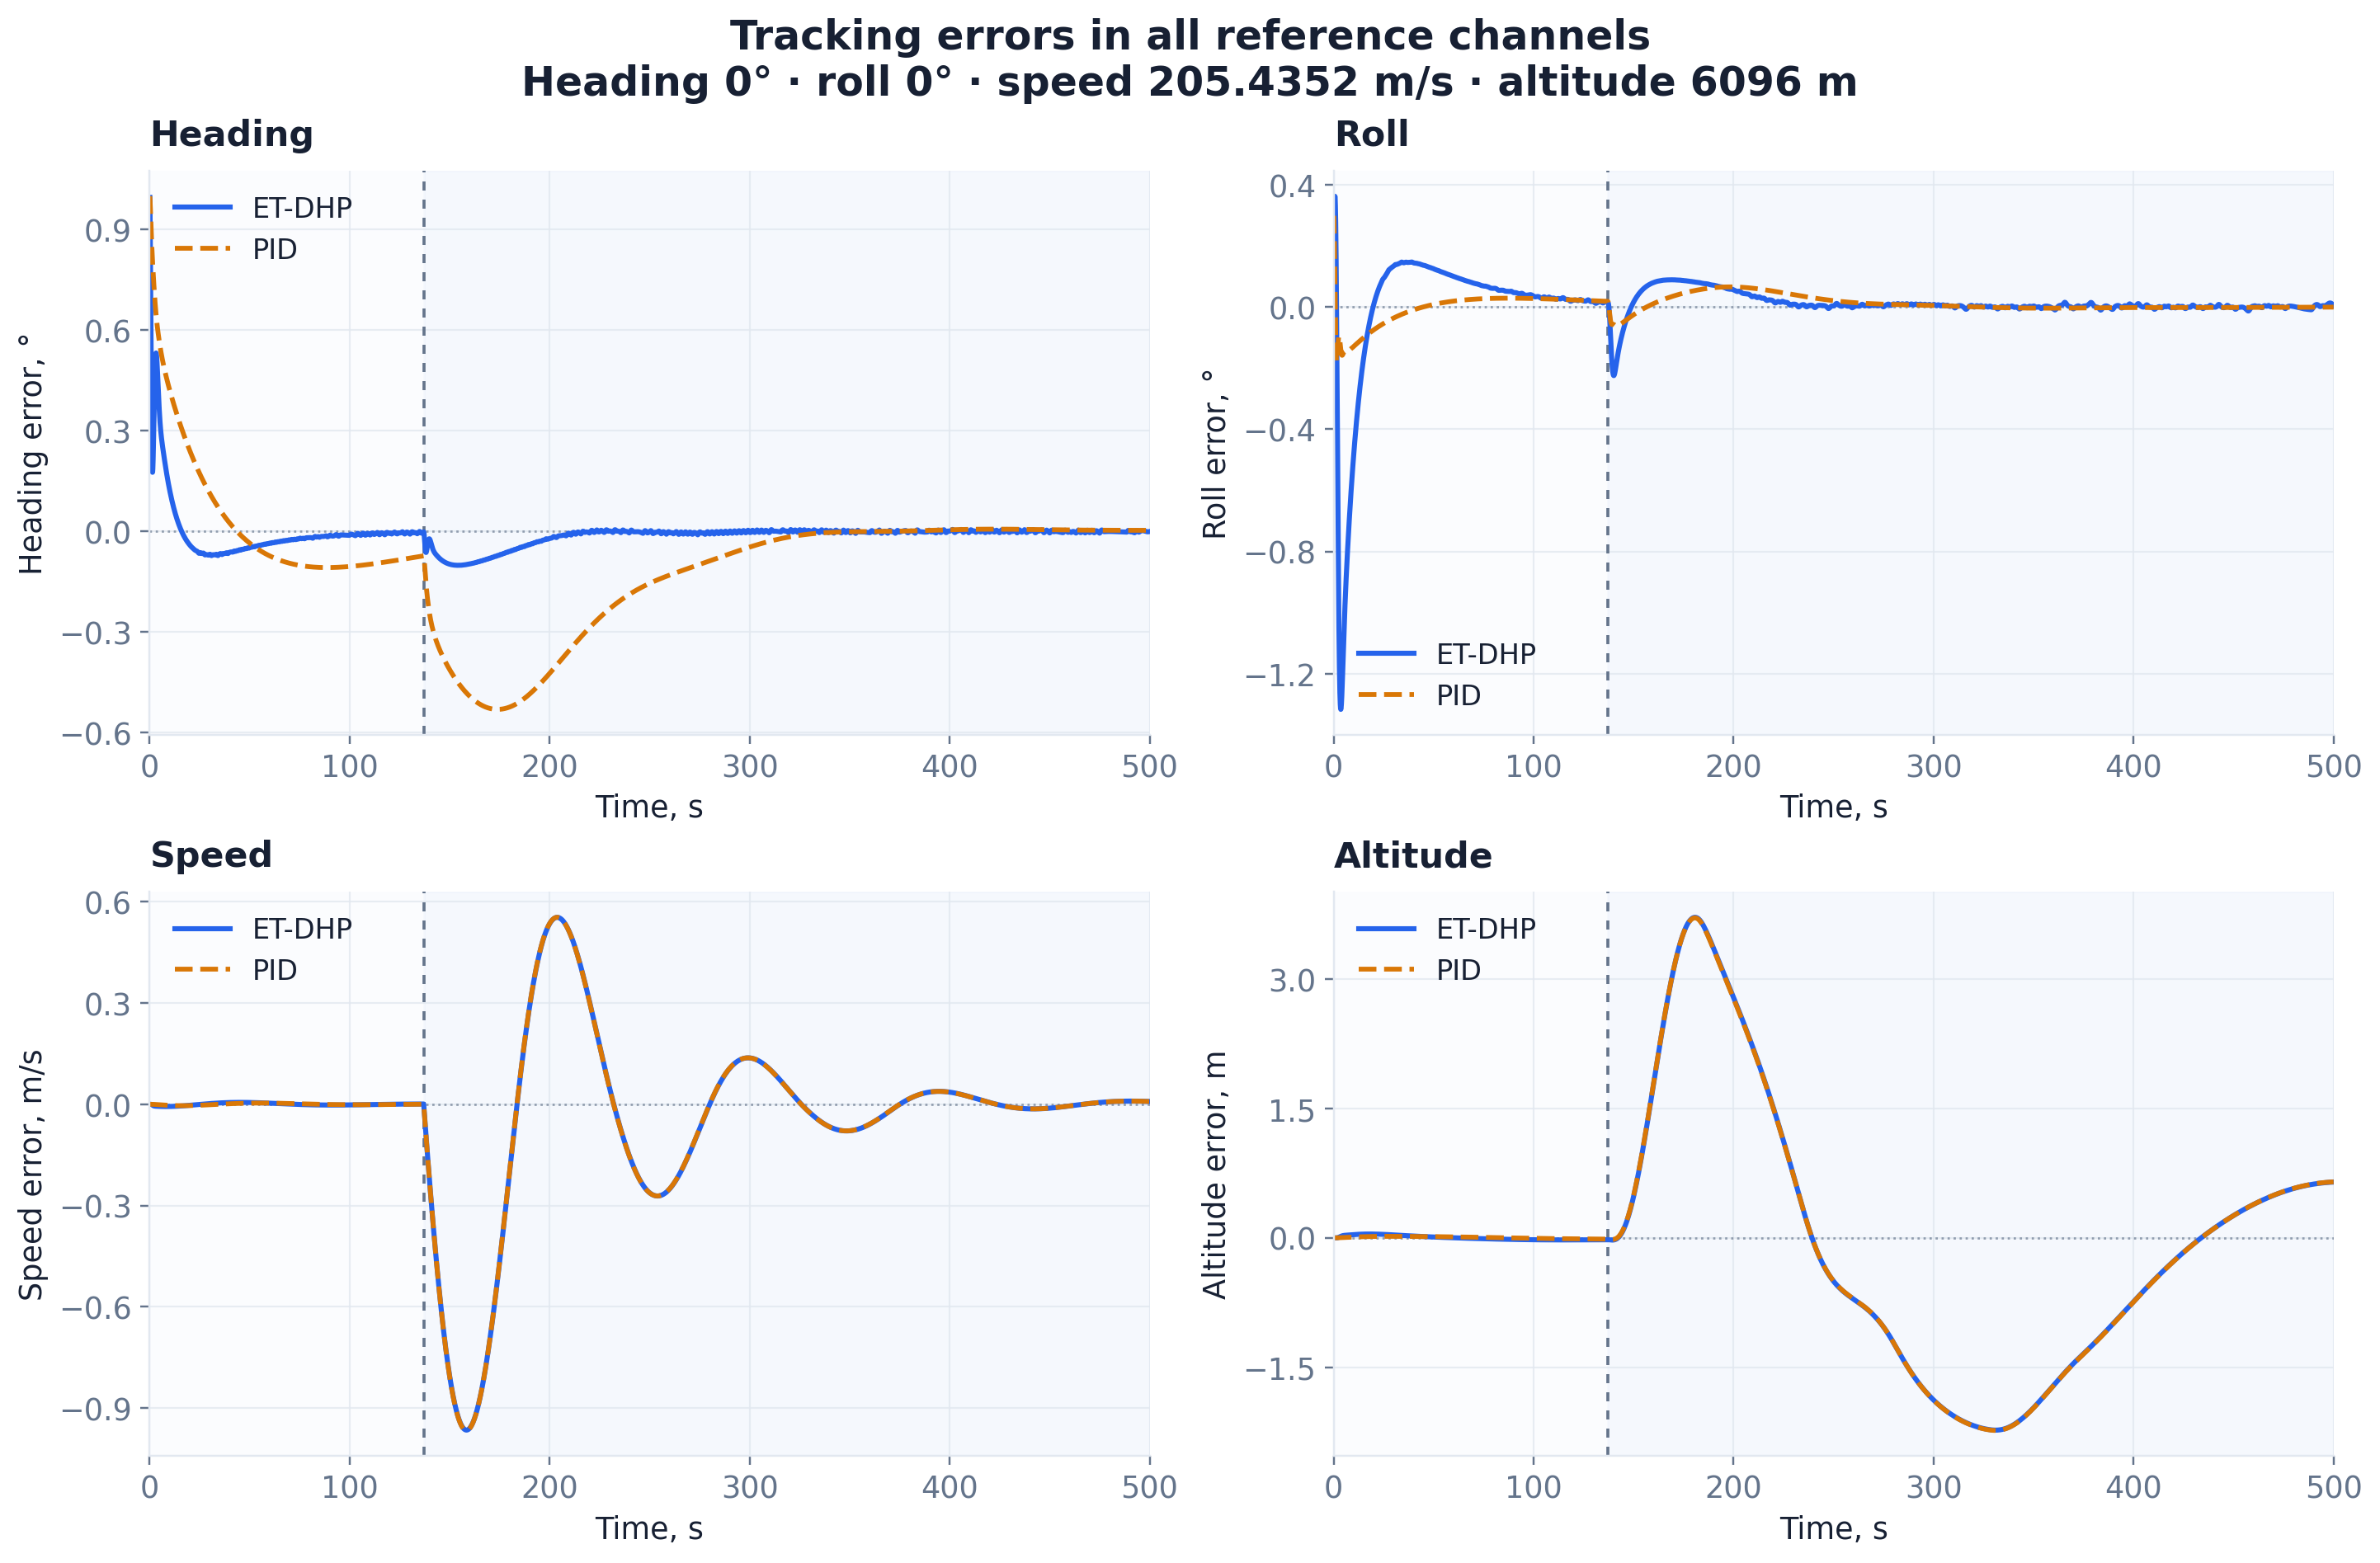

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)
heading(fig, 'Tracking errors in all reference channels', 'Heading 0° · roll 0° · speed 205.4352 m/s · altitude 6096 m')
for ax, (label, field, factor, unit) in zip(axes.flat, CHANNELS):
    pair(ax, field, scale=factor)
    decorate(ax, f'{label} error, {unit}')
    ax.set_title(label, loc='left', pad=10)
show_export(fig, '03_all_target_errors')

## 4 · Heading in detail

The left panel shows the failure response; the right panel zooms into the last 100 seconds. All samples are retained without smoothing.

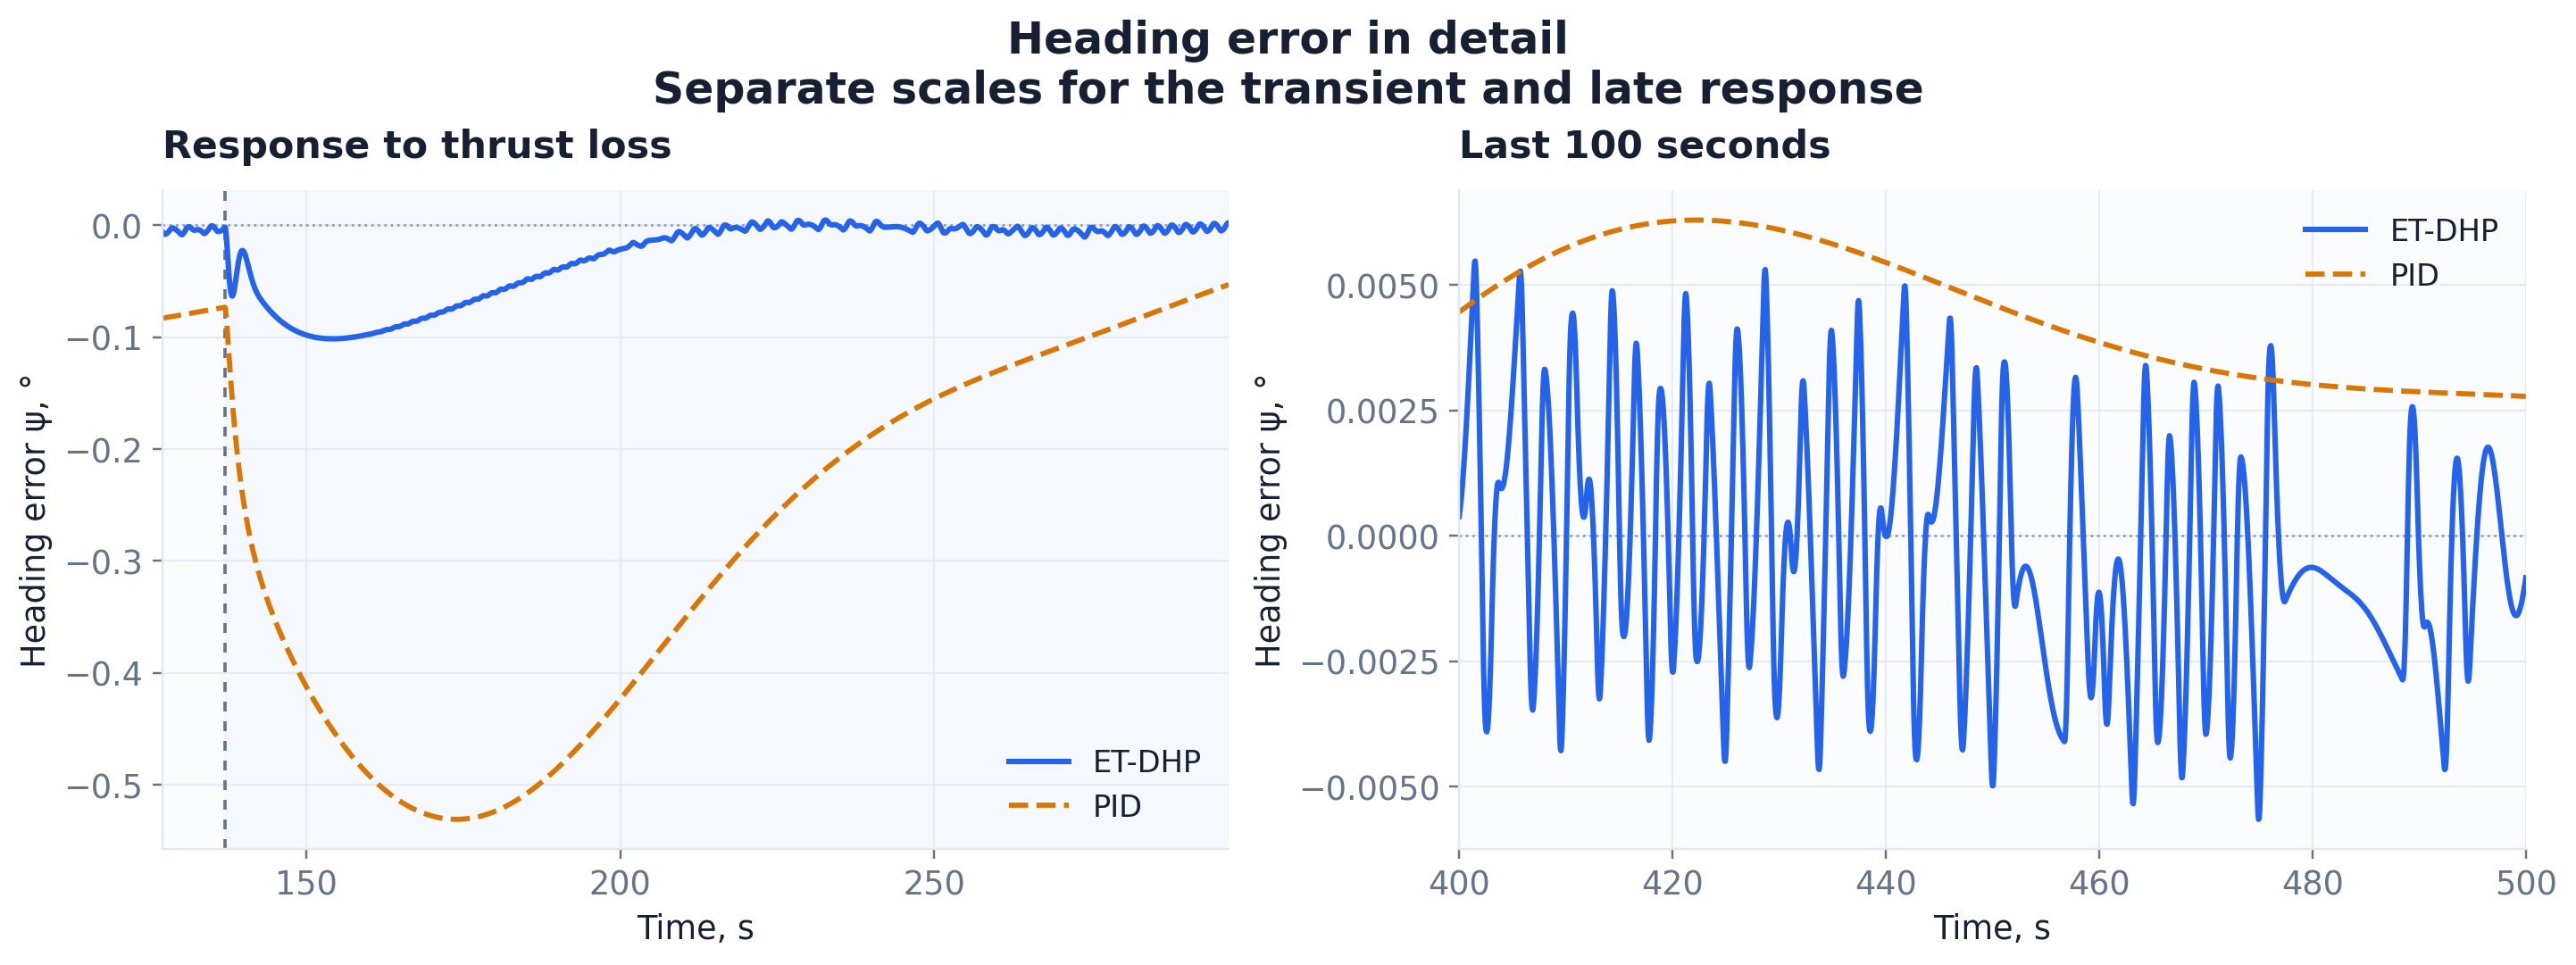

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
heading(fig, 'Heading error in detail', 'Separate scales for the transient and late response')
windows = [(max(0, fault_time-10), min(duration, fault_time+160)), (max(fault_time, duration-100), duration)]
for ax, window, title in zip(axes, windows, ['Response to thrust loss', 'Last 100 seconds']):
    pair(ax, 'psi_deg', window=window)
    decorate(ax, 'Heading error ψ, °', window=window)
    ax.set_title(title, loc='left', pad=12)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
show_export(fig, '04_heading_detail')

## 5 · Individual channel accuracy

Root mean square error (RMSE) complements total absolute error by giving more weight to brief large deviations. The smaller value in each row is highlighted.

In [11]:
specs = [
    ('Heading after failure', 'after_fault', 'heading_deg', 'rmse', '°'),
    ('Peak heading error after failure', 'after_fault', 'heading_deg', 'peak_abs', '°'),
    ('Heading over the last 100 s', 'last_100_s', 'heading_deg', 'rmse', '°'),
    ('Roll after failure', 'after_fault', 'roll_deg', 'rmse', '°'),
    ('Roll over the last 100 s', 'last_100_s', 'roll_deg', 'rmse', '°'),
    ('Speed after failure', 'after_fault', 'speed_ft_s', 'rmse', 'm/s'),
    ('Altitude after failure', 'after_fault', 'height_ft', 'rmse', 'm'),
]
rows = ['| Metric | ET-DHP | PID | Unit |', '|:---|---:|---:|:---|']
for label, window, field, statistic, unit in specs:
    factor = .3048 if unit in ('m', 'm/s') else 1
    a, b = [factor * value[window][field][statistic] for value in (m, p)]
    left, right = f'{a:.5f}', f'{b:.5f}'
    if a < b: left = '**' + left + '**'
    elif b < a: right = '**' + right + '**'
    rows.append(f'| {label} | {left} | {right} | {unit} |')
display(Markdown('\n'.join(rows)))

| Metric | ET-DHP | PID | Unit |
|:---|---:|---:|:---|
| Heading after failure | **0.03045** | 0.22265 | ° |
| Peak heading error after failure | **0.10161** | 0.53110 | ° |
| Heading over the last 100 s | **0.00242** | 0.00467 | ° |
| Roll after failure | 0.03708 | **0.02644** | ° |
| Roll over the last 100 s | 0.00441 | **0.00157** | ° |
| Speed after failure | **0.29350** | 0.29364 | m/s |
| Altitude after failure | 1.61735 | **1.61672** | m |

## 6 · Control commands

Ailerons and rudder share a **±8°** limit. These are surface commands; actuator dynamics are not included in this model.

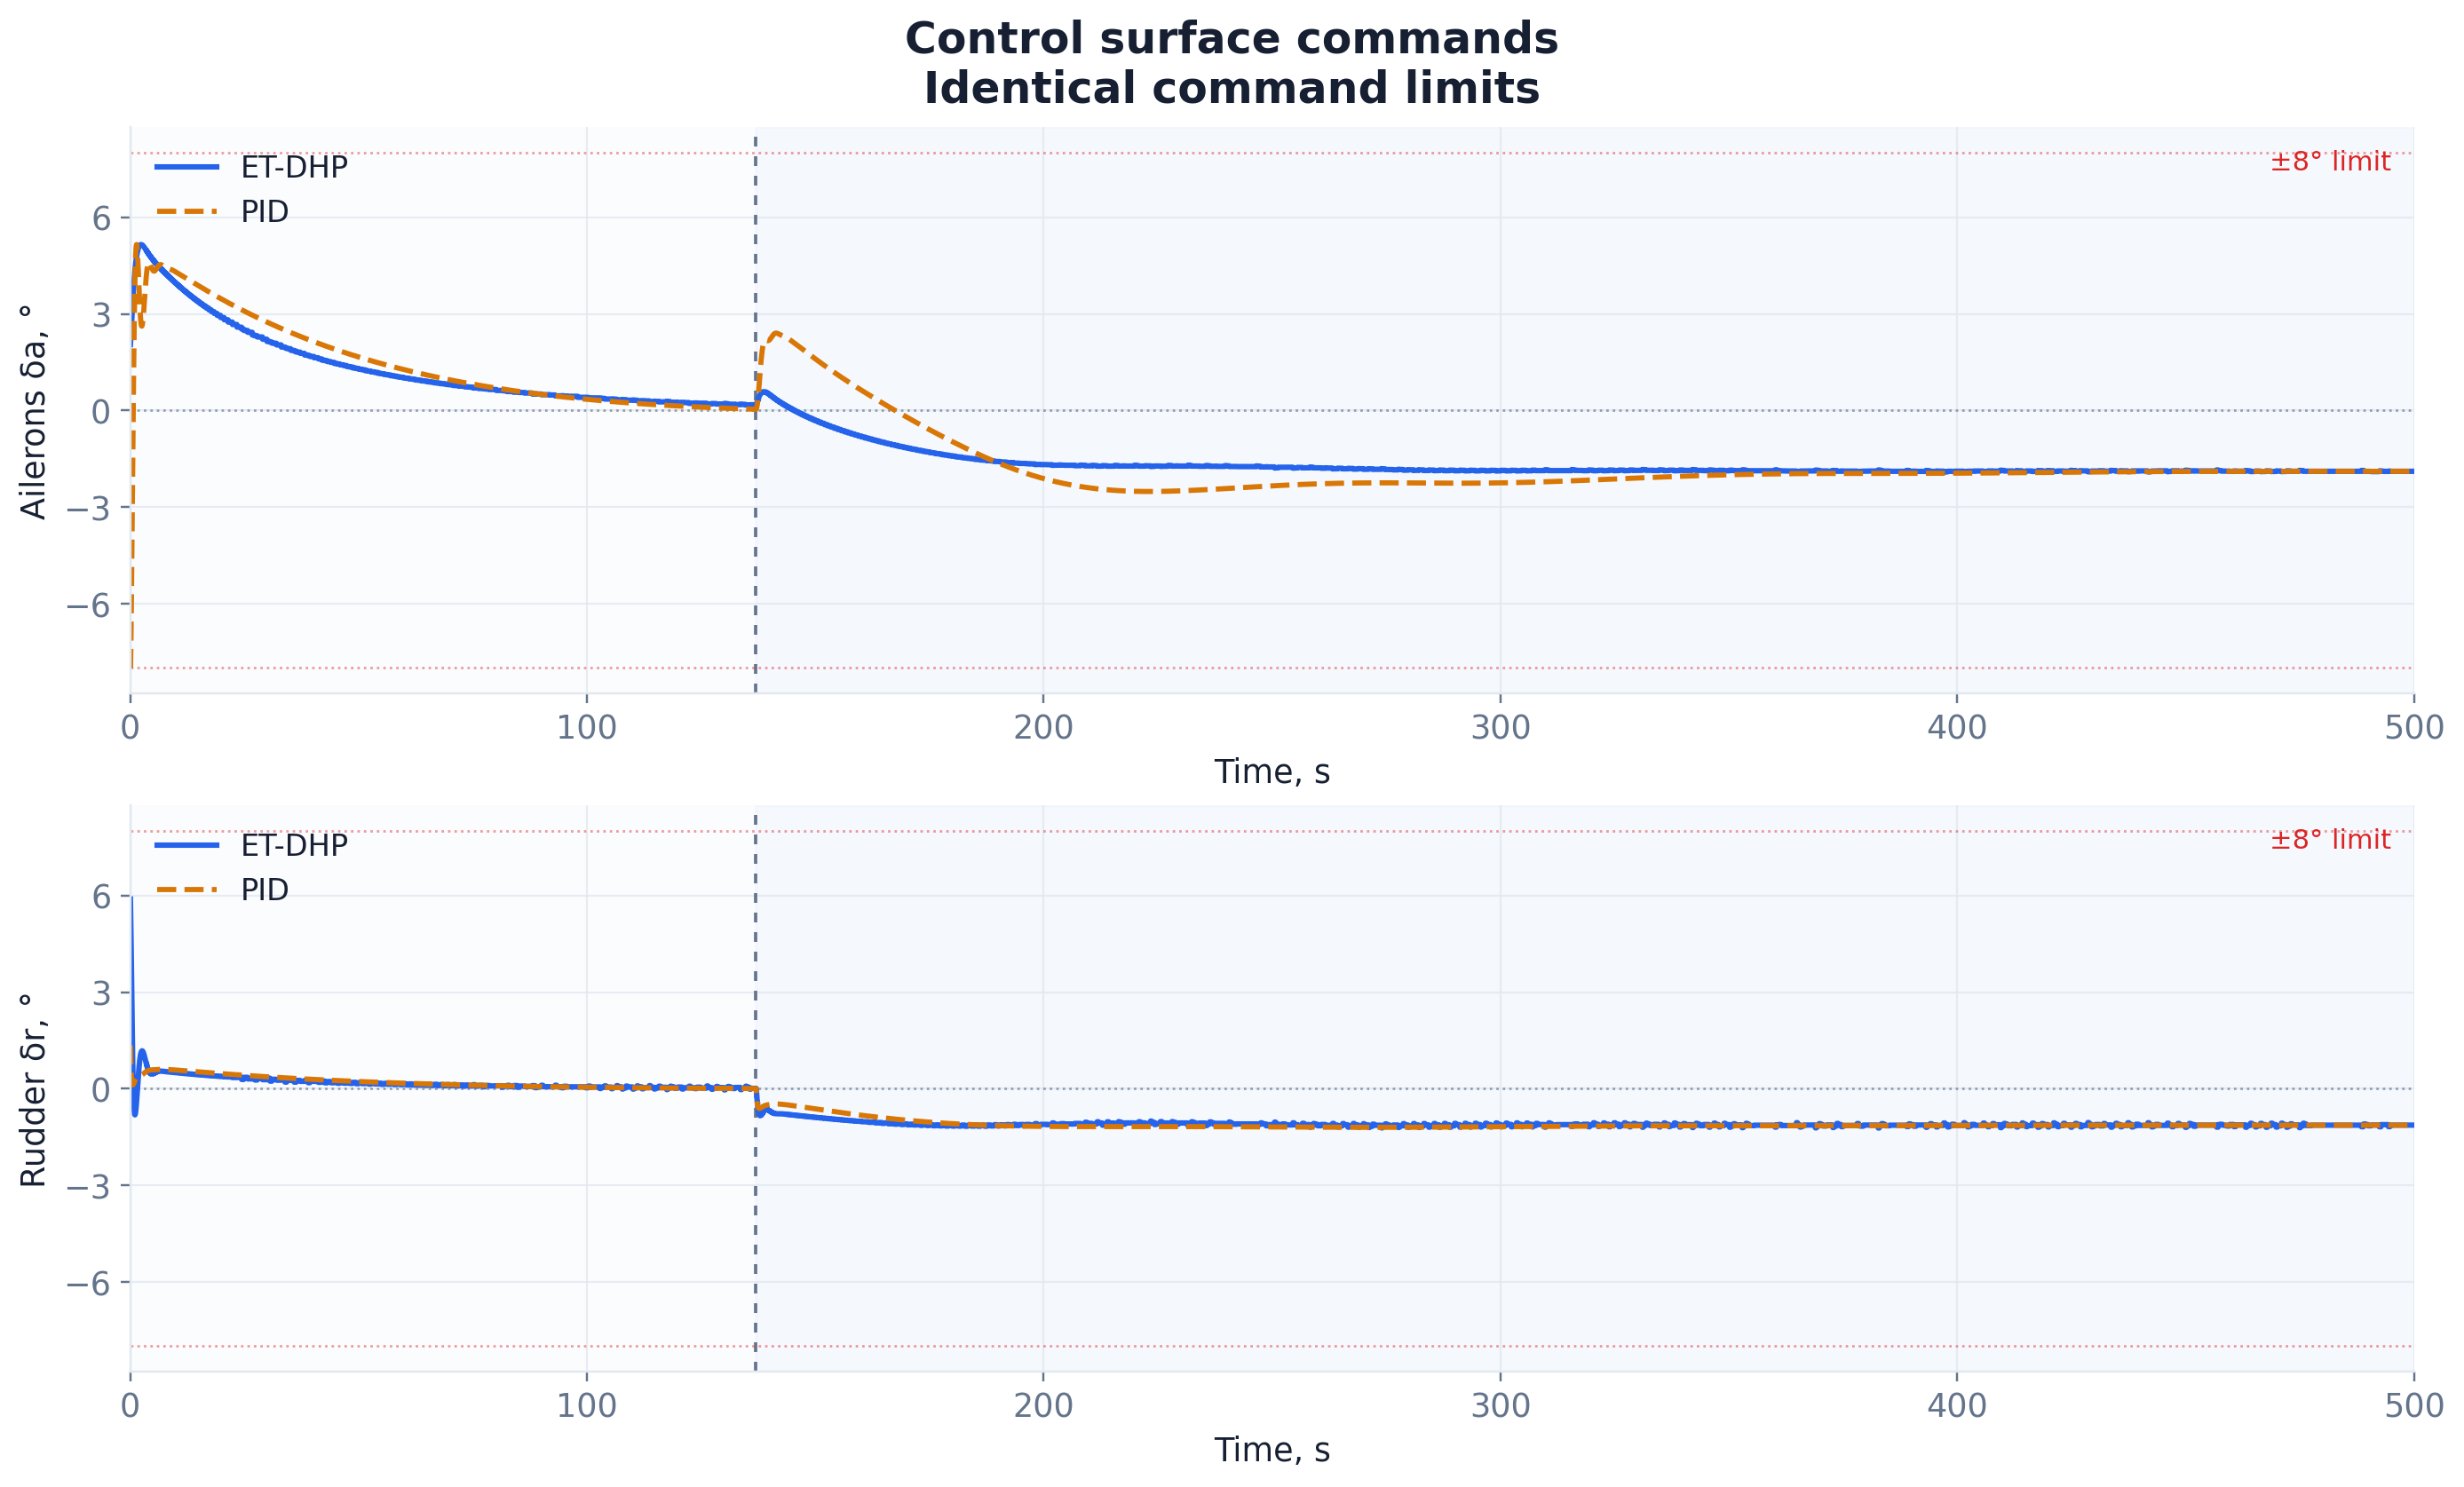

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 7.5), constrained_layout=True)
heading(fig, 'Control surface commands', 'Identical command limits')
for ax, field, label in zip(axes, ['aileron_deg', 'rudder_deg'], ['Ailerons δa, °', 'Rudder δr, °']):
    pair(ax, field)
    decorate(ax, label)
    ax.set_ylim(-8.8, 8.8)
    for limit in (-8, 8): ax.axhline(limit, color=RED, alpha=.45, lw=.9, ls=':')
    ax.text(.99, .96, '±8° limit', transform=ax.transAxes, ha='right', va='top', fontsize=10, color=RED)
show_export(fig, '05_control_commands')

## 7 · ET-DHP learning activity

The actor and critic continue event-triggered learning after failure. The latest command is held between events. The nominal model stays fixed from the beginning of the flight. Event frequency does not measure processor time relative to PID.

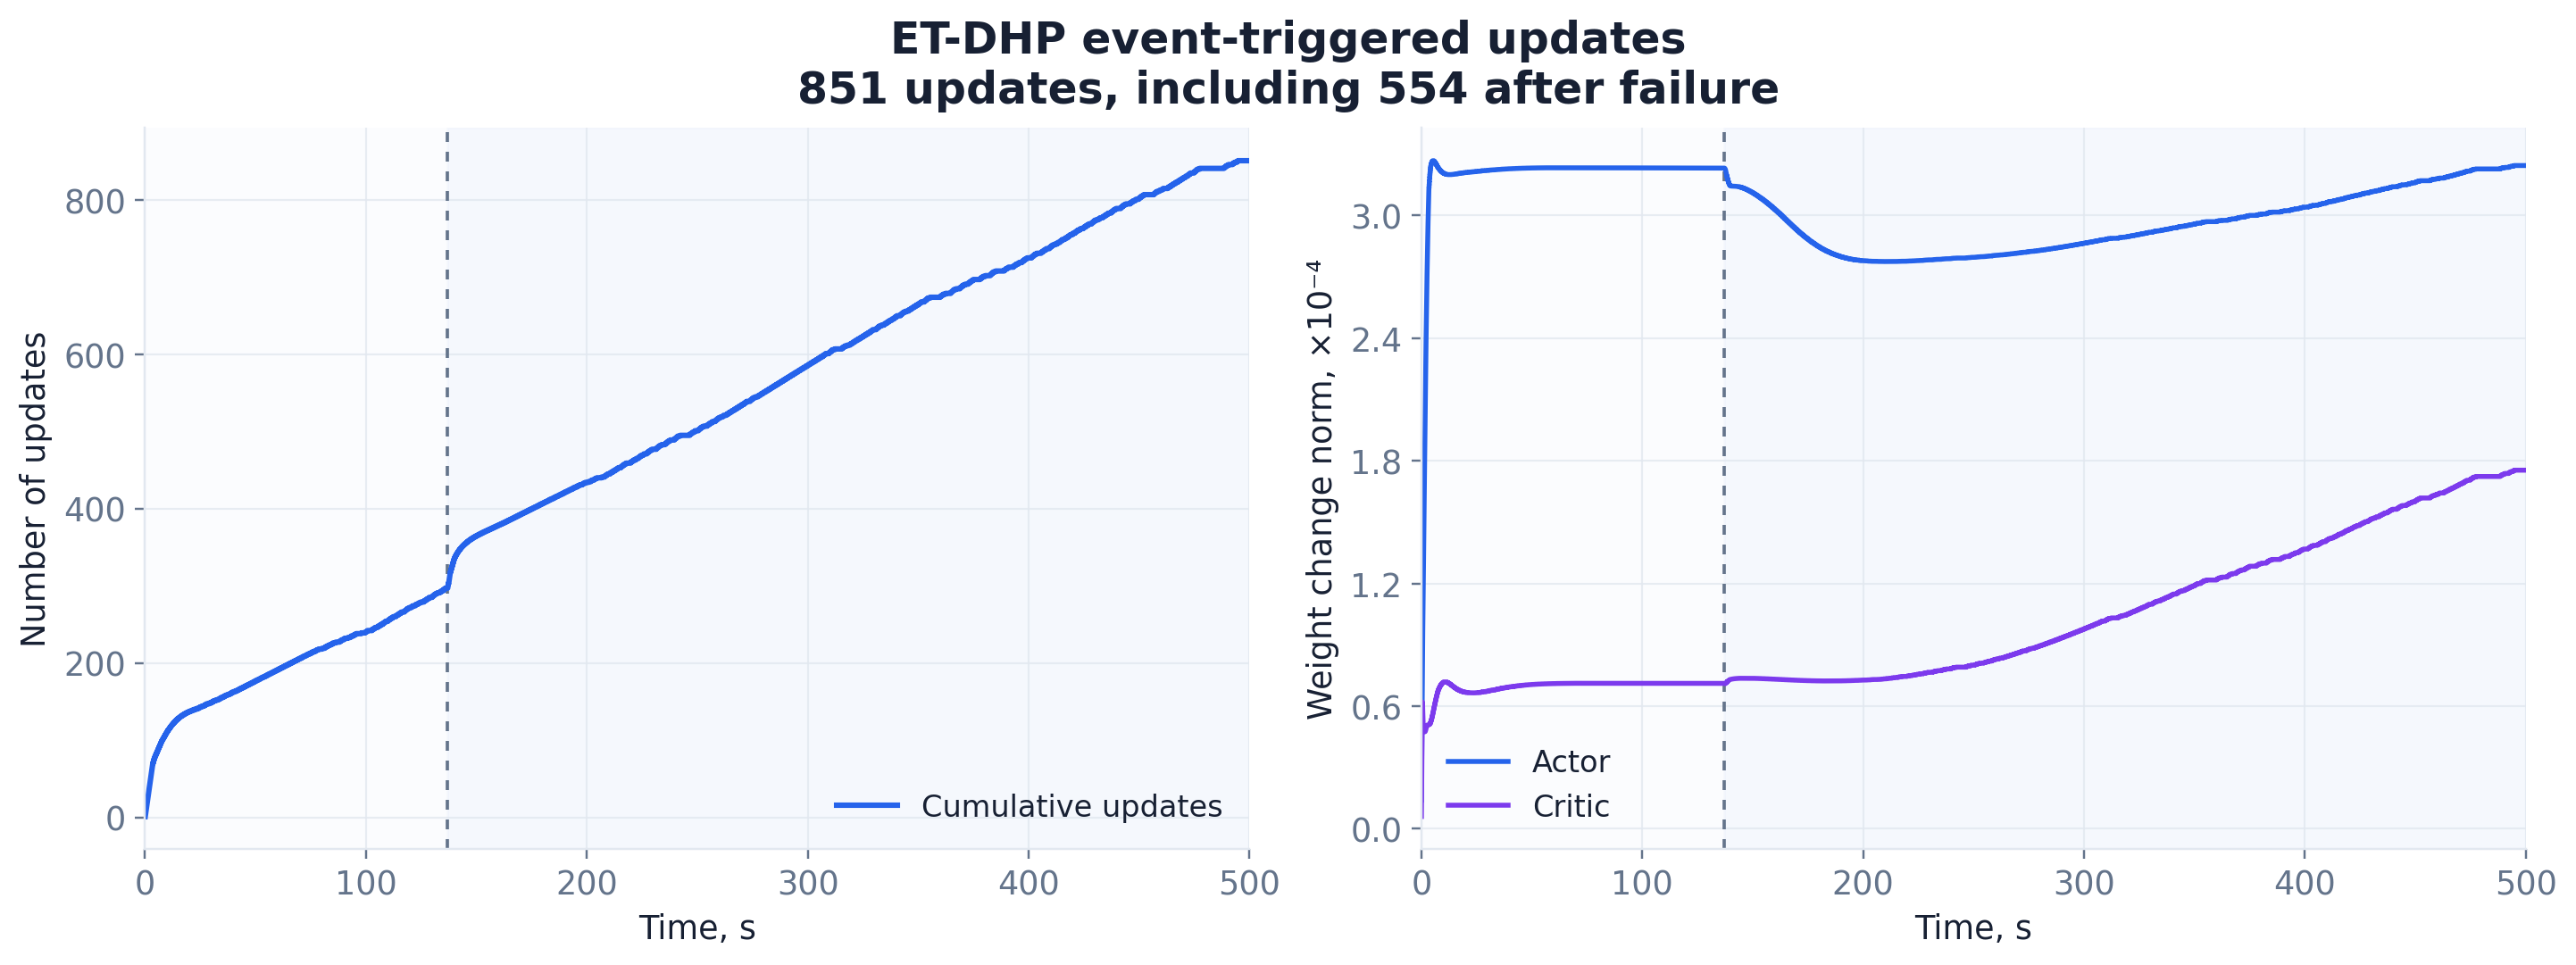

Weight changes **after failure**: actor — `0.0001050`, critic — `0.0001519`. Their contribution was not isolated from LQR initialization and integral feedback.

In [13]:
x = traces['fault_etdhp']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
run = report['runs']['fault_etdhp']
heading(fig, 'ET-DHP event-triggered updates', f"{run['triggers']} updates, including {run['triggers_after_event']} after failure")
axes[0].plot(x[:,0], np.cumsum(x[:,column['triggered']]), color=BLUE, lw=2, label='Cumulative updates')
decorate(axes[0], 'Number of updates', zero=False)
axes[1].plot(x[:,0], x[:,column['actor_change']]*1e4, color=BLUE, lw=1.8, label='Actor')
axes[1].plot(x[:,0], x[:,column['critic_change']]*1e4, color='#7C3AED', lw=1.8, label='Critic')
decorate(axes[1], 'Weight change norm, ×10⁻⁴', zero=False)
show_export(fig, '06_learning_activity')
display(Markdown(f"Weight changes **after failure**: actor — `{run['parameter_change_after_event'][0]:.7f}`, critic — `{run['parameter_change_after_event'][1]:.7f}`. Their contribution was not isolated from LQR initialization and integral feedback."))

## 8 · Separate variant with online model learning

The red curve represents a variant that trains all three networks, using separately tuned learning rates. Its performance deteriorates late in the flight, as seen in both heading and total error. This comparison does not isolate the effect of the `online_model_fit` switch alone.

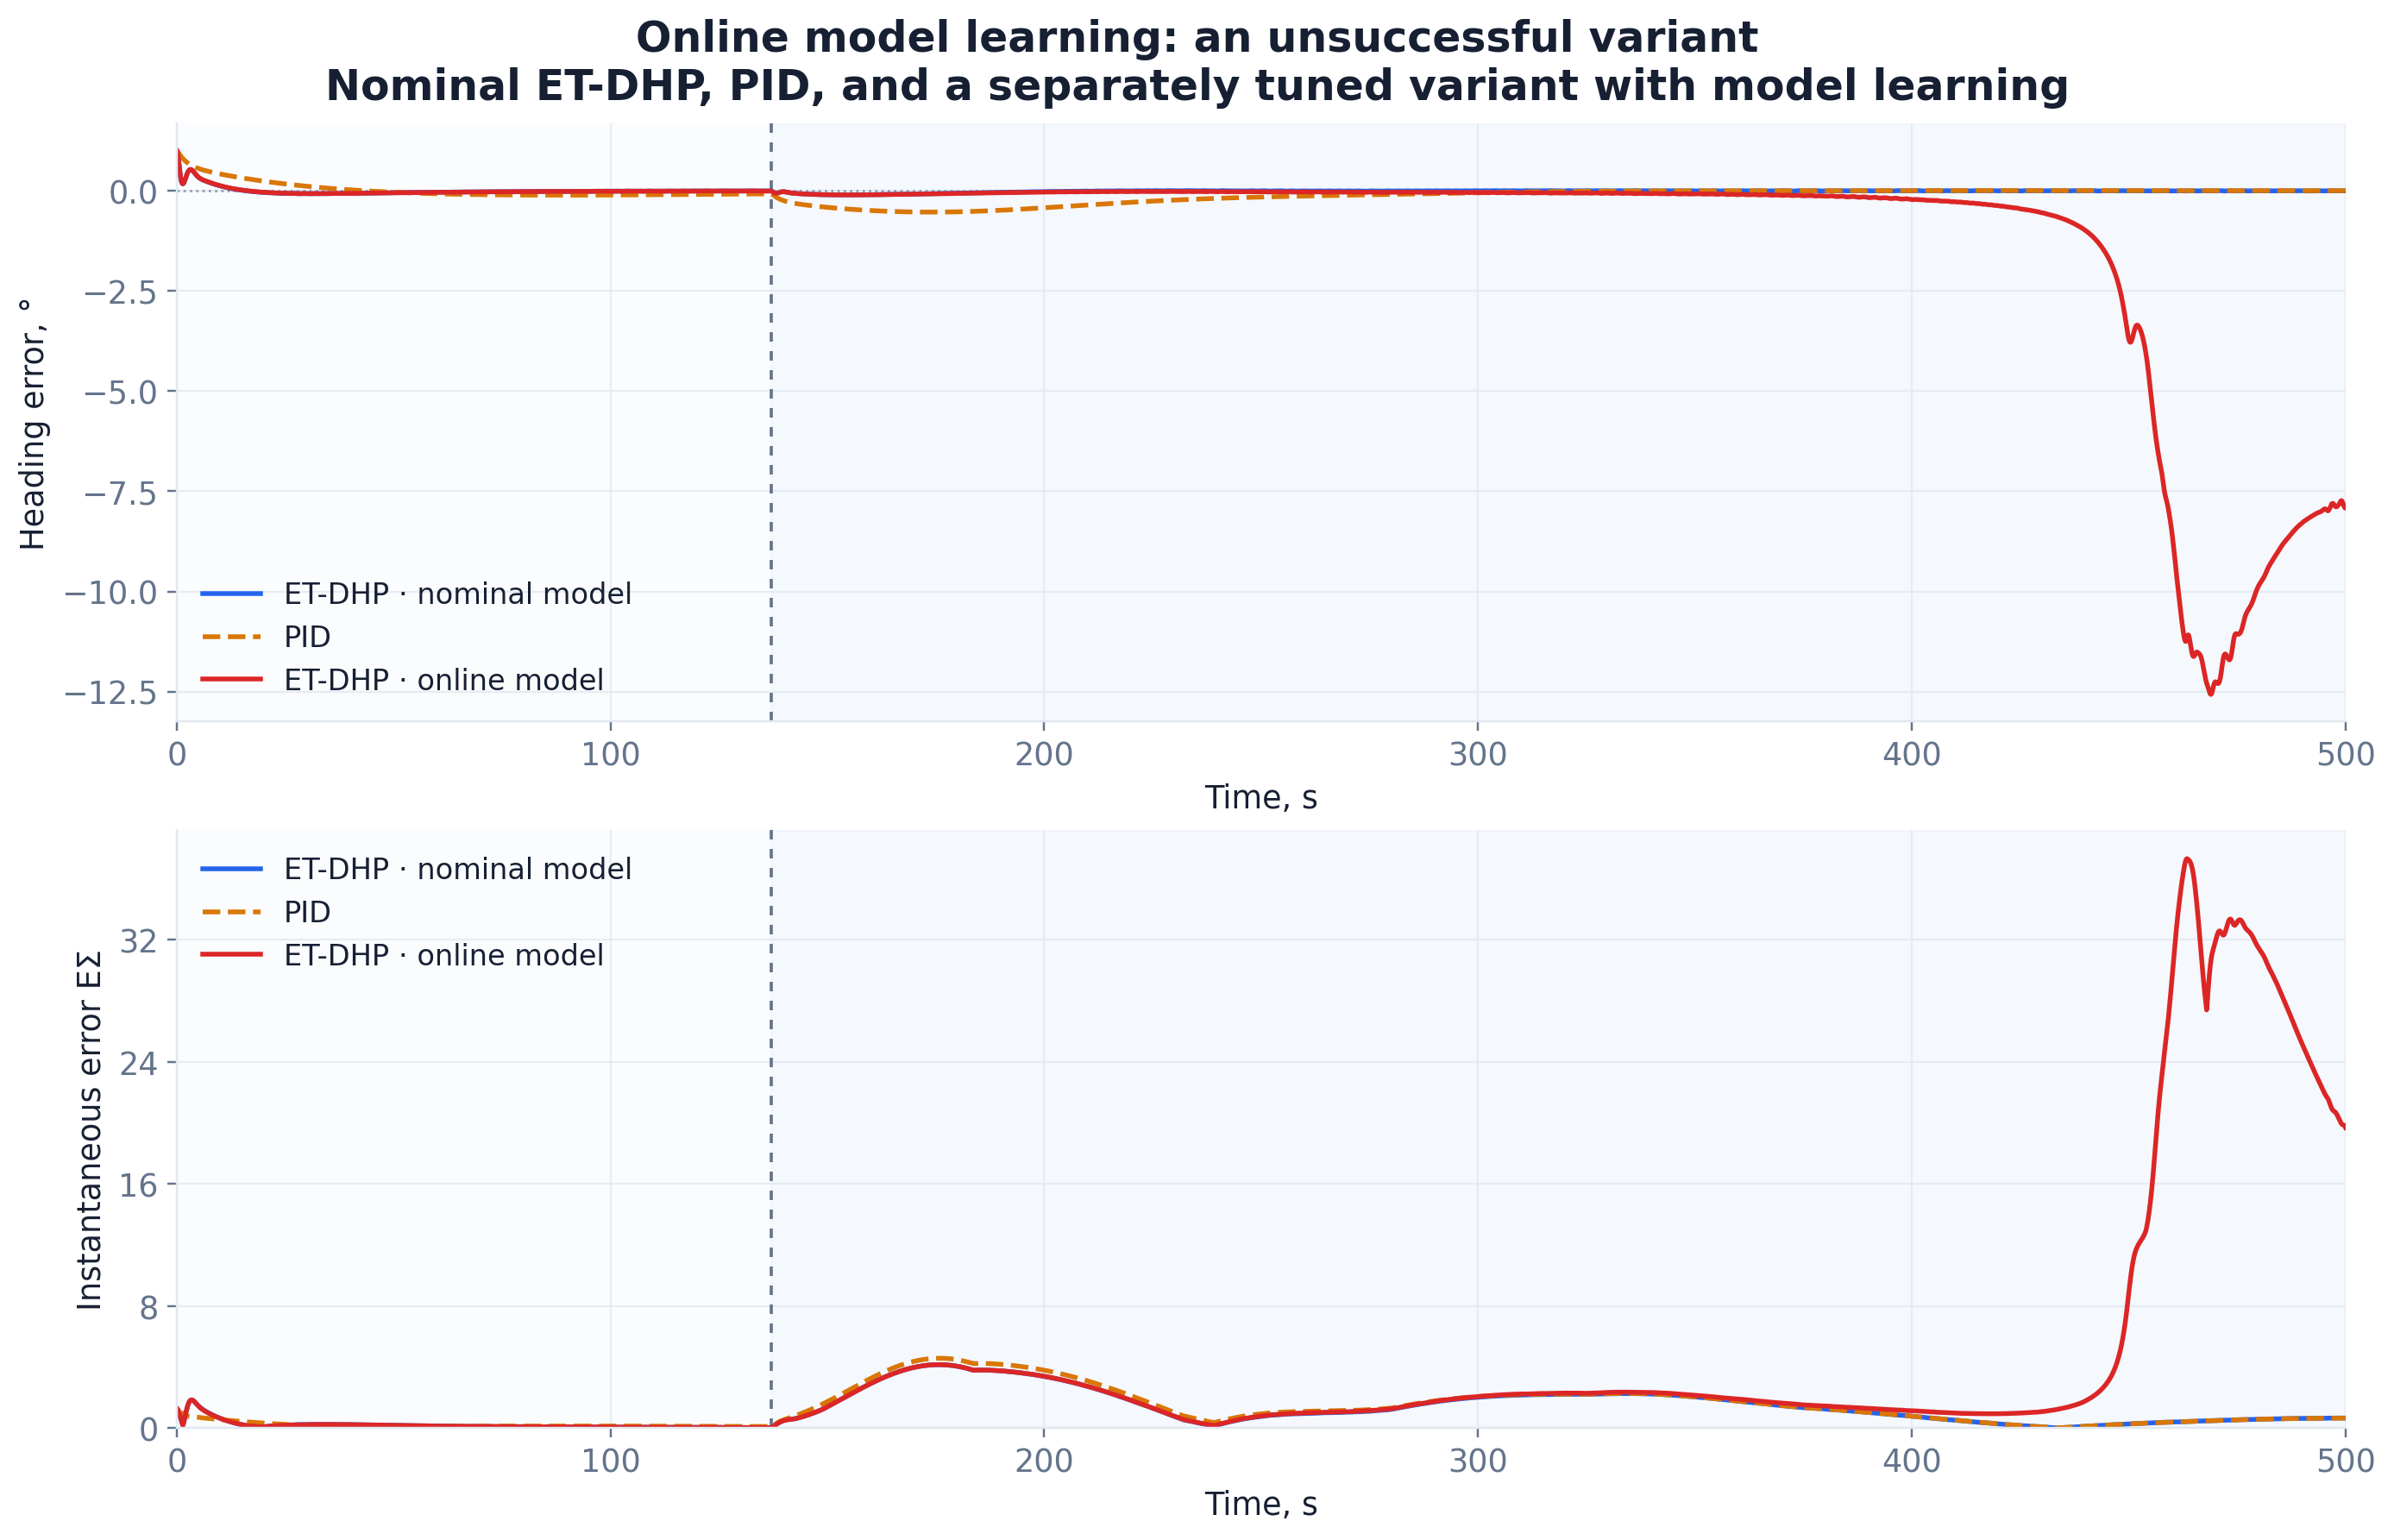

| Scenario | JΣ over 0–500 s, normalized s | JΣ over 137–500 s, normalized s | JΣ over 400–500 s, normalized s |
|:---|---:|---:|---:|
| ET-DHP · healthy aircraft | 32.014 | 3.966 | 0.717 |
| PID · healthy aircraft | 32.943 | 6.274 | 0.154 |
| ET-DHP with online model · healthy aircraft | 31.886 | 3.982 | 0.718 |
| ET-DHP · failure | 570.551 | 542.502 | 40.945 |
| PID · failure | 611.484 | 584.815 | 41.154 |
| ET-DHP with online model · failure | 1961.624 | 1933.720 | 1416.167 |

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8), constrained_layout=True)
heading(fig, 'Online model learning: an unsuccessful variant', 'Nominal ET-DHP, PID, and a separately tuned variant with model learning')
variants = [('fault_etdhp', 'ET-DHP · nominal model', BLUE, '-'),
            ('fault_pid', 'PID', ORANGE, '--'),
            ('fault_etdhp_online_model', 'ET-DHP · online model', RED, '-')]
for name, label, color, ls in variants:
    x = traces[name]
    axes[0].plot(x[:,0], x[:,column['psi_deg']], label=label, color=color, ls=ls, lw=1.8)
    axes[1].plot(x[:,0], errors[name]['total'], label=label, color=color, ls=ls, lw=1.8)
decorate(axes[0], 'Heading error, °')
decorate(axes[1], 'Instantaneous error EΣ', zero=False)
axes[1].set_ylim(bottom=0)
show_export(fig, '07_online_model_total_error')

names = {'healthy_etdhp': 'ET-DHP · healthy aircraft', 'healthy_pid': 'PID · healthy aircraft',
         'healthy_etdhp_online_model': 'ET-DHP with online model · healthy aircraft',
         'fault_etdhp': 'ET-DHP · failure', 'fault_pid': 'PID · failure',
         'fault_etdhp_online_model': 'ET-DHP with online model · failure'}
rows = [f'| Scenario | JΣ over 0–{duration:g} s, normalized s | JΣ over {fault_time:g}–{duration:g} s, normalized s | JΣ over {max(fault_time,duration-100):g}–{duration:g} s, normalized s |', '|:---|---:|---:|---:|']
for key, label in names.items():
    values = [total_error_metrics[key][window]['integral'] for window in ('Full flight', 'After failure', 'Last 100 s')]
    rows.append(f'| {label} | {values[0]:.3f} | {values[1]:.3f} | {values[2]:.3f} |')
display(Markdown('\n'.join(rows)))

## Conclusions and reproduction

- The overall metric includes **all four independent references**. Heading-only percentages cannot be applied to total error.
- The overall result depends on `ERROR_SCALES`; they are explicit, shared across variants, and editable.
- ET-DHP uses nominal LQR initialization. The contribution of adaptation was not isolated from initialization and integral feedback.
- PID was fitted on the healthy aircraft; optimization stopped at its computational budget, with no claim of a global optimum.
- The nonlinear 6-DoF model uses local aerodynamic derivatives. Actuator/engine dynamics, wind, and measurement noise are absent. A 500 s simulation does not prove infinite-horizon stability.

To rerun the simulation, change `cfg` and set `RERUN_SIMULATION = True`. To change only the total-error weights, edit `ERROR_SCALES` and rerun subsequent cells. A cache that does not match `cfg` is not reused.

Original protocol: `reports/etdhp-b747-pid-validation.md`. ET-DHP equations were compared with [Sun et al., CEAS EuroGNC 2022](https://eurognc.ceas.org/archive/EuroGNC2022/pdf/CEAS-GNC-2022-075.pdf).

Figures are exported to PNG/SVG and a combined PDF. The total-error definition, scales, and numeric results are saved as JSON; time series are saved as CSV.

# Step response: transient performance

**16 tests:** four separate reference steps × two algorithms × healthy/faulty aircraft. Each test changes one reference while keeping the others fixed.

| Channel | Initial → final reference | Amplitude |
|---|---:|---:|
| Heading | 0 → 1° | +1° |
| Roll | 0 → 0.5° | +0.5° |
| Speed | 205.4352 → 206.4352 m/s | +1 m/s |
| Altitude | 6096 → 6106 m | +10 m |

Each test follows a 1000 s warm-up flight with the original references. In the faulty case, engine 1 loses 50% thrust at 137 s of that warm-up. The complete aircraft, integrator, and learning-network states are then cloned into independent tests. Counters, weights, and integrators **are not reset**. The step occurs at local time 20 s (1020 s from flight start), followed by **500 s** of observation. Four additional continuations without steps check baseline drift and exact trajectory agreement before the command.

Settings come from the previous comparison without retuning for these steps. ET-DHP retains event-triggered updates and command holding: the new reference can affect the held command after the next `learn`, one 0.05 s control step later. The algorithm does not receive the failure schedule.

**Scope.** ET-DHP/PID differ in the lateral controller; speed and altitude use the same longitudinal controller. A roll step with unchanged heading tests coupled channels and may produce sideslip; it is not a coordinated-turn command. ET-DHP inputs here are heading/roll errors, angular rates, sideslip, and error integrals. This tests reference tracking by this controller, without proving the original paper's stability theorem for this setup.

In [15]:
from example.reinforcement_learning.incremental_adp import example_etdhp_step_response_b747 as step_demo
step_protocol = step_demo.Protocol()
step_dir = data_dir / 'step_response'
RERUN_STEPS = False  # True: rerun 4 warm-up flights and 20 continuations.
step_report_path = step_dir / 'metrics.json'
step_report = json.loads(step_report_path.read_text()) if step_report_path.exists() else None
step_cache_ok = (step_report is not None
                 and step_report['protocol'] == asdict(step_protocol)
                 and step_report['source_digest'] == step_demo.source_digest()
                 and len(step_report['runs']) == 20
                 and all((step_dir/f'{key}.csv').exists() for key in step_report['runs']))
if RERUN_STEPS or not step_cache_ok:
    step_report = step_demo.run_suite(step_dir, step_protocol)
step_traces = {key: np.loadtxt(step_dir/f'{key}.csv', delimiter=',', skiprows=1)
               for key in step_report['runs']}
assert all(run['status'] == 'complete' for run in step_report['runs'].values())
assert all(np.isfinite(x).all() for x in step_traces.values())
step_labels = ['Heading', 'Roll', 'Speed', 'Altitude']
step_units = ['°', '°', 'm/s', 'm']
step_conditions = [('healthy', 'Healthy aircraft'), ('fault', 'After thrust loss')]
step_start = step_protocol.step_time_s
step_end = step_protocol.trial_s

def step_value(value, digits=2):
    return 'not confirmed' if value is None else f'{value:.{digits}f}'

print(f'Completed: 16 step tests + 4 baseline runs; dt = {step_protocol.dt:g} s.')
print('Duration after each step:', step_protocol.response_s, 's.')

Completed: 16 step tests + 4 baseline runs; dt = 0.05 s.
Duration after each step: 500.0 s.


## Metric definitions

Let $r_0$ and $r_1$ be the initial and final **commanded** values, $\Delta r=r_1-r_0$, and $e=y-r_1$. All times are measured from the step command.

- **Rise time ($t_{10–90}$):** time between the first crossings of 10% and 90% of the commanded increment; crossings are interpolated linearly between samples.
- **Settling time ($t_s$):** the first sample after the last excursion outside $|e|\leq 0.02|\Delta r|$ or $0.05|\Delta r|$. At least 30 s must remain in-band until the end of observation. “Not confirmed” means this condition was not met within 500 s.
- **Overshoot:** maximum exceedance of the reference in the step direction, as a percentage of step amplitude. Undershoot and peak time are also saved.
- **Steady-state error estimate:** mean $y-r_1$ over the last 50 s. Without settling, this is only residual error over the observed horizon; variability and drift are shown alongside it.
- **RMSE, IAE, ISE, ITAE:** root mean square error and the integrals $\int |e|\,dt$, $\int e^2\,dt$, and $\int t|e|\,dt$ over 500 s after the command. Integration uses the trapezoidal rule and includes the step boundary.

The 10–90% thresholds and 2%/5% bands follow the conventions in the [`stepinfo` documentation](https://www.mathworks.com/help/control/ref/dynamicsystem.stepinfo.html). The final value is explicitly the commanded reference, not the last measured sample. For example, a 10 m altitude step has a 2% band of **±0.2 m**.

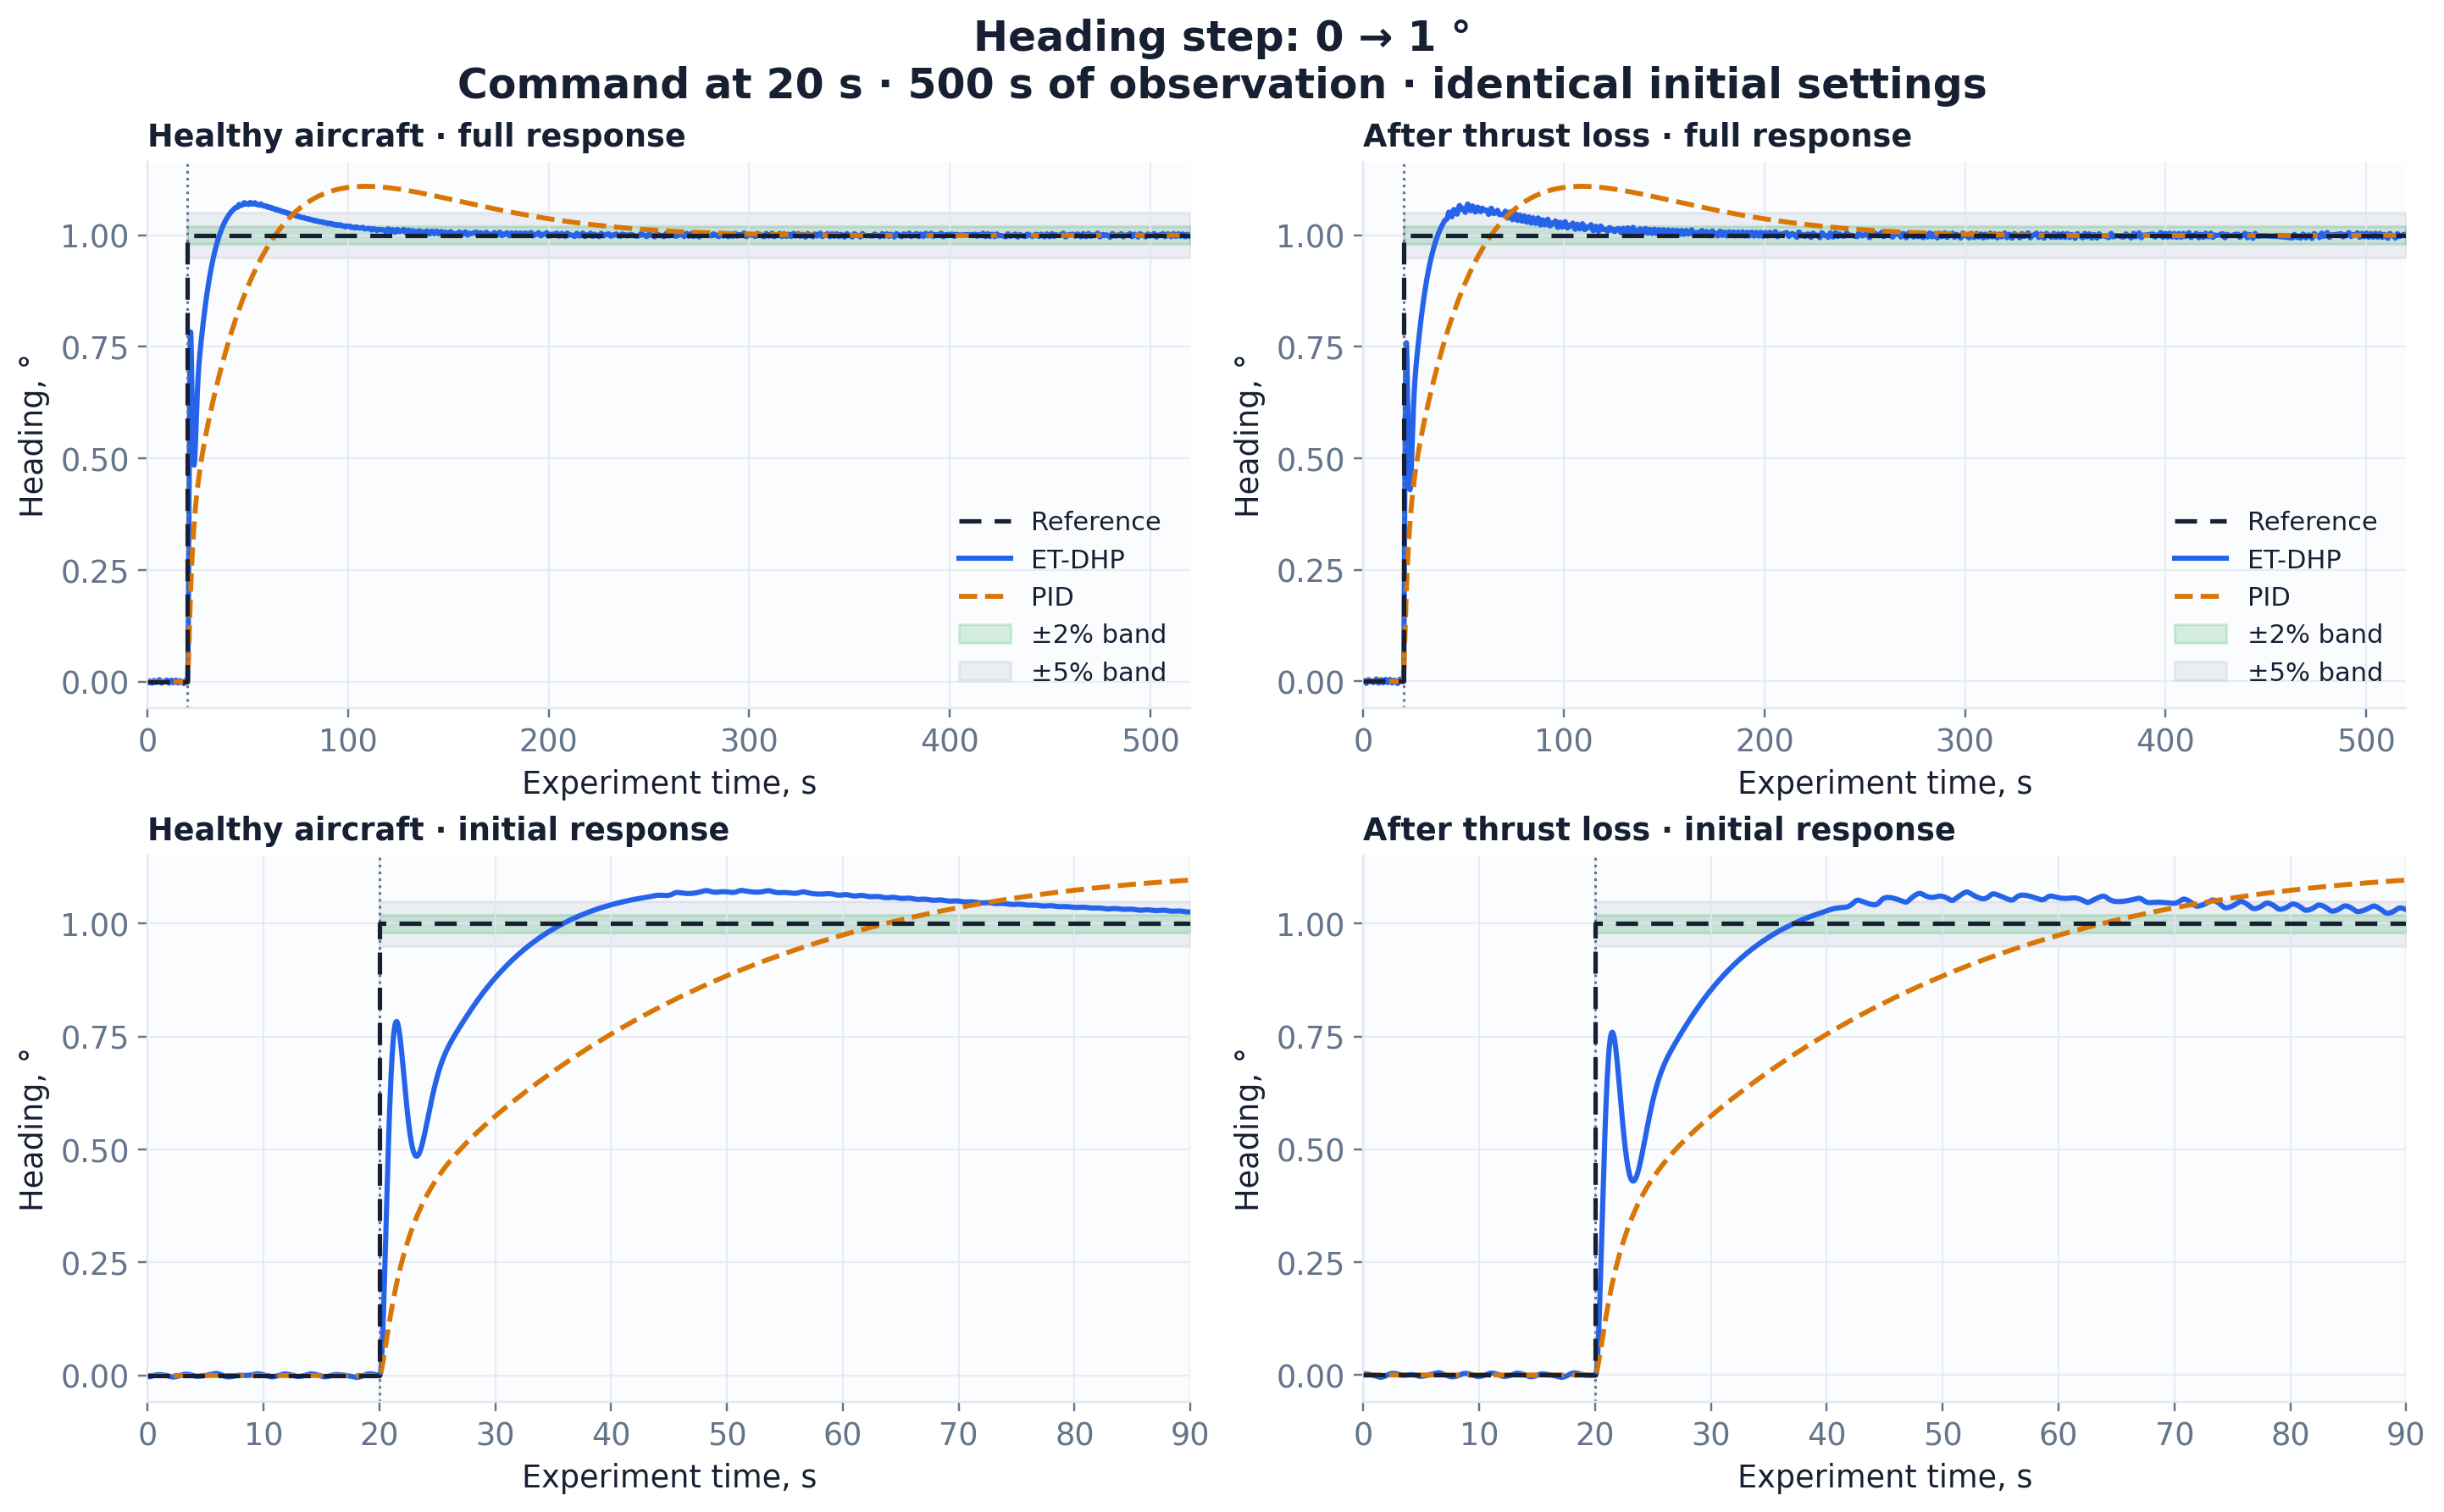

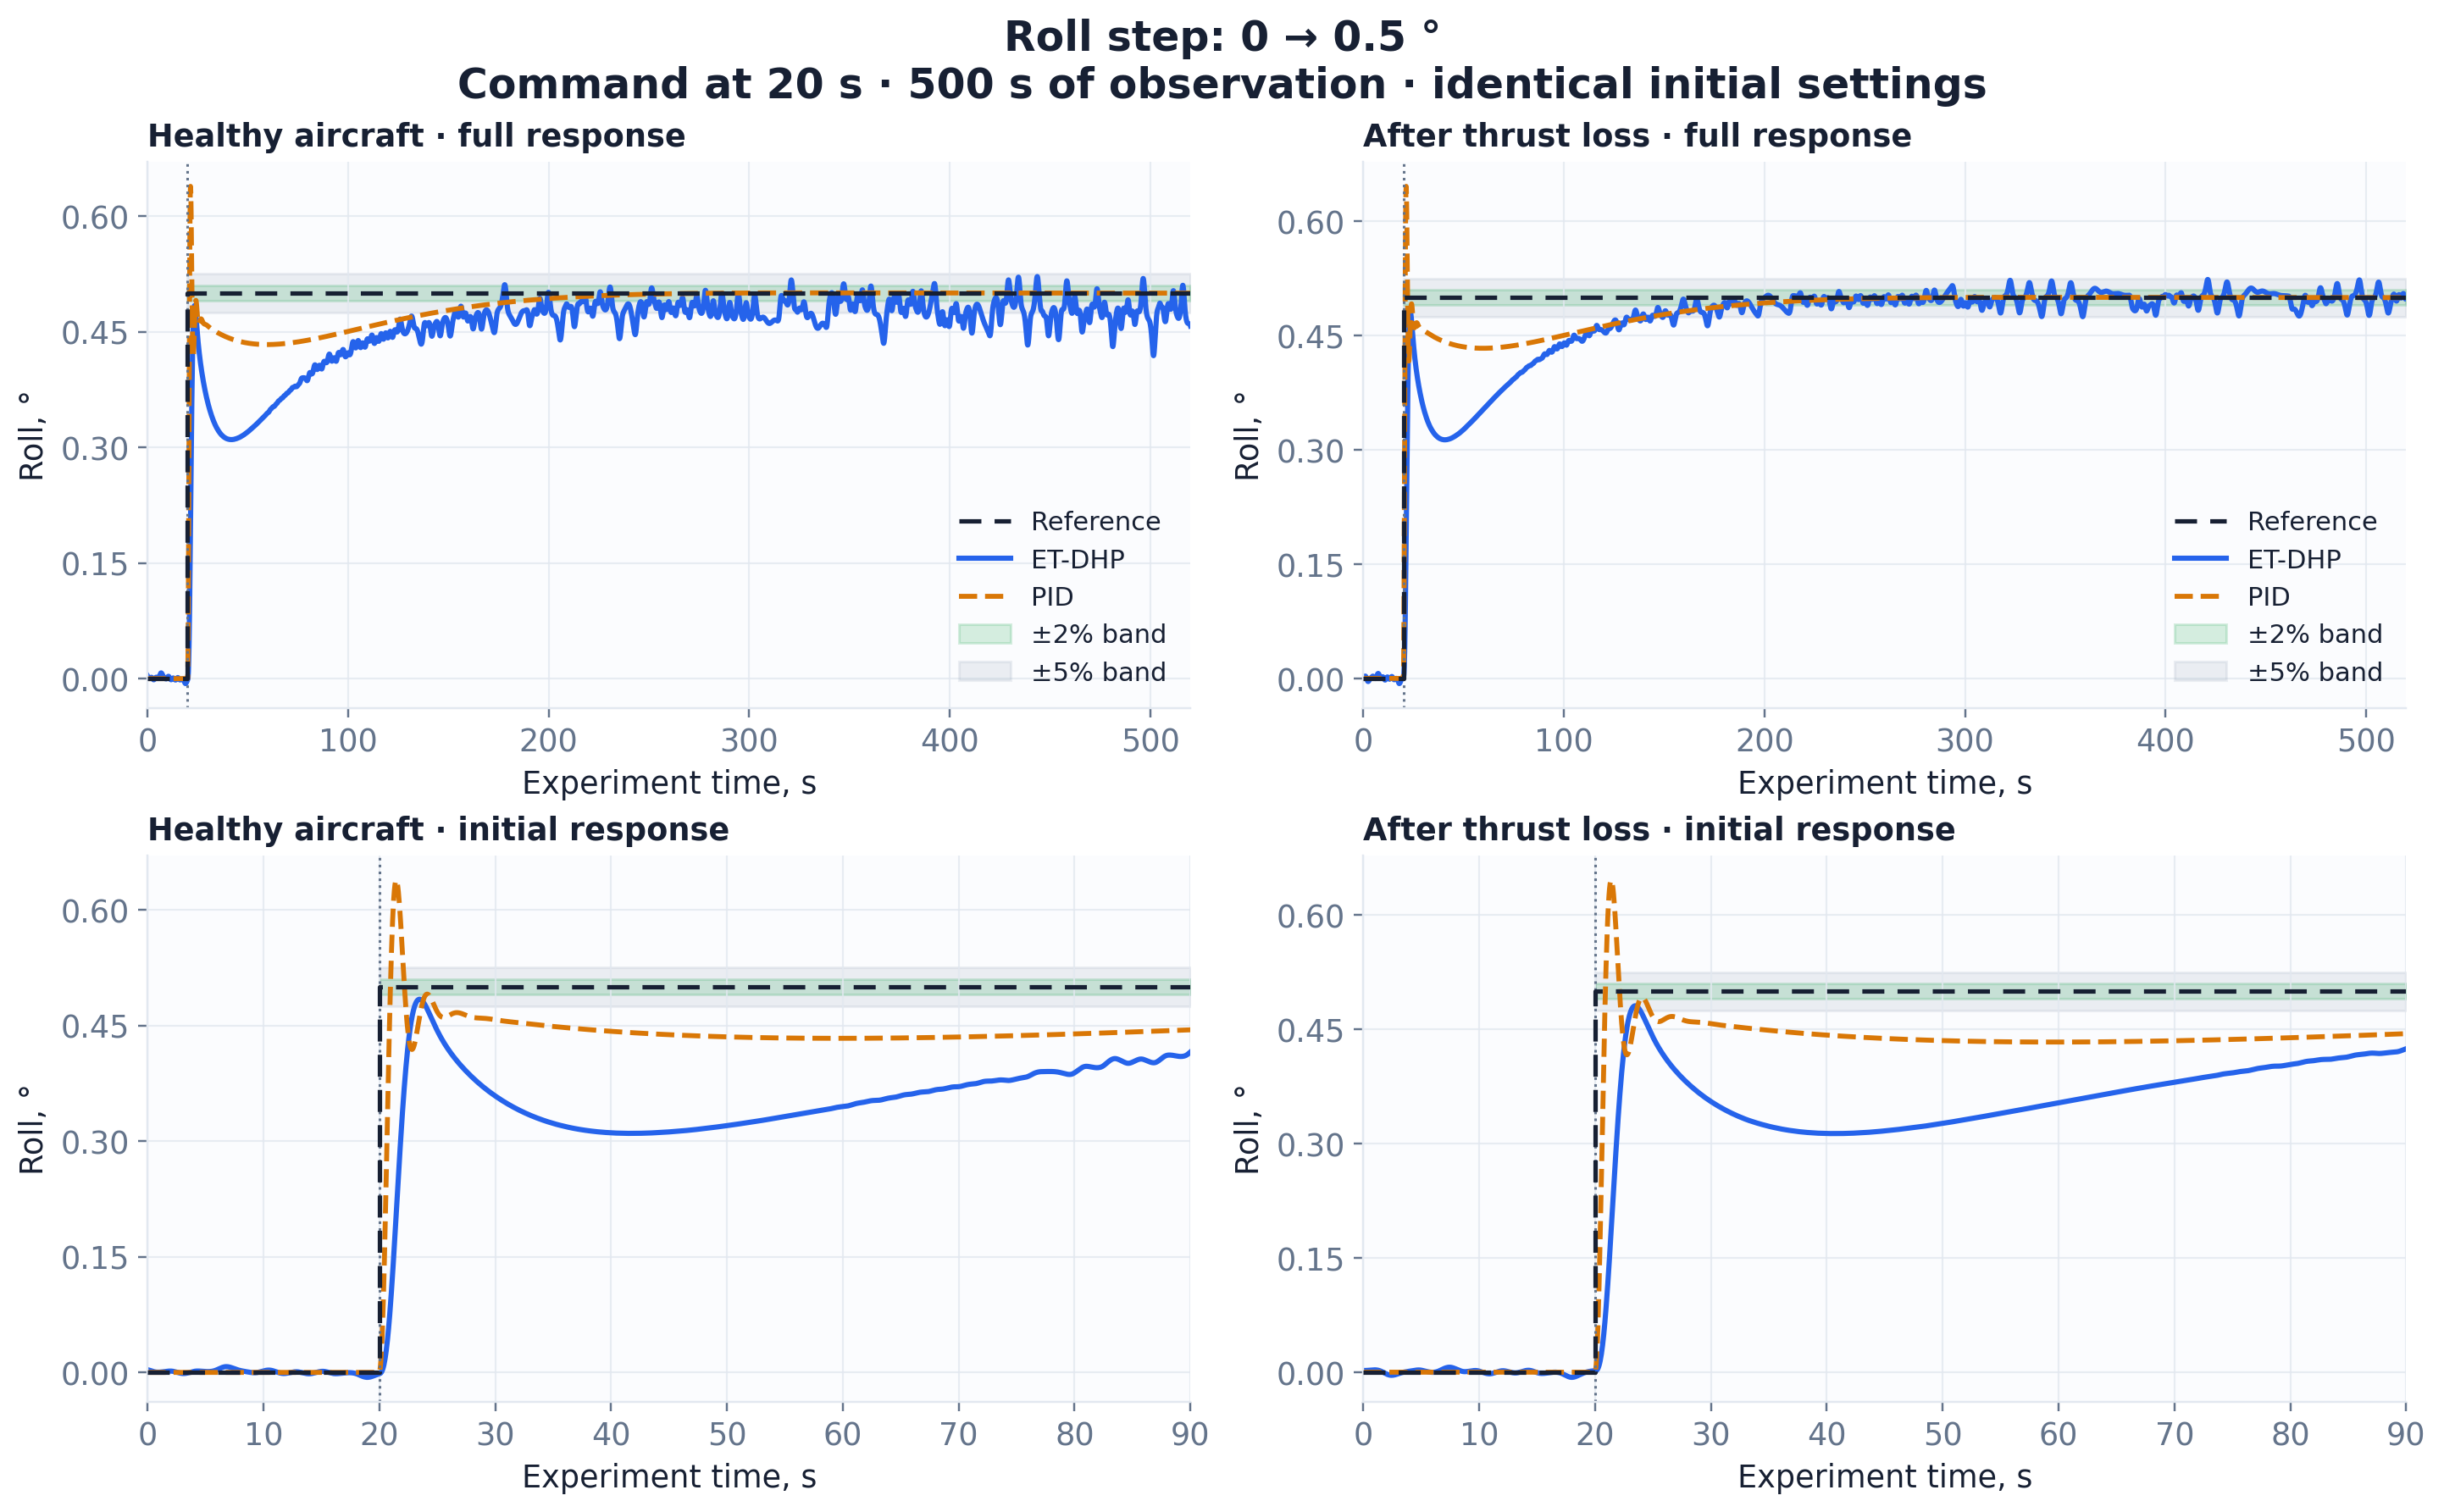

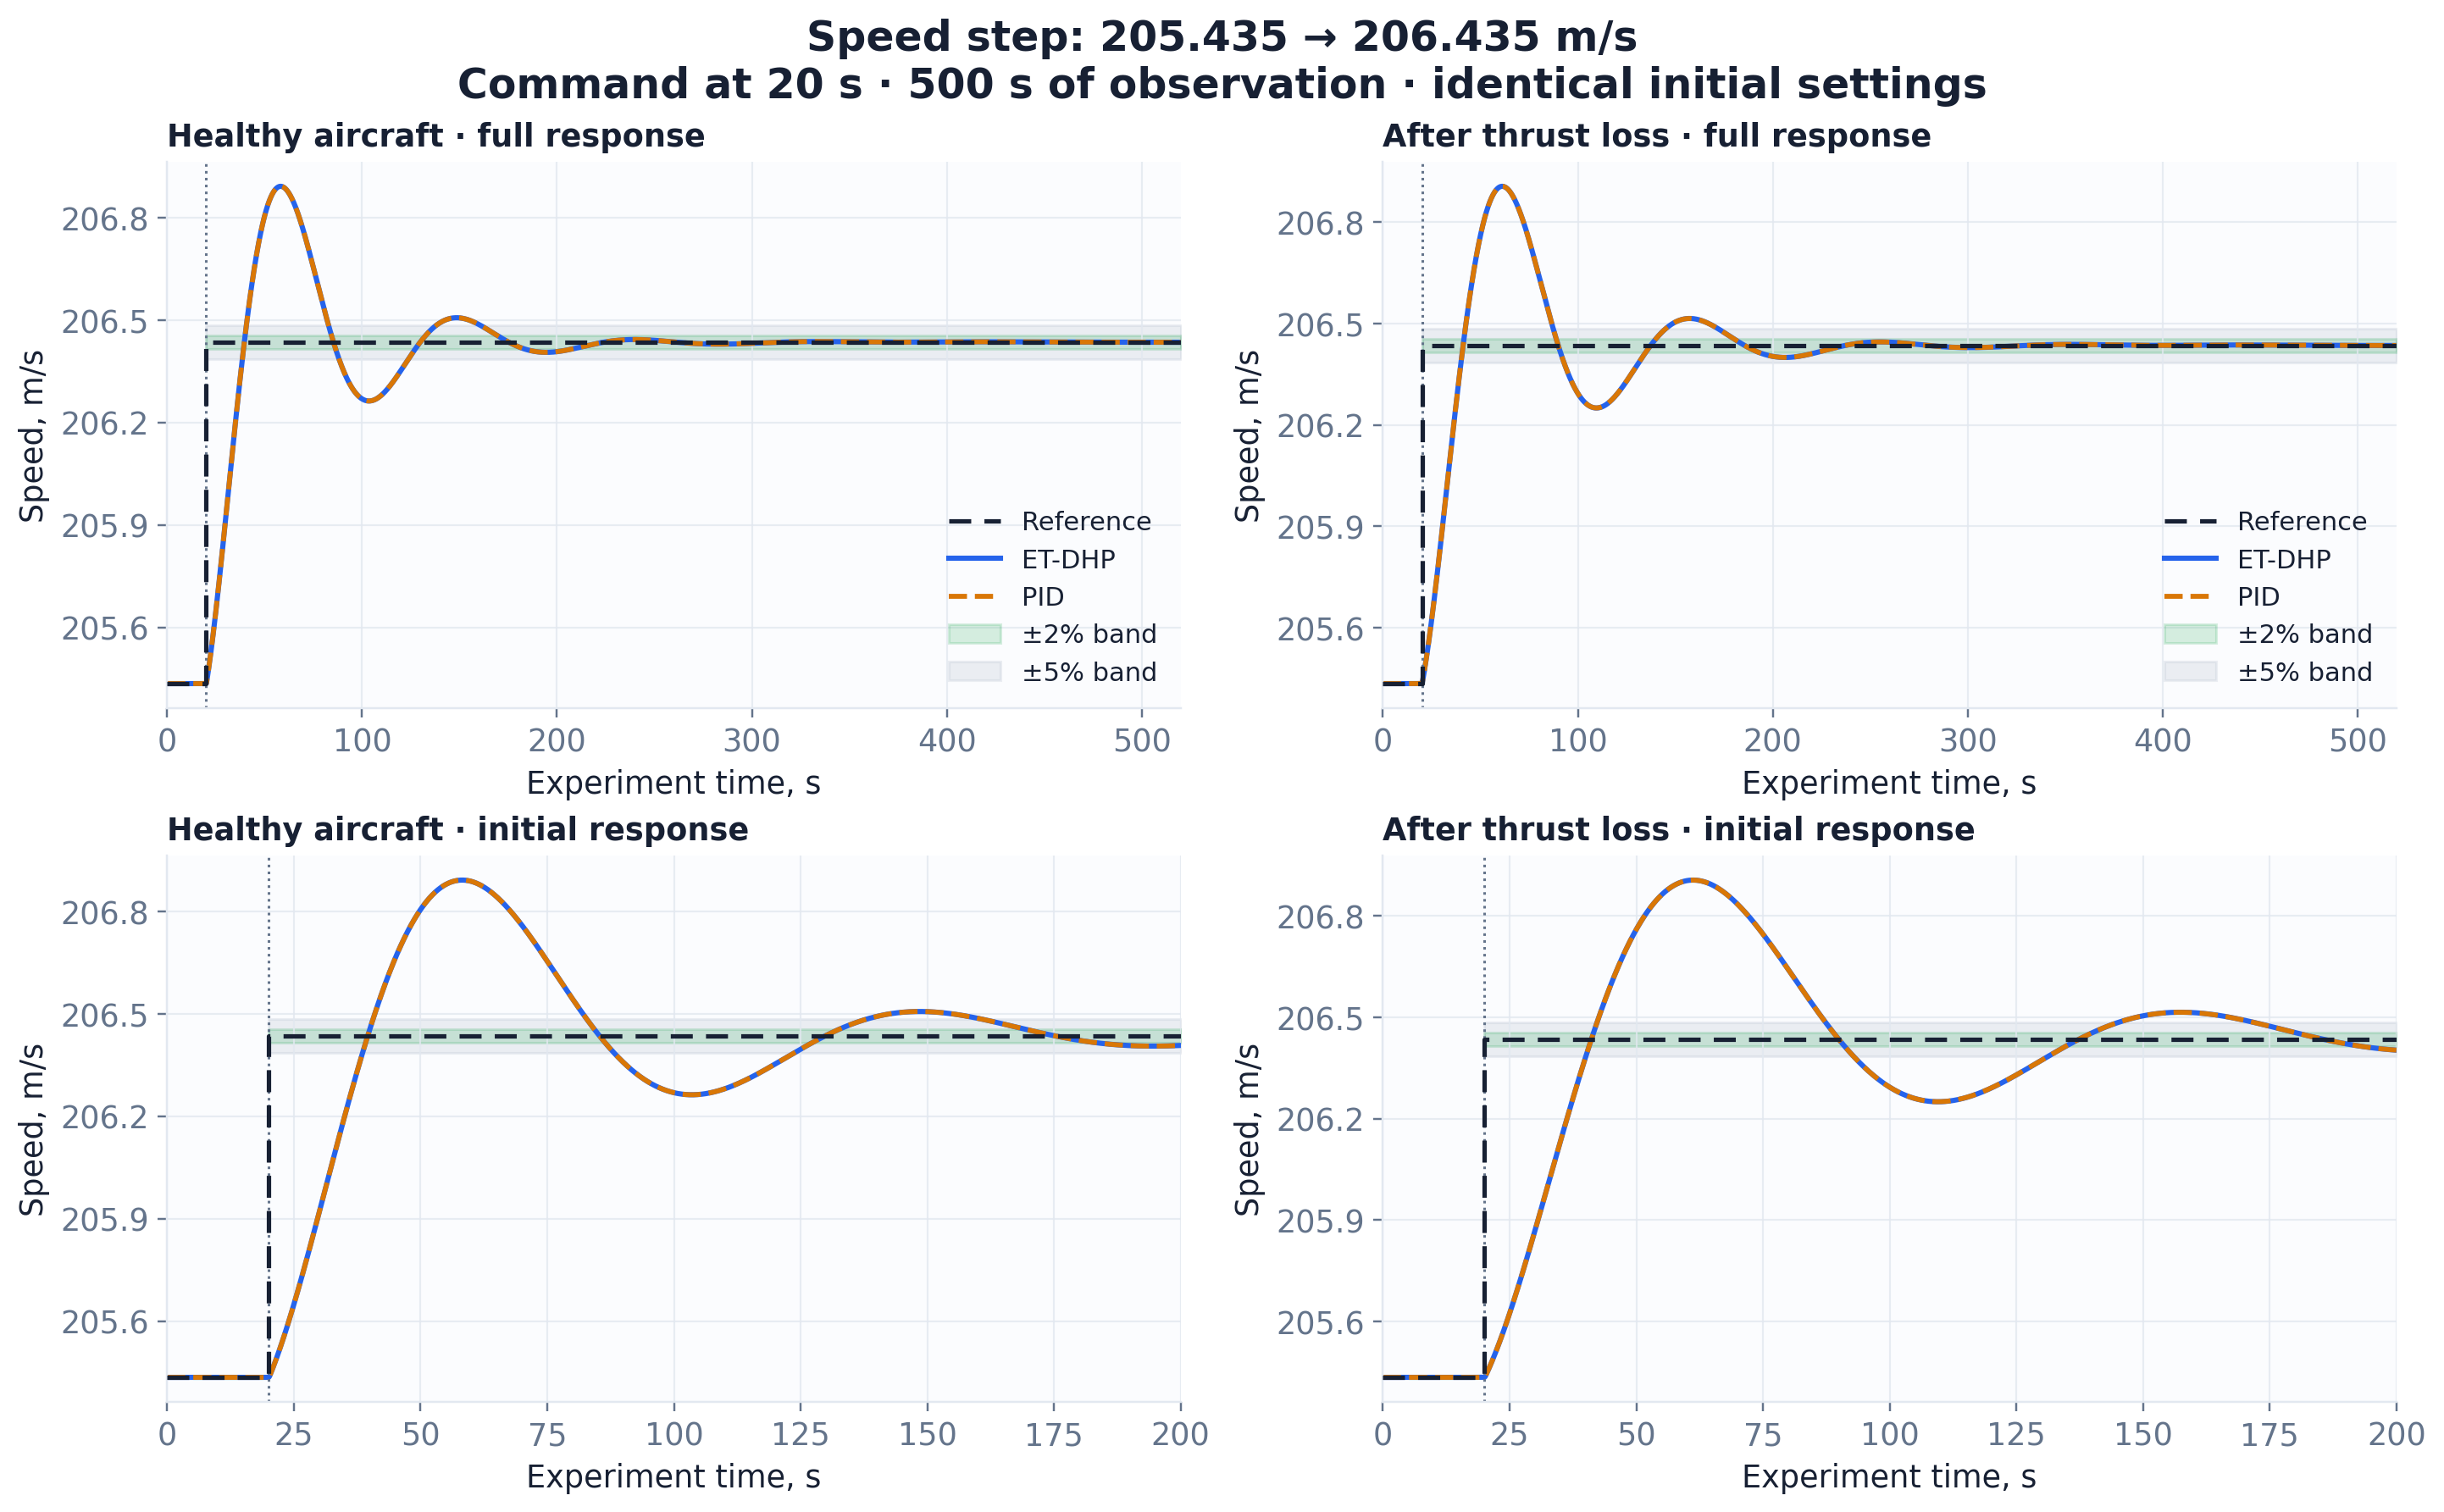

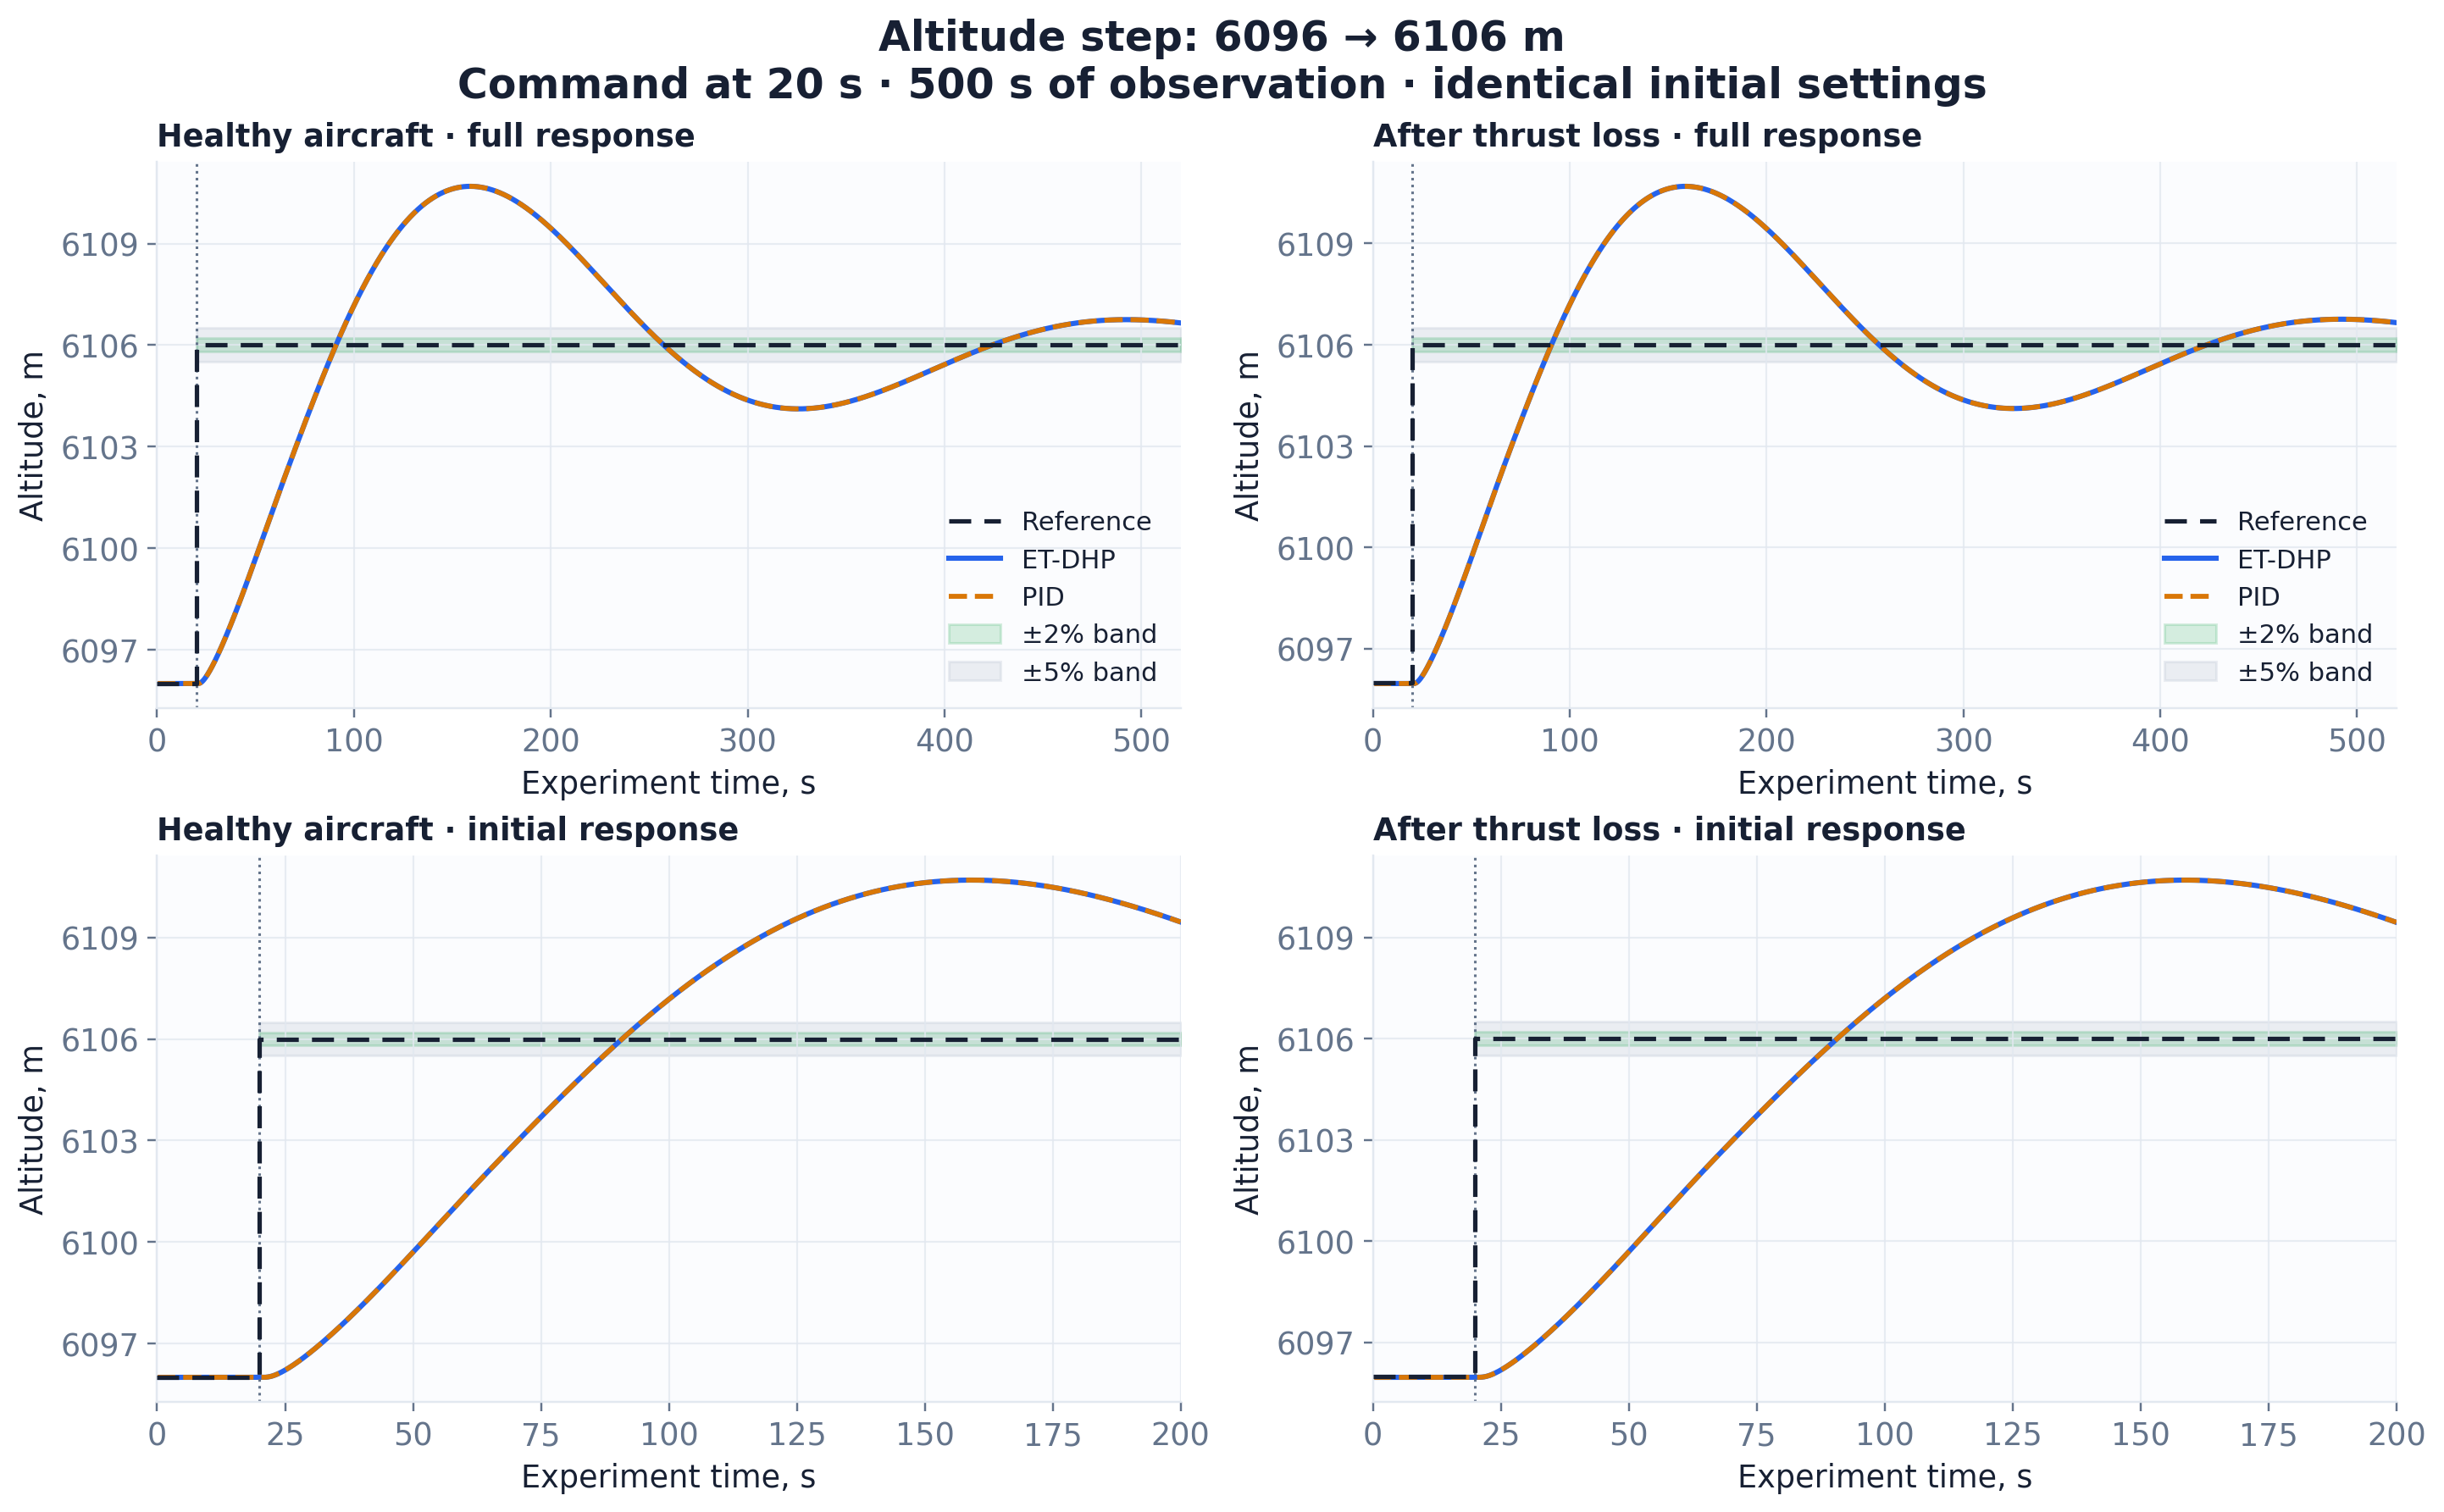

In [16]:
# Full window and a close-up of the initial response for each channel.
for channel, (label, unit) in enumerate(zip(step_labels, step_units)):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout='constrained')
    target0 = step_demo.NOMINAL_REFERENCE[channel]
    amplitude = step_demo.STEP_AMPLITUDES[channel]
    target1 = target0 + amplitude
    zoom_end = 90 if channel < 2 else 200
    for j, (condition, condition_label) in enumerate(step_conditions):
        for row, stop in enumerate((step_end, zoom_end)):
            ax = axes[row, j]
            ax.fill_between([step_start, stop], target1-.05*abs(amplitude), target1+.05*abs(amplitude),
                            color='#94A3B8', alpha=.16, label='±5% band')
            ax.fill_between([step_start, stop], target1-.02*abs(amplitude), target1+.02*abs(amplitude),
                            color='#16A34A', alpha=.17, label='±2% band')
            for algo in ('etdhp', 'pid'):
                key = f'{condition}_{algo}_{step_demo.CHANNELS[channel]}'
                x = step_traces[key]
                mask = x[:, 0] <= stop
                ax.plot(x[mask, 0], x[mask, 2+channel], **STYLES[algo])
            ax.step([0, step_start, stop], [target0, target1, target1], where='post',
                    color=INK, lw=1.7, ls=(0, (5, 3)), label='Reference', zorder=5)
            ax.axvline(step_start, color=MUTED, ls=':', lw=1)
            ax.set(xlim=(0, stop), xlabel='Experiment time, s', ylabel=f'{label}, {unit}')
            ax.ticklabel_format(axis='y', style='plain', useOffset=False)
            ax.yaxis.set_major_locator(MaxNLocator(6))
            ax.set_title(condition_label + (' · full response' if row == 0 else ' · initial response'), loc='left', fontsize=12)
            if row == 0:
                handles, labels = ax.get_legend_handles_labels()
                order = [4, 2, 3, 1, 0]
                ax.legend([handles[k] for k in order], [labels[k] for k in order], loc='best', fontsize=10)
    heading(fig, f'{label} step: {target0:g} → {target1:g} {unit}',
            'Command at 20 s · 500 s of observation · identical initial settings')
    show_export(fig, f'08_step_{step_demo.CHANNELS[channel]}')

## Step-response metrics

Residual error is **measured output minus reference**, expressed in the channel's units. Unsuccessful settling is explicitly marked “not confirmed” rather than replaced with a dash.

In [17]:
import pandas as pd
step_rows, detail_rows, cross_rows, pre_rows = [], [], [], []
for channel, (label, unit) in enumerate(zip(step_labels, step_units)):
    for condition, condition_label in step_conditions:
        for algo in ('etdhp', 'pid'):
            key = f'{condition}_{algo}_{step_demo.CHANNELS[channel]}'
            run = step_report['runs'][key]
            m = run['metrics']
            identity = {'Channel': f'{label}, {unit}', 'Aircraft': condition_label,
                        'Controller': STYLES[algo]['label']}
            step_rows.append({**identity,
                'Rise time 10–90%, s': step_value(m['rise_10_90_s']),
                'Settling (2%), s': step_value(m['settling_2pct_s']),
                'Settling (5%), s': step_value(m['settling_5pct_s']),
                'Overshoot, %': step_value(m['overshoot_pct']),
                'Error over last 50 s': step_value(m['tail_bias'], 4),
                'RMSE': step_value(m['rmse'], 4)})
            detail_rows.append({**identity,
                'Delay to 10%, s': step_value(m['delay_10_s']),
                'Peak time, s': step_value(m['peak_time_s']),
                'Undershoot, %': step_value(m['undershoot_pct']),
                'IAE': step_value(m['iae'], 3), 'ISE': step_value(m['ise'], 3), 'ITAE': step_value(m['itae'], 3),
                'Tail standard deviation': step_value(m['tail_std'], 5),
                'Tail peak-to-peak range': step_value(m['tail_peak_to_peak'], 5),
                'Tail drift / s': step_value(m['tail_drift_per_s'], 6)})
            cross_rows.append({**identity, **{f'IAE {name}': step_value(v, 3)
                              for name, v in zip(step_labels, run['all_channel_iae'])},
                              'JΣ, s': step_value(run['normalized_total_iae'], 3)})
            pre_rows.append({**identity, 'Pre-step error': step_value(m['prestep_bias'], 5),
                             'Pre-step standard deviation': step_value(m['prestep_std'], 5)})
step_table = pd.DataFrame(step_rows)
def display_step_table(frame):
    display(HTML('<div style="overflow-x:auto">' + frame.to_html(index=False, border=0,
            classes='dataframe') + '</div>'))
display_step_table(step_table)
print('Not confirmed: the response did not stay in the required band until the end with at least 30 s of confirmation.')

Channel,Aircraft,Controller,"Rise time 10–90%, s","Settling (2%), s","Settling (5%), s","Overshoot, %",Error over last 50 s,RMSE
"Heading, °",Healthy aircraft,ET-DHP,10.42,81.10,49.90,7.33,-0.0001,0.0574
"Heading, °",Healthy aircraft,PID,30.72,209.15,163.05,10.94,-0.0002,0.1130
"Heading, °",After thrust loss,ET-DHP,11.31,98.55,53.60,6.99,0.0000,0.0618
"Heading, °",After thrust loss,PID,30.77,209.25,163.15,10.97,-0.0002,0.1131
"Roll, °",Healthy aircraft,ET-DHP,1.94,not confirmed,not confirmed,4.31,-0.0251,0.0669
"Roll, °",Healthy aircraft,PID,0.63,166.30,123.65,27.71,0.0000,0.0305
"Roll, °",After thrust loss,ET-DHP,1.97,not confirmed,338.80,4.76,-0.0010,0.0601
"Roll, °",After thrust loss,PID,0.59,166.10,123.55,29.22,0.0000,0.0302
"Speed, m/s",Healthy aircraft,ET-DHP,14.96,187.70,140.55,45.66,0.0001,0.1579
"Speed, m/s",Healthy aircraft,PID,14.96,187.70,140.55,45.66,0.0001,0.1579


Not confirmed: the response did not stay in the required band until the end with at least 30 s of confirmation.


### Integral metrics and residual oscillations

IAE has units of channel unit × s, ISE of unit² × s, and ITAE of unit × s². Peak time refers to the maximum response in the command direction over the full window; for a monotonic response it may coincide with the end of observation.

In [18]:
display_step_table(pd.DataFrame(detail_rows))

Channel,Aircraft,Controller,"Delay to 10%, s","Peak time, s","Undershoot, %",IAE,ISE,ITAE,Tail standard deviation,Tail peak-to-peak range,Tail drift / s
"Heading, °",Healthy aircraft,ET-DHP,0.31,31.25,0.00,7.786,1.650,398.408,0.00205,0.00930,0.000002
"Heading, °",Healthy aircraft,PID,0.76,88.80,0.00,23.916,6.384,1614.456,0.00004,0.00015,0.000003
"Heading, °",After thrust loss,ET-DHP,0.32,32.10,0.06,8.536,1.907,513.110,0.00285,0.01316,-0.000003
"Heading, °",After thrust loss,PID,0.76,88.90,0.00,23.946,6.392,1617.059,0.00004,0.00014,0.000003
"Roll, °",Healthy aircraft,ET-DHP,0.76,423.60,0.35,22.531,2.237,3441.494,0.01724,0.10005,0.000015
"Roll, °",Healthy aircraft,PID,0.25,1.45,0.00,7.559,0.466,526.181,0.00001,0.00004,-0.000001
"Roll, °",After thrust loss,ET-DHP,0.75,401.05,0.00,15.416,1.806,1444.430,0.00956,0.04660,0.000029
"Roll, °",After thrust loss,PID,0.23,1.40,0.00,7.526,0.456,524.620,0.00001,0.00004,-0.000001
"Speed, m/s",Healthy aircraft,ET-DHP,2.60,38.20,0.00,31.372,12.469,1564.722,0.00012,0.00044,-0.000008
"Speed, m/s",Healthy aircraft,PID,2.60,38.20,0.00,31.372,12.469,1564.720,0.00012,0.00044,-0.000008


### Effects on the other reference channels

All four errors are included simultaneously, including coupled channels. For $J_\Sigma$, the scales remain 1° heading, 1° roll, 1 m/s speed, and 1 m altitude. Numeric values depend on these explicit scale choices. All integrals cover only the 500 s interval after the step.

In [19]:
display_step_table(pd.DataFrame(cross_rows))
# Save readable tables next to the raw time series and numeric JSON metrics.
for filename, rows in [('step_metrics_en.csv', step_rows), ('step_details_en.csv', detail_rows),
                        ('step_all_channels_en.csv', cross_rows), ('step_initial_bias_en.csv', pre_rows)]:
    pd.DataFrame(rows).to_csv(step_dir/filename, index=False)

Channel,Aircraft,Controller,IAE Heading,IAE Roll,IAE Speed,IAE Altitude,"JΣ, s"
"Heading, °",Healthy aircraft,ET-DHP,7.786,19.049,0.364,4.409,31.608
"Heading, °",Healthy aircraft,PID,23.916,6.057,0.262,2.663,32.898
"Heading, °",After thrust loss,ET-DHP,8.536,21.788,0.623,12.137,43.084
"Heading, °",After thrust loss,PID,23.946,6.055,0.500,3.985,34.486
"Roll, °",Healthy aircraft,ET-DHP,10.286,22.531,0.141,26.614,59.572
"Roll, °",Healthy aircraft,PID,24.147,7.559,0.174,30.306,62.185
"Roll, °",After thrust loss,ET-DHP,5.700,15.416,0.080,10.710,31.906
"Roll, °",After thrust loss,PID,24.125,7.526,0.087,12.087,43.825
"Speed, m/s",Healthy aircraft,ET-DHP,0.777,1.460,31.372,260.080,293.689
"Speed, m/s",Healthy aircraft,PID,0.000,0.000,31.372,260.087,291.459


### Initial offset and no-step baseline

The warm-up flight does not force tracking errors to zero. The first table shows bias and standard deviation over the last 10 s before the command. Baseline runs reveal drift while retaining the original references. This drift **is not subtracted** from the tracking-performance table.

In [20]:
display_step_table(pd.DataFrame(pre_rows))
control_rows = []
for condition, condition_label in step_conditions:
    for algo in ('etdhp', 'pid'):
        base = step_traces[f'{condition}_{algo}_baseline']
        mask = base[:, 0] >= step_end-step_protocol.tail_s
        bias = (base[mask, 2:6]-base[mask, 6:10]).mean(axis=0)
        control_rows.append({'Aircraft': condition_label, 'Controller': STYLES[algo]['label'],
                             **{f'{label} error, {unit}': step_value(v, 5)
                                for label, unit, v in zip(step_labels, step_units, bias)}})
display_step_table(pd.DataFrame(control_rows))

Channel,Aircraft,Controller,Pre-step error,Pre-step standard deviation
"Heading, °",Healthy aircraft,ET-DHP,0.00012,0.00216
"Heading, °",Healthy aircraft,PID,0.00000,0.00000
"Heading, °",After thrust loss,ET-DHP,0.00012,0.00259
"Heading, °",After thrust loss,PID,-0.00003,0.00000
"Roll, °",Healthy aircraft,ET-DHP,-0.00095,0.00221
"Roll, °",Healthy aircraft,PID,-0.00000,0.00000
"Roll, °",After thrust loss,ET-DHP,-0.00079,0.00226
"Roll, °",After thrust loss,PID,0.00000,0.00000
"Speed, m/s",Healthy aircraft,ET-DHP,-0.00000,0.00000
"Speed, m/s",Healthy aircraft,PID,0.00000,0.00000


Aircraft,Controller,"Heading error, °","Roll error, °","Speed error, m/s","Altitude error, m"
Healthy aircraft,ET-DHP,-0.00038,-0.00006,-0.00000,-0.00001
Healthy aircraft,PID,-0.00000,0.00000,-0.00000,-0.00000
After thrust loss,ET-DHP,-0.00037,0.00006,0.00001,0.00168
After thrust loss,PID,0.00000,0.00000,0.00001,0.00169


## What the step tests show

This assessment covers the chosen small commands, one initial state, and one seed. Failure to settle is an observed limitation of these settings for this task; it does not by itself establish an error in the ET-DHP equations. These experiments do not establish stability outside this model or at other command amplitudes.

In [21]:
lines = []
for channel, label in enumerate(step_labels):
    metrics_pair = [step_report['runs'][f'fault_{algo}_{step_demo.CHANNELS[channel]}']['metrics']
                    for algo in ('etdhp', 'pid')]
    fragments = []
    for algo, m in zip(('etdhp', 'pid'), metrics_pair):
        settling_text = ('not confirmed within 500 s' if m['settling_2pct_s'] is None
                         else f"{m['settling_2pct_s']:.2f} s")
        fragments.append(f"{STYLES[algo]['label']}: settling (2%) {settling_text}; "
                         f"overshoot {m['overshoot_pct']:.2f}%; "
                         f"residual error {m['tail_bias']:+.4f} {step_units[channel]}")
    lines.append(f"- **{label}, after failure:** " + ' / '.join(fragments))
display(Markdown('\n'.join(lines)))
print('Numeric results and time series:', step_dir.relative_to(repo))

- **Heading, after failure:** ET-DHP: settling (2%) 98.55 s; overshoot 6.99%; residual error +0.0000 ° / PID: settling (2%) 209.25 s; overshoot 10.97%; residual error -0.0002 °
- **Roll, after failure:** ET-DHP: settling (2%) not confirmed within 500 s; overshoot 4.76%; residual error -0.0010 ° / PID: settling (2%) 166.10 s; overshoot 29.22%; residual error +0.0000 °
- **Speed, after failure:** ET-DHP: settling (2%) 203.25 s; overshoot 47.06%; residual error -0.0000 m/s / PID: settling (2%) 203.20 s; overshoot 47.05%; residual error -0.0000 m/s
- **Altitude, after failure:** ET-DHP: settling (2%) not confirmed within 500 s; overshoot 46.94%; residual error +0.7274 m / PID: settling (2%) not confirmed within 500 s; overshoot 46.95%; residual error +0.7275 m

Numeric results and time series: outputs/b747-etdhp-vs-pid/step_response


<a id="project-step-benchmark"></a>

# Step evaluation with TensorAeroSpace ControlBenchmark

This section calls the project's **`ControlBenchmark.benchmarking_one_step`** on the same saved step responses: **four channels × two aircraft conditions × three controllers = 24 evaluations**. The controllers are tuned ET-DHP, original ET-DHP, and the unchanged PID. No additional training or plant simulation is needed when the trajectories above are available.

`control_signal` in this API means the **reference**, not a control-surface command. We pass reference and measured-output **increments from the initial reference**. For example, the altitude step becomes 0 → 10 m rather than 6096 → 6106 m. This retains the actual tracking error and initial bias; it does not subtract the measured initial response or a no-step baseline. `signal_val` is half the step amplitude, so the benchmark detects the command at local time 20 s. Reported times start there; the sample interval is 0.05 s.

### Read the two metric conventions separately

| Metric | Project benchmark used below | Command-tracking metrics used above |
|:---|:---|:---|
| Settling | ±5% of the mean response increment over the last 10%; stays in-band to the last sample | ±2%/±5% of the commanded step amplitude; at least 30 s of final in-band observation |
| Rise / overshoot | Relative to the mean response increment over the last 10%; sample-based rise time | Relative to the commanded increment; interpolated rise crossings |
| Static / residual error | Reference minus output; the API uses the last 10% of its selected post-settling segment, or a tail fallback | Output minus reference; mean over the final 50 s |
| IAE / ISE / ITAE | Rectangle sum of retained samples, including the command-time sample; time weighting starts at zero | Trapezoidal integration over exactly 500 s |
| Peak time | First detected local maximum, or the global maximum if none is detected | Global maximum in the step direction |

A response can settle around a biased final value and still miss its command. **Benchmark settling is therefore shown alongside command-based settling**, without treating them as interchangeable. No metric implementation is replaced in this notebook. The benchmark's `steady_state_value` field summarizes the reference passed to it, so it is labeled **final reference increment** below.

In [22]:
from tensoraerospace.benchmark import ControlBenchmark

control_benchmark = ControlBenchmark()
benchmark_variants = [
    ('ET-DHP (tuned)', 'etdhp', 'tuned', BLUE),
    ('ET-DHP (original)', 'etdhp', 'original', '#94A3B8'),
    ('PID', 'pid', 'tuned', ORANGE),
]

def evaluate_b747_step(trace, channel):
    """Call the public benchmark on physical increments of a recorded step."""
    time = trace[:, 0]
    initial_reference = step_demo.NOMINAL_REFERENCE[channel]
    amplitude = step_demo.STEP_AMPLITUDES[channel]
    reference_increment = trace[:, 6 + channel] - initial_reference
    response_increment = trace[:, 2 + channel] - initial_reference
    np.testing.assert_allclose(np.diff(time), step_protocol.dt, rtol=0, atol=1e-9)
    first_step = np.flatnonzero(reference_increment > 0.5 * amplitude)[0]
    assert np.isclose(time[first_step], step_protocol.step_time_s)
    np.testing.assert_allclose(reference_increment[:first_step], 0, atol=1e-9)
    np.testing.assert_allclose(reference_increment[first_step:], amplitude, atol=1e-9)
    assert np.isfinite(response_increment).all()
    return control_benchmark.benchmarking_one_step(
        control_signal=reference_increment,
        system_signal=response_increment,
        signal_val=0.5 * amplitude,
        dt=step_protocol.dt,
    )

benchmark_records = []
for condition, condition_label in step_conditions:
    for channel, (label, unit) in enumerate(zip(step_labels, step_units)):
        key_suffix = step_demo.CHANNELS[channel]
        for controller, algorithm, configuration, color in benchmark_variants:
            key = f'{condition}_{algorithm}_{key_suffix}'
            if configuration == 'tuned':
                trace = np.loadtxt(tuned_root / 'standard' / f'{key}.csv',
                                   delimiter=',', skiprows=1)
                command_metrics = tuned_standard[key]['metrics']
                if algorithm == 'pid':
                    # The PID is unchanged; show it once rather than duplicate it.
                    np.testing.assert_array_equal(trace, step_traces[key])
            else:
                trace = step_traces[key]
                command_metrics = step_report['runs'][key]['metrics']
            metrics = evaluate_b747_step(trace, channel)
            benchmark_records.append({
                'condition': condition, 'aircraft': condition_label,
                'channel': label, 'unit': unit, 'controller': controller,
                'configuration': configuration, 'trace_key': key,
                'amplitude': float(step_demo.STEP_AMPLITUDES[channel]),
                **metrics,
                'command_settling_2pct_s': command_metrics['settling_2pct_s'],
                'command_settling_5pct_s': command_metrics['settling_5pct_s'],
            })
assert len(benchmark_records) == 24
benchmark_frame = pd.DataFrame(benchmark_records)
benchmark_dir = figure_dir / 'control_benchmark'
benchmark_dir.mkdir(parents=True, exist_ok=True)
benchmark_frame.to_csv(benchmark_dir / 'step_metrics.csv', index=False)

def show_benchmark_table(columns):
    frame = benchmark_frame[list(columns)].rename(columns=columns)
    display(HTML('<div style="overflow-x:auto">' + frame.to_html(
        index=False, border=0, float_format=lambda x: f'{x:.4f}',
        na_rep='not reached') + '</div>'))

show_benchmark_table({
    'aircraft': 'Aircraft', 'channel': 'Channel', 'unit': 'Unit',
    'controller': 'Controller', 'rise_time': 'Benchmark rise 10–90%, s',
    'settling_time': 'Benchmark settling ±5%, s',
    'command_settling_5pct_s': 'Command settling ±5%, s (≥30 s confirmation)',
    'overshoot': 'Benchmark overshoot, %',
    'static_error': 'Benchmark static error r−y, unit',
    'iae': 'IAE, unit·s', 'ise': 'ISE, unit²·s', 'itae': 'ITAE, unit·s²',
})
print('Evaluated 24 saved step responses with ControlBenchmark; raw metrics:',
      (benchmark_dir / 'step_metrics.csv').relative_to(repo))

Aircraft,Channel,Unit,Controller,"Benchmark rise 10–90%, s","Benchmark settling ±5%, s","Command settling ±5%, s (≥30 s confirmation)","Benchmark overshoot, %","Benchmark static error r−y, unit","IAE, unit·s","ISE, unit²·s","ITAE, unit·s²"
Healthy aircraft,Heading,°,ET-DHP (tuned),6.4500,28.9000,28.9000,5.3175,-0.0000,4.1249,0.8738,86.6550
Healthy aircraft,Heading,°,ET-DHP (original),10.4000,49.9500,49.9000,7.3415,0.0001,7.8109,1.6745,398.4345
Healthy aircraft,Heading,°,PID,30.7000,163.2500,163.0500,10.9588,0.0001,23.9413,6.4089,1614.4574
Healthy aircraft,Roll,°,ET-DHP (tuned),0.8000,1.2500,1.2500,4.1319,0.0000,1.3643,0.1498,69.2531
Healthy aircraft,Roll,°,ET-DHP (original),1.8000,496.7500,not reached,9.8104,0.0416,22.5448,2.2432,3442.0261
Healthy aircraft,Roll,°,PID,0.6000,123.7500,123.6500,27.7044,-0.0000,7.5713,0.4719,526.1808
Healthy aircraft,Speed,m/s,ET-DHP (tuned),14.9500,140.5500,140.5500,45.6564,0.0000,31.3970,12.4941,1564.7217
Healthy aircraft,Speed,m/s,ET-DHP (original),14.9500,140.5500,140.5500,45.6564,0.0000,31.3970,12.4941,1564.7238
Healthy aircraft,Speed,m/s,PID,14.9500,140.5500,140.5500,45.6564,0.0000,31.3970,12.4941,1564.7220
Healthy aircraft,Altitude,m,ET-DHP (tuned),55.7500,413.3500,not reached,37.0133,-0.6824,1116.8803,4824.0685,166911.7167


Evaluated 24 saved step responses with ControlBenchmark; raw metrics: outputs/b747-etdhp-vs-pid/notebook/english_graphics/control_benchmark/step_metrics.csv


## Project benchmark: controller comparison

The plots use the values returned by `ControlBenchmark`. Settling and overshoot follow the **response-tail convention** described above. For readable axes across channels, IAE is divided by the commanded step amplitude (giving seconds), and the magnitude of static error is expressed as a percentage of that amplitude. These are display conversions only; the CSV and JSON retain the original metrics in each channel's units. Compare controllers within a channel. “N/A” marks a metric that was not reached; it is never replaced with zero.

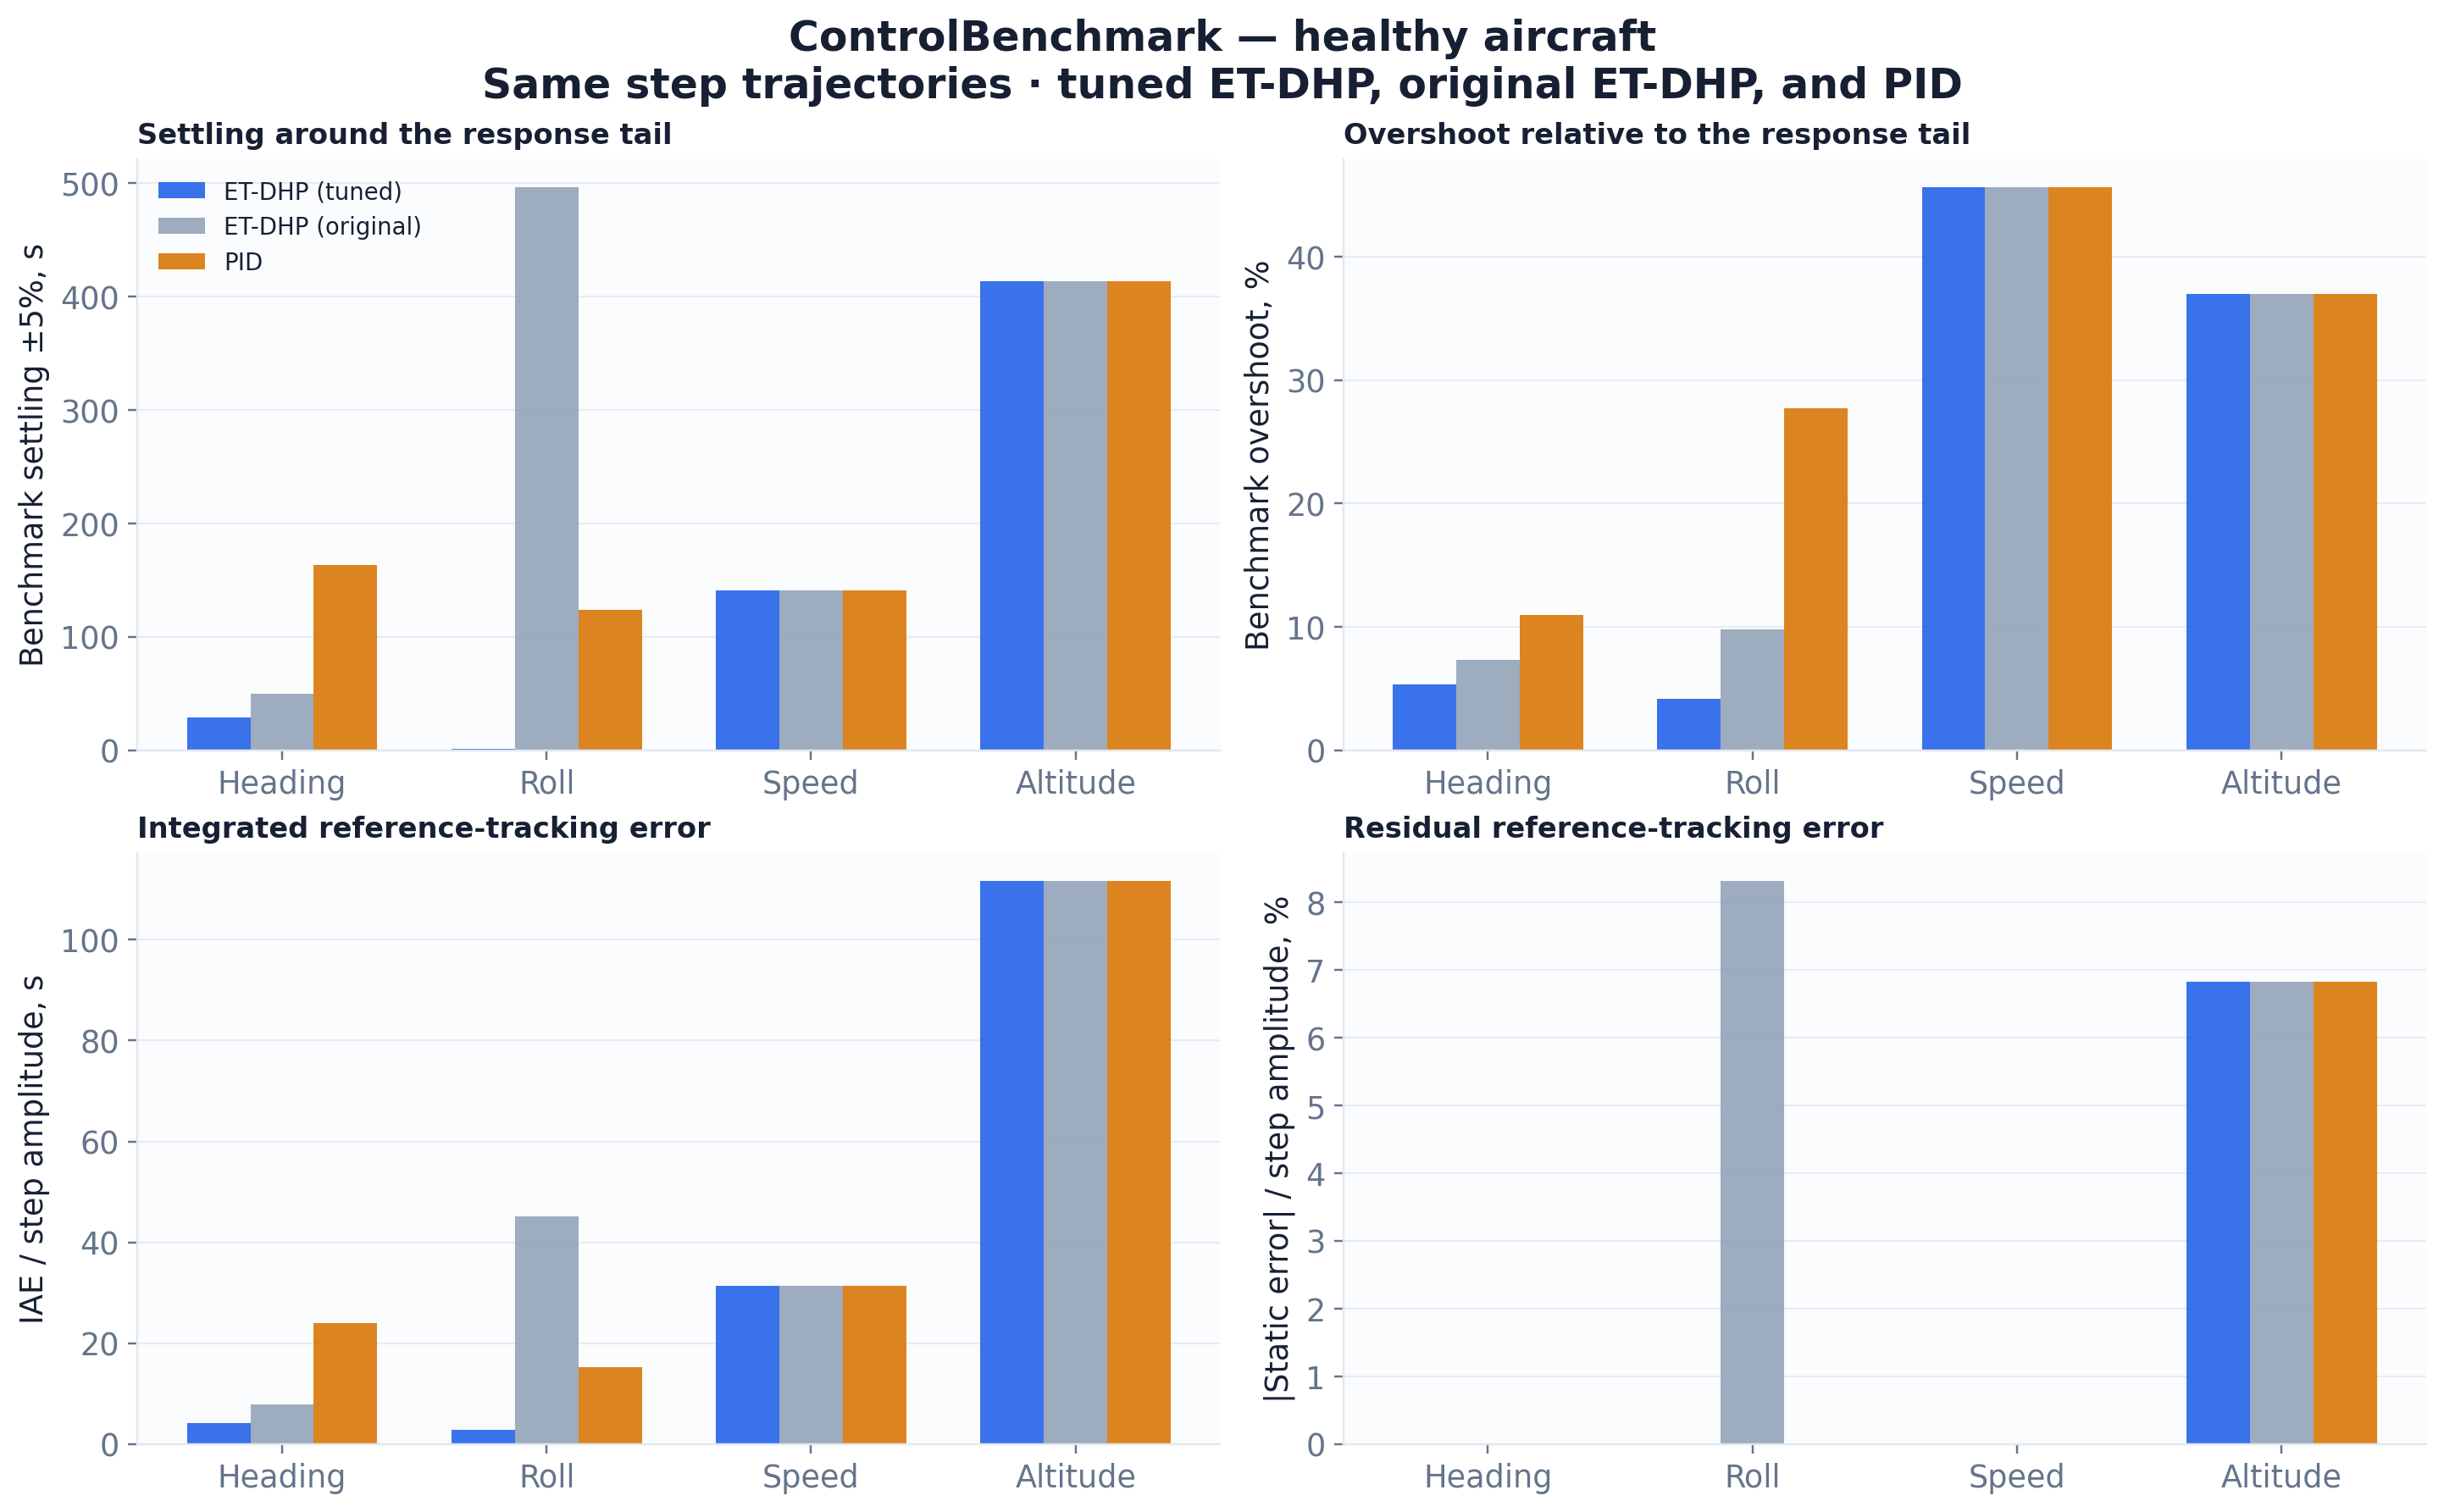

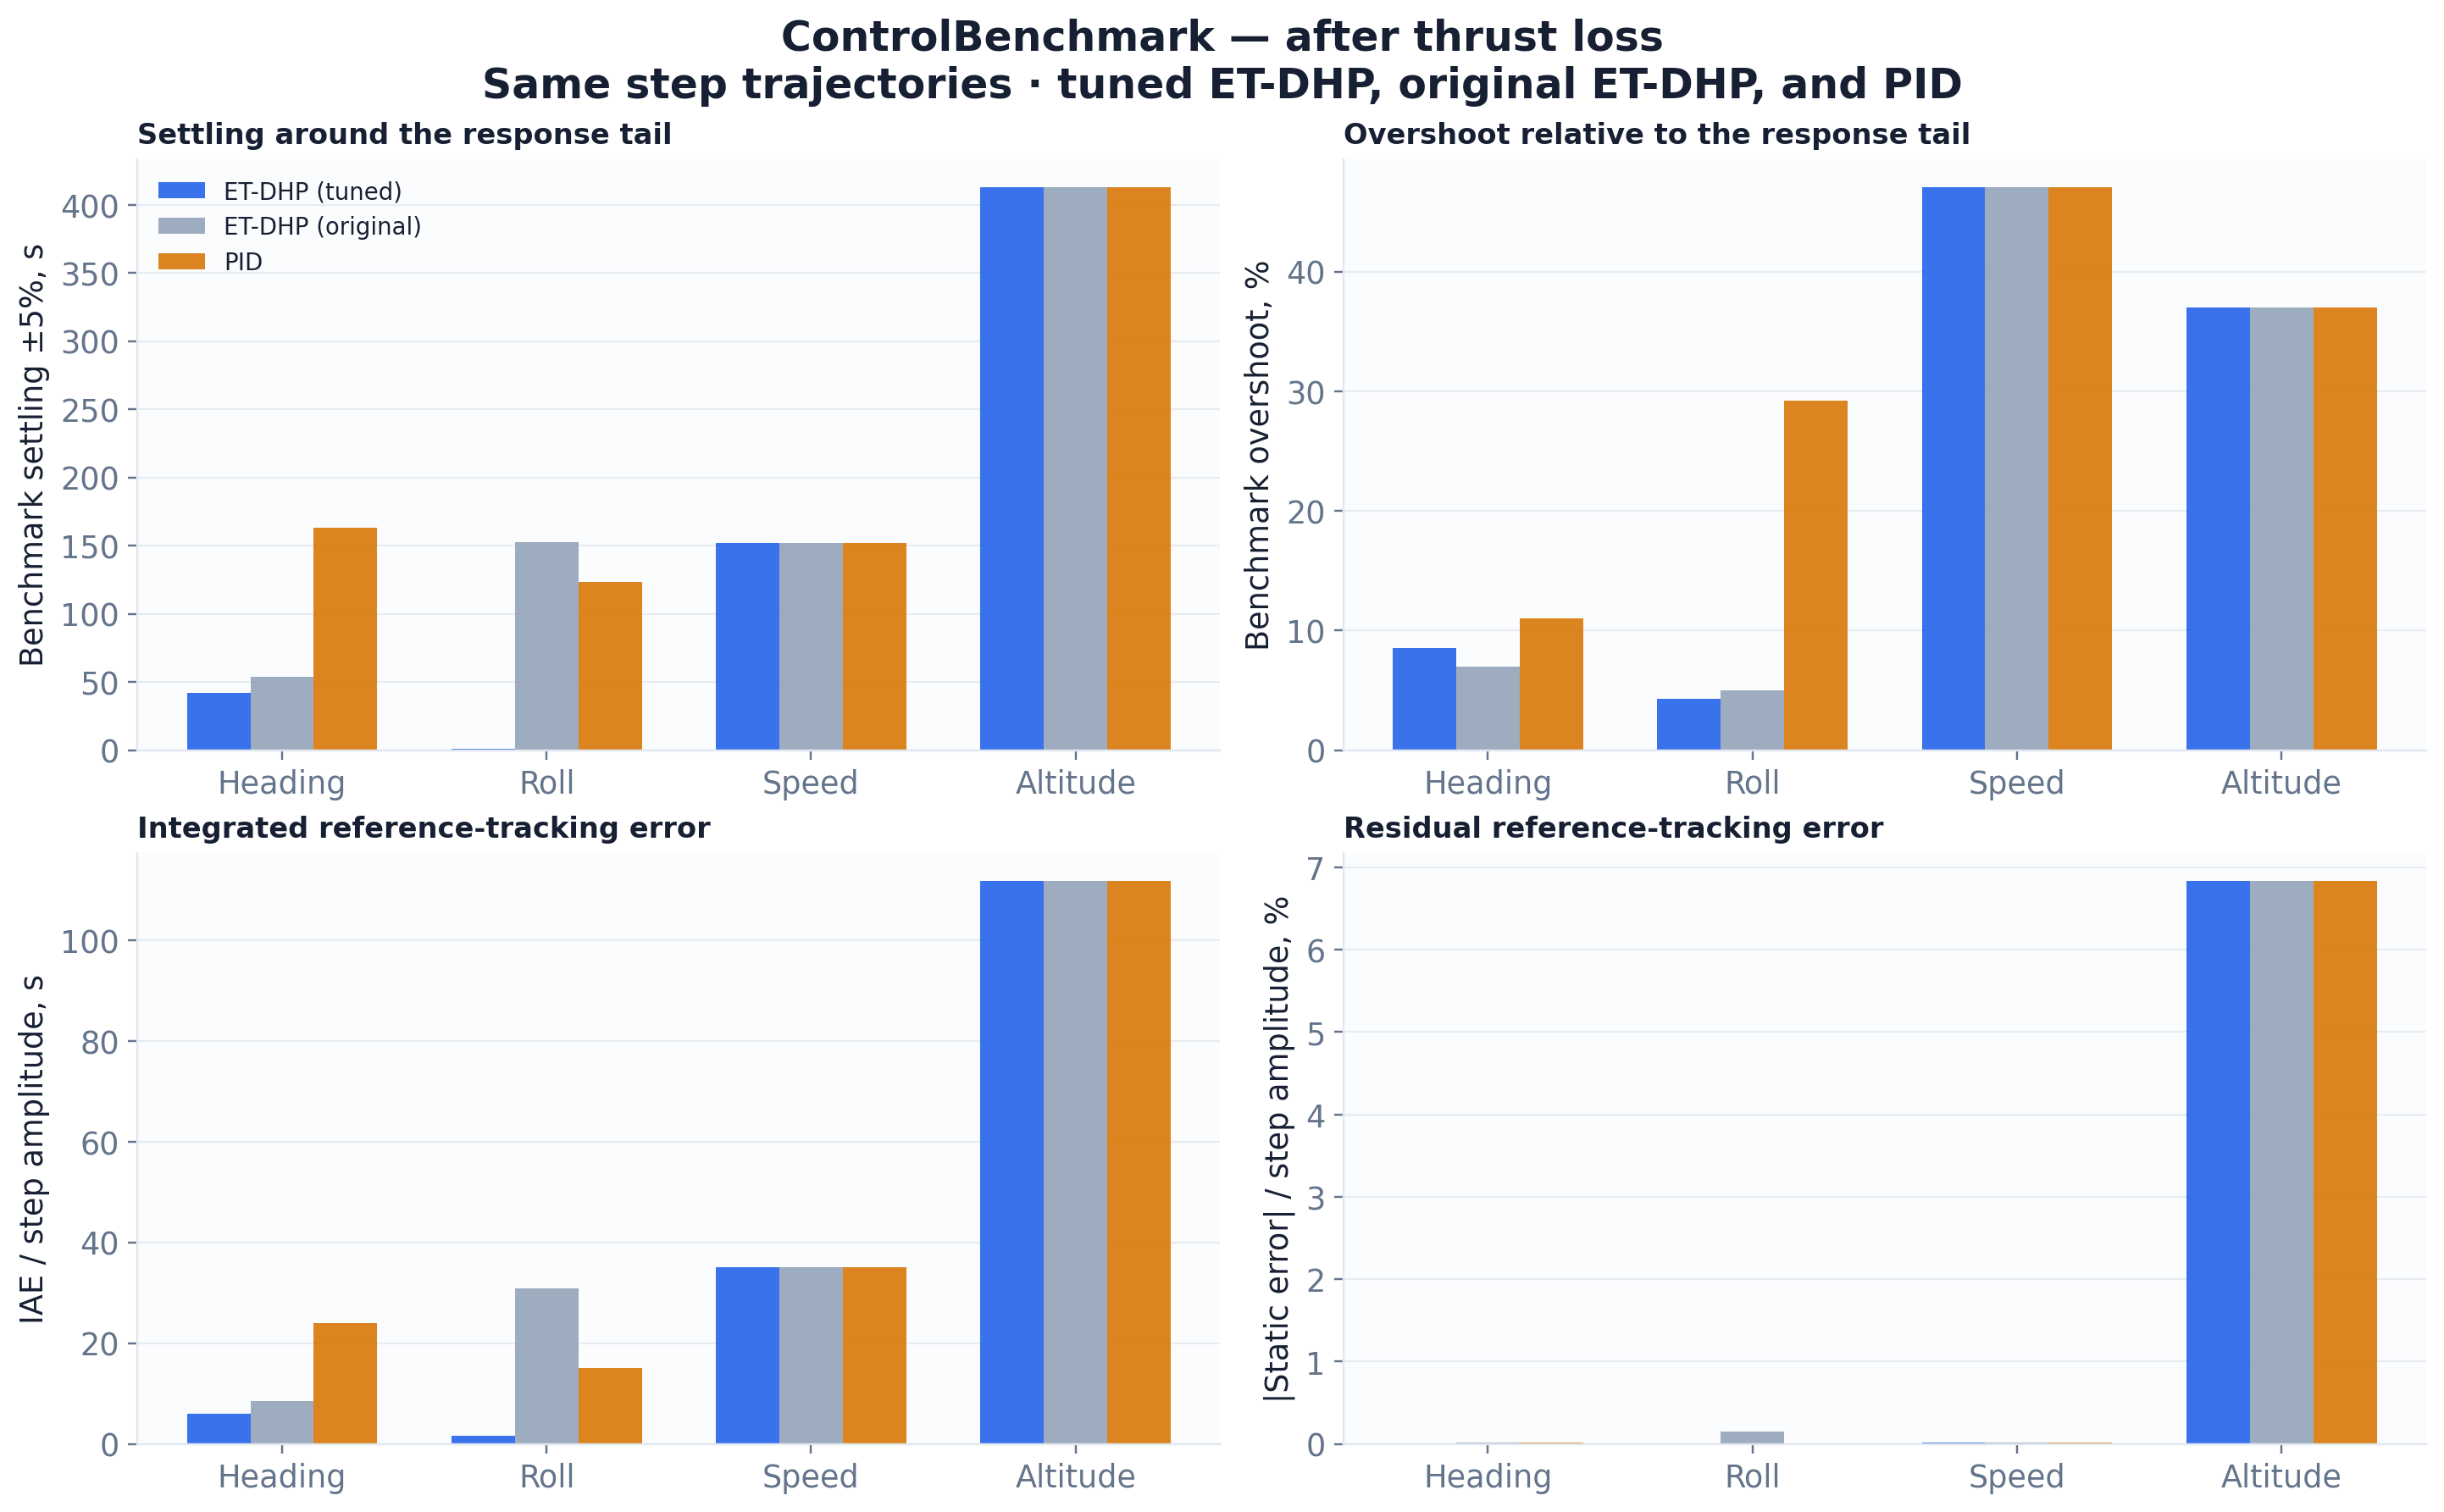

In [23]:
for condition, condition_label in step_conditions:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout='constrained')
    panels = [
        ('settling_time', 'Settling around the response tail', 'Benchmark settling ±5%, s', 'raw'),
        ('overshoot', 'Overshoot relative to the response tail', 'Benchmark overshoot, %', 'raw'),
        ('iae', 'Integrated reference-tracking error', 'IAE / step amplitude, s', 'amplitude'),
        ('static_error', 'Residual reference-tracking error', '|Static error| / step amplitude, %', 'percent'),
    ]
    positions = np.arange(len(step_labels))
    width = 0.24
    for ax, (metric, title, ylabel, conversion) in zip(axes.flat, panels):
        for index, (controller, _, _, color) in enumerate(benchmark_variants):
            selected = benchmark_frame[
                (benchmark_frame['condition'] == condition)
                & (benchmark_frame['controller'] == controller)
            ].set_index('channel').loc[step_labels]
            values = selected[metric].to_numpy(dtype=float)
            if conversion == 'amplitude':
                values = values / selected['amplitude'].to_numpy()
            elif conversion == 'percent':
                values = 100 * np.abs(values) / selected['amplitude'].to_numpy()
            x = positions + (index - 1) * width
            ax.bar(x, values, width=width, color=color, alpha=.9, label=controller)
            for xpos, val in zip(x, values):
                if not np.isfinite(val):
                    ax.text(xpos, .03, 'N/A', transform=ax.get_xaxis_transform(),
                            ha='center', va='bottom', fontsize=8, color=color)
        ax.set_xticks(positions, step_labels)
        ax.set_ylabel(ylabel)
        ax.set_title(title, loc='left', fontsize=11)
        ax.set_axisbelow(True)
        ax.grid(axis='x', visible=False)
        ax.set_ylim(bottom=0)
    axes[0, 0].legend(fontsize=9)
    heading(fig, f'ControlBenchmark — {condition_label.lower()}',
            'Same step trajectories · tuned ET-DHP, original ET-DHP, and PID')
    show_export(fig, f'09_control_benchmark_{condition}')

### Additional project metrics and export

The following table exposes the remaining fields returned by the API. Damping degree and oscillation count retain their library definitions; a damping value of zero can mean fewer than two detected peaks. The oscillation detector uses its default threshold of 0.01 in the channel's units. These diagnostics are not a stability proof.

The composite performance index is the library's fixed weighted sum of ISE, ITAE, and overshoot. Its magnitude depends on units and step amplitude; it is shown for reproducibility and is **not used to rank different channels or tune these controllers**. A finite static-error estimate is not a guarantee of asymptotic convergence.

All 13 native metrics, the step protocol, metric conventions, and command-based settling times are exported to `control_benchmark/step_metrics.json` and `control_benchmark/step_metrics.csv` under the notebook's figure directory. Both new figures are included in the combined PDF exported by the final cell.

In [24]:
show_benchmark_table({
    'aircraft': 'Aircraft', 'channel': 'Channel', 'unit': 'Unit',
    'controller': 'Controller', 'peak_time': 'First peak time, s',
    'maximum_deviation': 'Maximum deviation from reference, unit',
    'damping_degree': 'Damping degree', 'oscillation_count': 'Oscillation count',
    'steady_state_value': 'Final reference increment, unit',
    'performance_index': 'Composite performance index',
})
benchmark_report = {
    'api': 'tensoraerospace.benchmark.ControlBenchmark.benchmarking_one_step',
    'protocol': asdict(step_protocol),
    'evaluations': len(benchmark_records),
    'input_convention': 'reference and response minus the initial commanded reference; no measured bias subtraction',
    'step_detection': 'half of the positive commanded step amplitude',
    'settling_convention': '5% of mean response increment over last 10%; no minimum confirmation duration',
    'static_error_convention': 'reference minus output; native benchmark tail selection',
    'integral_convention': 'rectangle sum; includes command-time sample; ITAE time starts at step detection',
    'results': benchmark_records,
}
(benchmark_dir / 'step_metrics.json').write_text(
    json.dumps(benchmark_report, indent=2, allow_nan=False) + '\n'
)
print('Benchmark report saved:', (benchmark_dir / 'step_metrics.json').relative_to(repo))

Aircraft,Channel,Unit,Controller,"First peak time, s","Maximum deviation from reference, unit",Damping degree,Oscillation count,"Final reference increment, unit",Composite performance index
Healthy aircraft,Heading,°,ET-DHP (tuned),0.9500,1.0000,-0.0004,168,1.0000,36.0750
Healthy aircraft,Heading,°,ET-DHP (original),1.5000,0.9999,-0.0014,106,1.0000,161.5119
Healthy aircraft,Heading,°,PID,88.8000,1.0000,0.0000,0,1.0000,650.5383
Healthy aircraft,Roll,°,ET-DHP (tuned),1.7500,0.5000,0.0001,179,0.5000,28.5875
Healthy aircraft,Roll,°,ET-DHP (original),3.4500,0.5017,-0.0017,65,0.5000,1379.6698
Healthy aircraft,Roll,°,PID,1.4500,0.5000,0.0694,2,0.5000,216.2020
Healthy aircraft,Speed,m/s,ET-DHP (tuned),38.2000,1.0000,0.0826,2,1.0000,640.0176
Healthy aircraft,Speed,m/s,ET-DHP (original),38.2000,1.0000,0.0826,2,1.0000,640.0184
Healthy aircraft,Speed,m/s,PID,38.2000,1.0000,0.0826,2,1.0000,640.0177
Healthy aircraft,Altitude,m,ET-DHP (tuned),139.1000,10.0000,0.2681,1,10.0000,68701.7167


Benchmark report saved: outputs/b747-etdhp-vs-pid/notebook/english_graphics/control_benchmark/step_metrics.json


In [25]:
pdf_path = figure_dir / 'etdhp_vs_pid_b747_english.pdf'
with PdfPages(pdf_path, metadata={'Title': 'ET-DHP and PID: B747, total error', 'Author': 'TensorAeroSpace'}) as pdf:
    for _, figure in exports:
        pdf.savefig(figure, facecolor='white', bbox_inches='tight')

metric_report = {
    'definition': 'sum_i abs(error_i)/scale_i; integral=dt*sum over a<t<=b',
    'channels': [{'name': name, 'column': field, 'unit': unit, 'conversion_factor': factor,
                  'scale': ERROR_SCALES[name]} for name, field, factor, unit in CHANNELS],
    'experiment': report['experiment'], 'windows': WINDOWS,
    'results': total_error_metrics,
}
(figure_dir / 'total_error_metrics.json').write_text(json.dumps(metric_report, indent=2, ensure_ascii=False, allow_nan=False)+'\n')
series = [traces['fault_etdhp'][:, 0]]
headers = ['time_s']
for name in traces:
    np.testing.assert_array_equal(traces[name][:, 0], series[0])
    series.extend([errors[name]['total'], errors[name]['cumulative']])
    headers.extend([name+'_total_error', name+'_cumulative_error'])
np.savetxt(figure_dir / 'total_error_series.csv', np.column_stack(series), delimiter=',', header=','.join(headers), comments='')
print(f'Saved: {len(exports)} figures, PDF, JSON and CSV tables.')
print('Directory:', figure_dir.relative_to(repo))

Saved: 19 figures, PDF, JSON and CSV tables.
Directory: outputs/b747-etdhp-vs-pid/notebook/english_graphics
